In [20]:
library(Seurat)
library(SeuratDisk)
library(SCopeLoomR)
library(data.table)
library(tidyverse)
library(SCpubr)
library(RColorBrewer)
library(dittoSeq)
library(viridis)
library(scales)
library(ggrepel)
library(patchwork)

In [21]:
options(repr.plot.width = 12, repr.plot.height = 8, repr.plot.res = 200)

# Read Required Files

## Read Seurat File

In [3]:
# data with AUC matrix and umap
data <- readRDS("./TERVA_fibro.rds")

In [22]:
# data with AUC matrix and umap
# Spleen and Aorta removed
# AUC z-scores added
data <- readRDS("./TERVA_fibro_new.rds")

In [ ]:
# data without AUC data
data <- LoadH5Seurat("./TERVA2.h5Seurat")

In [6]:
# relevel "celltype" column
data$Cell_Type <- droplevels(data$Cell_Type)

## Read RSS Files

RSS for fibroblast subclusters

In [7]:
rss_subcluster <- read.csv("./rss_subcluster.csv")
row.names(rss_subcluster) <- rss_subcluster$X
rss <- rss_subcluster[-1]
rss_subcluster <- as.data.frame(t(rss))
row.names(rss_subcluster) <- gsub(
    pattern = "...",
    replacement = "",
    x = row.names(rss_subcluster),
    fixed = TRUE
)

In [20]:
head(rss_subcluster)

,Cd248+ Pi16+ Fibroblasts,Mfap4+ Fibroblasts,Ccl11+ Fibroblasts,Mgp+ Aebp1+ Activated fibroblasts,Il1b+ Fibroblasts
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ahr,0.2410279,0.2268790,0.2183867,0.4919064,0.2729595
Alx4,0.3592390,0.3106883,0.3897916,0.3597541,0.2041792
Ar,0.3763460,0.3507320,0.4832307,0.2830626,0.1816961
Arid3a,0.3731572,0.3379227,0.4126610,0.3214382,0.1998515
Arnt,0.3927584,0.3351839,0.4322530,0.3274322,0.1964775
Arnt2,0.3532750,0.2526185,0.3116851,0.2192960,0.1819961


RSS for fibroblast subcluster groups

In [8]:
rss_subcluster_groups <- read.csv("./rss_subcluster_groups.csv")
row.names(rss_subcluster_groups) <- rss_subcluster_groups$X
rss <- rss_subcluster_groups[-1]
rss_subcluster_groups <- as.data.frame(t(rss))
row.names(rss_subcluster_groups) <- gsub(
    pattern = "...",
    replacement = "",
    x = row.names(rss_subcluster_groups),
    fixed = TRUE
)

## Read AUC Matrix

In [9]:
auc_mtx <- read.csv("./auc_matrix.csv")
row.names(auc_mtx) <- auc_mtx$X
rss <- auc_mtx[-1]
auc_mtx <- as.data.frame(t(rss))
row.names(auc_mtx) <- gsub(
    pattern = "...",
    replacement = "",
    x = row.names(auc_mtx),
    fixed = TRUE
)

In [9]:
head(auc_mtx)

,OBAO_AACACGTAGTATGACA-1,OBAO_AACCATGAGCGCTTAT-1,OBAO_AACTCAGGTAGGCATG-1,OBAO_AACTGGTGTTACTGAC-1,OBAO_AACTTTCTCAACGAAA-1,OBAO_AAGGCAGCAGGTTTCA-1,OBAO_AAGGTTCCATCCGCGA-1,OBAO_ACACCAAGTTACAGAA-1,OBAO_ACCAGTAAGTGTTGAA-1,OBAO_ACGAGCCAGTGACATA-1,⋯,NOBPVAT_TTTCCTCTCAACACGT-1,NOBPVAT_TTTGCGCCAGGGTACA-1,NOBPVAT_TTTGCGCTCACAGGCC-1,NOBPVAT_TTTGCGCTCCCTAACC-1,NOBPVAT_TTTGGTTAGTGCCAGA-1,NOBPVAT_TTTGGTTCAAATTGCC-1,NOBPVAT_TTTGTCAAGATCGATA-1,NOBPVAT_TTTGTCAGTCATGCAT-1,NOBPVAT_TTTGTCATCGTTGCCT-1,OBSpleen_ACTGAGTGTAGCGATG-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ahr,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.119047619,0.000000000,⋯,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.06372809,0.085678881
Alx4,0.007912187,0.001046586,0.009628588,0.021316856,0.005542717,0.01003885,0.021727117,0.001188921,0.027454034,0.012483673,⋯,0.002804849,0.02066379,0.002737868,0.009444389,0.005057102,0.007326099,0.004764058,0.018671087,0.01264275,0.008565257
Ar,0.168983891,0.156728625,0.117162330,0.124473358,0.186629492,0.07836431,0.075315985,0.077571252,0.003283767,0.103073110,⋯,0.149318463,0.14755886,0.089479554,0.173283767,0.139120198,0.101102850,0.110198265,0.193382900,0.11087980,0.048079306
Arid3a,0.021288445,0.019025939,0.017905128,0.001816967,0.009669604,0.01726466,0.007720368,0.009335450,0.017605781,0.004316166,⋯,0.016227392,0.02344653,0.021727023,0.005938209,0.007316598,0.017995628,0.021448561,0.019805633,0.01021261,0.033951520
Arnt,0.050588600,0.034992427,0.048736748,0.041143467,0.039973152,0.03824522,0.014560099,0.034995869,0.098547432,0.044726697,⋯,0.051841526,0.04288517,0.037832163,0.036204048,0.062353711,0.051373399,0.043608013,0.035481206,0.03358461,0.043804213
Arnt2,0.014560099,0.000000000,0.029615861,0.040768278,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.000000000,⋯,0.016294919,0.00000000,0.012391574,0.021499380,0.000000000,0.000000000,0.000000000,0.006443618,0.02038414,0.000000000


# Function for Creating RSS Plots for One Celltype

In [10]:
plotRSS_oneSet <- function(rss, setName, n=10){
    
    rssThisType <- as.vector(rss[setName])[[1]]
    names(rssThisType) <- row.names(rss)
    rssThisType <- sort(rssThisType, decreasing = TRUE)
    thisRss <- data.frame(regulon=names(rssThisType), rank=seq_along(rssThisType), rss=rssThisType)
    thisRss$regulon[(n+1):(nrow(thisRss) - n)] <- NA
    
    ggplot(thisRss, aes(x=rank, y=rss, color = rss)) + 
        geom_point(size = 2, alpha = 0.5) + 
        ggtitle(setName) + 
        geom_label_repel(aes(label = regulon),
                         box.padding   = 0.35, 
                         point.padding = 0.5,
                         segment.color = 'grey50',
                         na.rm=TRUE,
                         max.time = 10,
                         max.iter = 100000,
                         max.overlaps = 20) +
        scale_color_gradient(low="blue", high="gold") +
        theme_light() +
        xlab("Rank") +
        ylab("Regulon Specificity Score (RSS)") +
        labs(color = "RSS")
}

# Funtion for Creating RSS Plot for Two Conditions

In [12]:
#' @param rss RSS data.frame
#' @param set.1 Name of the first cell cluster (e.g. Resident-like macrophages - obese)
#' @param set.2 Name of the second cell cluster (e.g. Resident-like macrophages - non-obese)
#' @param n Number of labels to annotate. Default 10
#' @title Title for the plot. Default NULL
#'
plotRSS_twoSets <- function(rss, set.1, set.2, n = 10, title = NULL){
    
    # first RSS set
    # create a vector
    first_rss <- as.vector(rss[set.1])[[1]]
    # define names
    names(first_rss) <- row.names(rss)
    # scale data between 0 and 1
    first_rss <- rescale(first_rss)
    # sort vector
    first_rss <- sort(first_rss, decreasing = TRUE)
    
    # second RSS set
    # create a vector
    second_rss <- as.vector(rss[set.2])[[1]]
    # define names
    names(second_rss) <- row.names(rss)
    # scale data between 0 and 1
    second_rss <- rescale(second_rss)
    # convert to negative
    second_rss <- -second_rss
    # sort vector
    second_rss <- sort(second_rss, decreasing = TRUE)
    
    # combine two vectors
    combined_sets <- c(first_rss, second_rss)
    
    # create a data.frame of RSSs and regulons
    thisRss <- data.frame(regulon=names(combined_sets), rank=seq_along(combined_sets), rss=combined_sets)
    # select 10 regulons from head and tail of the dataframe
    thisRss$regulon[(n+1):(nrow(thisRss) - n)] <- NA
    
    # create a scatter plot
    ggplot(thisRss, aes(x=rank, y=rss, color = rss)) + 
        geom_point(size = 2, alpha = 0.5) + 
        ggtitle(title) + 
        geom_label_repel(aes(label = regulon),
                         box.padding   = 0.35, 
                         point.padding = 0.5,
                         segment.color = 'grey50',
                         na.rm=TRUE,
                         max.time = 10,
                         max.iter = 100000,
                         max.overlaps = 20) +
        geom_hline(yintercept = 0, linetype = "dashed") +
        scale_color_gradient(low="blue", high="gold") +
        theme_light() +
        xlab("Rank") +
        ylab("Regulon Specificity Score (RSS)") +
        labs(color = "RSS (scaled)") +
        theme(
            axis.text.x=element_blank(),
            axis.ticks.x=element_blank()
        )
}

# Add AUC Matrix As a New Assay

In [104]:
data[["SCENIC_AUC"]] <- CreateAssay5Object(data = auc_mtx)

Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Warning message:
“No layers found matching search pattern provided”


# Run UMAP on AUC Matrix

In [105]:
data <- RunUMAP(
    data,
    assay = "SCENIC_AUC",
    dims = NULL,
    features = row.names(data[["SCENIC_AUC"]]),
    reduction.name = "AUC_umap"
)

15:47:23 UMAP embedding parameters a = 0.9922 b = 1.112

15:47:23 Read 8581 rows and found 350 numeric columns

15:47:23 Using Annoy for neighbor search, n_neighbors = 30

15:47:23 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:47:27 Writing NN index file to temp file /tmp/RtmpUIgBFq/file3e0220553472ab

15:47:27 Searching Annoy index using 1 thread, search_k = 3000

15:47:35 Annoy recall = 100%

15:47:36 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:47:37 Initializing from normalized Laplacian + noise (using RSpectra)

15:47:37 Commencing optimization for 500 epochs, with 453386 positive edges

15:47:48 Optimization finished



# Dimensionality Reduction Plots - RNA vs AUC Scores

In [23]:
Idents(data) <- "Cell_Type"
rna_umap <- DimPlot(
    object = data,
    reduction = "umap",
    label.box = TRUE,
    label.size = 6,
    pt.size = 2
) +
    NoLegend() + 
    NoAxes()

auc_umap <- DimPlot(
    object = data,
    reduction = "AUC_umap",
    label.box = TRUE,
    label.size = 6,
    pt.size = 2
) +
    NoLegend() + 
    NoAxes()

In [72]:
rna_vs_auc_umap <- LabelClusters(
    plot = rna_umap,
    id = "ident",
    repel = TRUE,
    max.time = 20,
    max.iter = 1000000,
    box = TRUE
) + 
    LabelClusters(
    plot = auc_umap,
    id = "ident",
    repel = TRUE,
    max.time = 20,
    max.iter = 1000000,
    box = TRUE
)

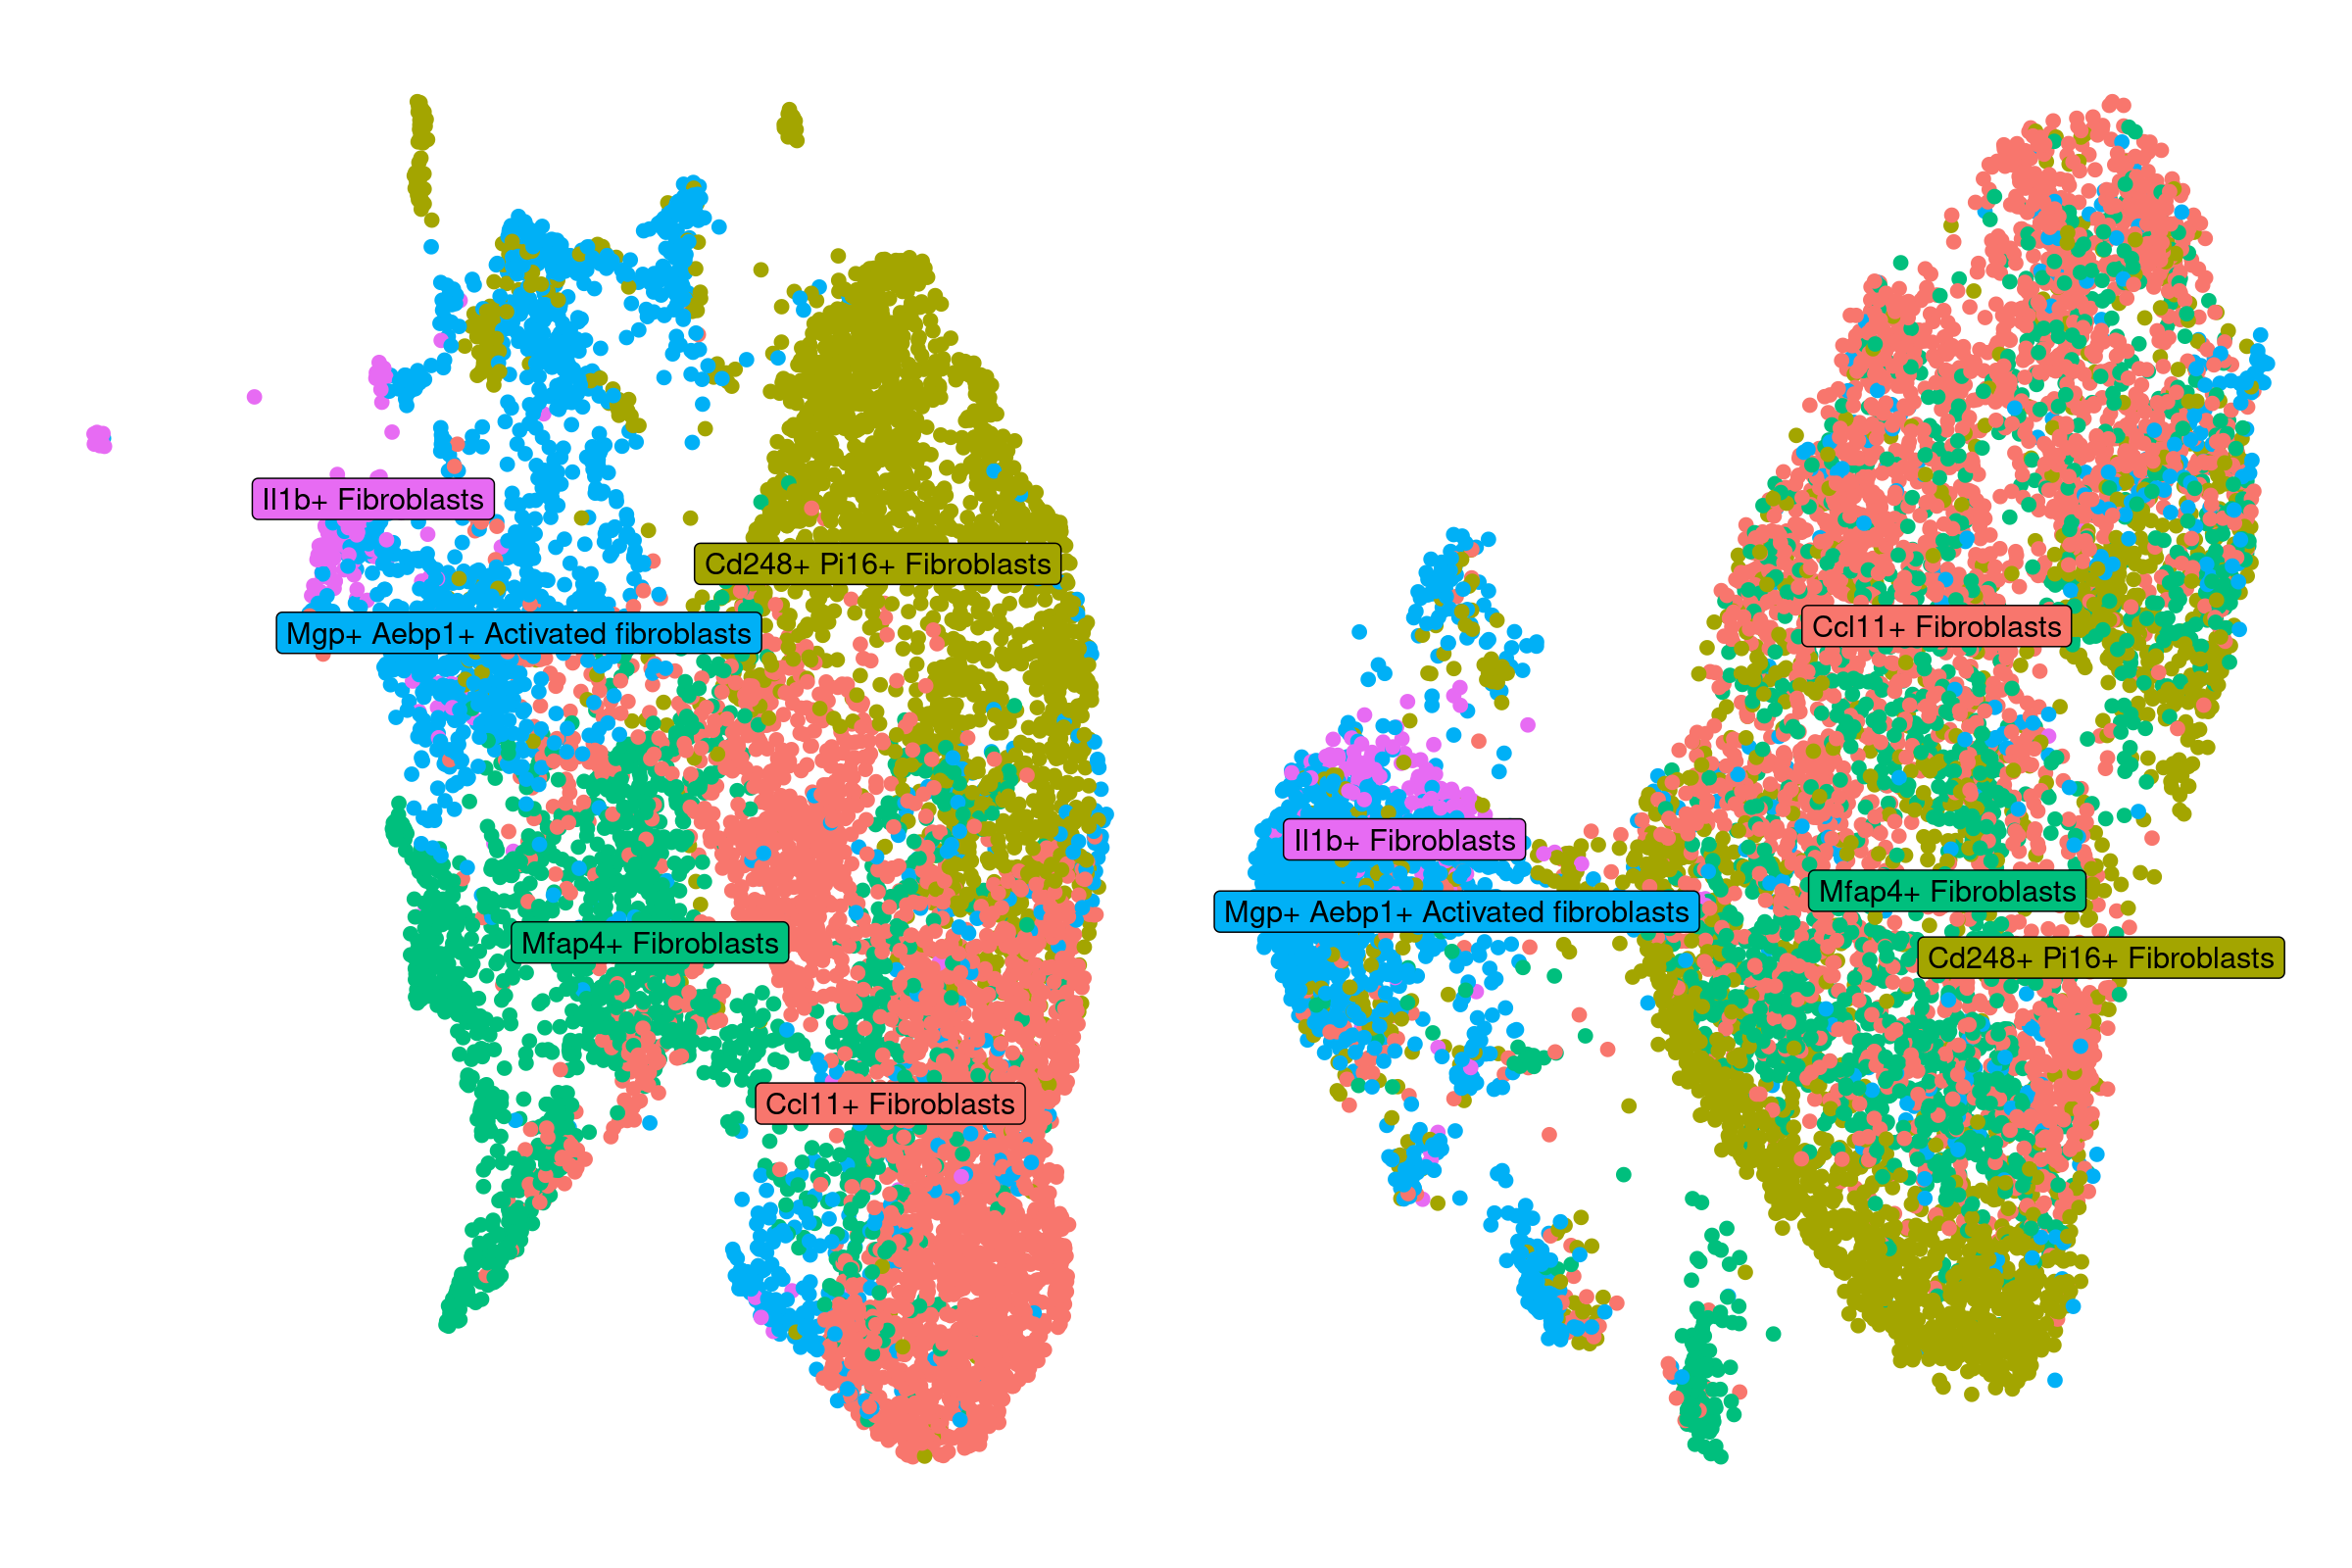

In [73]:
rna_vs_auc_umap

In [74]:
ggsave(
    plot = rna_vs_auc_umap,
    filename = "rna_vs_auc_umap.png",
    width = 12,
    height = 8,
    dpi = 500
)

# Select Top 10 Regulons From Each Cell Type and Disease State

In [24]:
top_reg <- c()

for (i in seq_along(colnames(rss_subcluster_groups))){
    # get cell type name
    cell_type <- colnames(rss_subcluster_groups)[i]
    
    # subset rss data
    rss_cell_type <- as.vector(rss_subcluster_groups[cell_type])[[1]]
    
    # add regulon names to the rss data
    names(rss_cell_type) <- row.names(rss_subcluster_groups)
    
    # sort the rss data
    rss_cell_type <- sort(rss_cell_type, decreasing = TRUE)
    
    # select the top 5 regulons
    top5 <- names(rss_cell_type)[1:10]
    
    # append the regulons to the vector
    top_reg <- append(top_reg, top5)
    
    rm(rss_cell_type)
    rm(top5)
    rm(cell_type)
}

# unique regulons
top_reg <- unique(top_reg)

In [16]:
top_reg

[1] "Klf3"    "Foxo1"   "Prrx1"   "Klf4"    "Nfe2l2"  "Rfxap"   "Klf2"   
 [8] "Nr3c1"   "Ebf1"    "Klf6"    "Nr1d1"   "Prrx2"   "Foxp2"   "Nr2f2"  
[15] "Esrrg"   "Nfic"    "Gata6"   "Dbp"     "Irf8"    "Erg"     "Sox9"   
[22] "Hoxc8"   "Cebpa"   "Ar"      "Pparg"   "Tcf21"   "Klf9"    "Arx"    
[29] "Cebpd"   "Mxd3"    "Nr3c2"   "Nfe2l1"  "Hoxd3"   "Ahr"     "Hoxa4"  
[36] "Nfkb1"   "Irf2"    "Mlxipl"  "Rsl1"    "Mxd1"    "Ikzf3"   "Mafb"   
[43] "Etv6"    "Irf5"    "Zfp874a" "Hoxb5"   "Creb3l1" "Ybx1"    "Hes1"   
[50] "Wt1"     "Maff"    "Stat4"   "Foxm1"   "Relb"    "Zfp579"  "Spic"   
[57] "Tbx20"   "Zfp296"  "Cebpe"

# Generate Z-scores for each regulon to enable comparison between regulons

In [17]:
regulons_auc_z <- apply(
    X = auc_mtx, # auc matrix
    MARGIN = 1, # over rows
    FUN = function(x) {
        (x - mean(x)) / sd(x)
    }
)

In [18]:
regulons_auc_z <- as.data.frame(t(regulons_auc_z))

In [93]:
head(regulons_auc_z)

,OBAO_AACACGTAGTATGACA-1,OBAO_AACCATGAGCGCTTAT-1,OBAO_AACTCAGGTAGGCATG-1,OBAO_AACTGGTGTTACTGAC-1,OBAO_AACTTTCTCAACGAAA-1,OBAO_AAGGCAGCAGGTTTCA-1,OBAO_AAGGTTCCATCCGCGA-1,OBAO_ACACCAAGTTACAGAA-1,OBAO_ACCAGTAAGTGTTGAA-1,OBAO_ACGAGCCAGTGACATA-1,⋯,NOBPVAT_TTTCCTCTCAACACGT-1,NOBPVAT_TTTGCGCCAGGGTACA-1,NOBPVAT_TTTGCGCTCACAGGCC-1,NOBPVAT_TTTGCGCTCCCTAACC-1,NOBPVAT_TTTGGTTAGTGCCAGA-1,NOBPVAT_TTTGGTTCAAATTGCC-1,NOBPVAT_TTTGTCAAGATCGATA-1,NOBPVAT_TTTGTCAGTCATGCAT-1,NOBPVAT_TTTGTCATCGTTGCCT-1,OBSpleen_ACTGAGTGTAGCGATG-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ahr,-0.53758599,-0.5375860,-0.53758599,-0.53758599,-0.5375860,-0.5375860,-0.5375860,-0.5375860,2.26986207,-0.53758599,⋯,-0.537585992,-0.5375860,-0.5375860,-0.5375860,-0.5375860,-0.53758599,-0.53758599,-0.5375860,0.96528583,1.4829417
Alx4,-0.40784499,-0.9799109,-0.26482851,0.70907883,-0.6052775,-0.2306441,0.7432633,-0.9680510,1.22044994,-0.02693281,⋯,-0.833406224,0.6546628,-0.8389874,-0.2801766,-0.6457407,-0.45667989,-0.67015815,0.4886242,-0.01367762,-0.3534290
Ar,1.03047345,0.7837213,-0.01292119,0.13428178,1.3857566,-0.7940950,-0.8554711,-0.8100627,-2.30579466,-0.29659879,⋯,0.634522400,0.5990939,-0.5702965,1.1170488,0.4291867,-0.33626875,-0.15313827,1.5217322,-0.13941596,-1.4038646
Arid3a,0.36534389,0.1748368,0.08046256,-1.27418923,-0.6129832,0.0265344,-0.7771123,-0.6411196,0.05525701,-1.06375219,⋯,-0.060805761,0.5470583,0.4022730,-0.9271733,-0.8111105,0.08808284,0.37882593,0.2404885,-0.56726147,1.4315973
Arnt,0.41057805,-0.3773459,0.31702186,-0.06659331,-0.1257180,-0.2130140,-1.4095942,-0.3771721,2.83347477,0.11443270,⋯,0.473876291,0.0213982,-0.2338815,-0.3161345,1.0049555,0.45022640,0.05791641,-0.3526527,-0.44846952,0.0678285
Arnt2,-0.06162959,-0.5403464,0.43338395,0.80006066,-0.5403464,-0.5403464,-0.5403464,-0.5403464,-0.54034640,-0.54034640,⋯,-0.004590996,-0.5403464,-0.1329278,0.1665248,-0.5403464,-0.54034640,-0.54034640,-0.3284888,0.12985713,-0.5403464


## Add Regulon Z-scores As a New Assay

In [ ]:
data[["SCENIC_AUC_Z"]] <- CreateAssay5Object(data = regulons_auc_z)

In [15]:
# drop the Aorta and Spleen since those tissues have very low number of fibroblasts
data <- subset(data, Tissue != "Aorta" & Tissue != "Spleen")

In [16]:
# relevel "Tissue" column
data$Tissue <- droplevels(data$Tissue)

In [21]:
# save a new RDS file
# Spleen and Aorta removed
# AUC z-scores added
saveRDS(data, file = "TERVA_fibro_new.rds", compress = TRUE)

# Create a Heatmap Using the AUC Scores

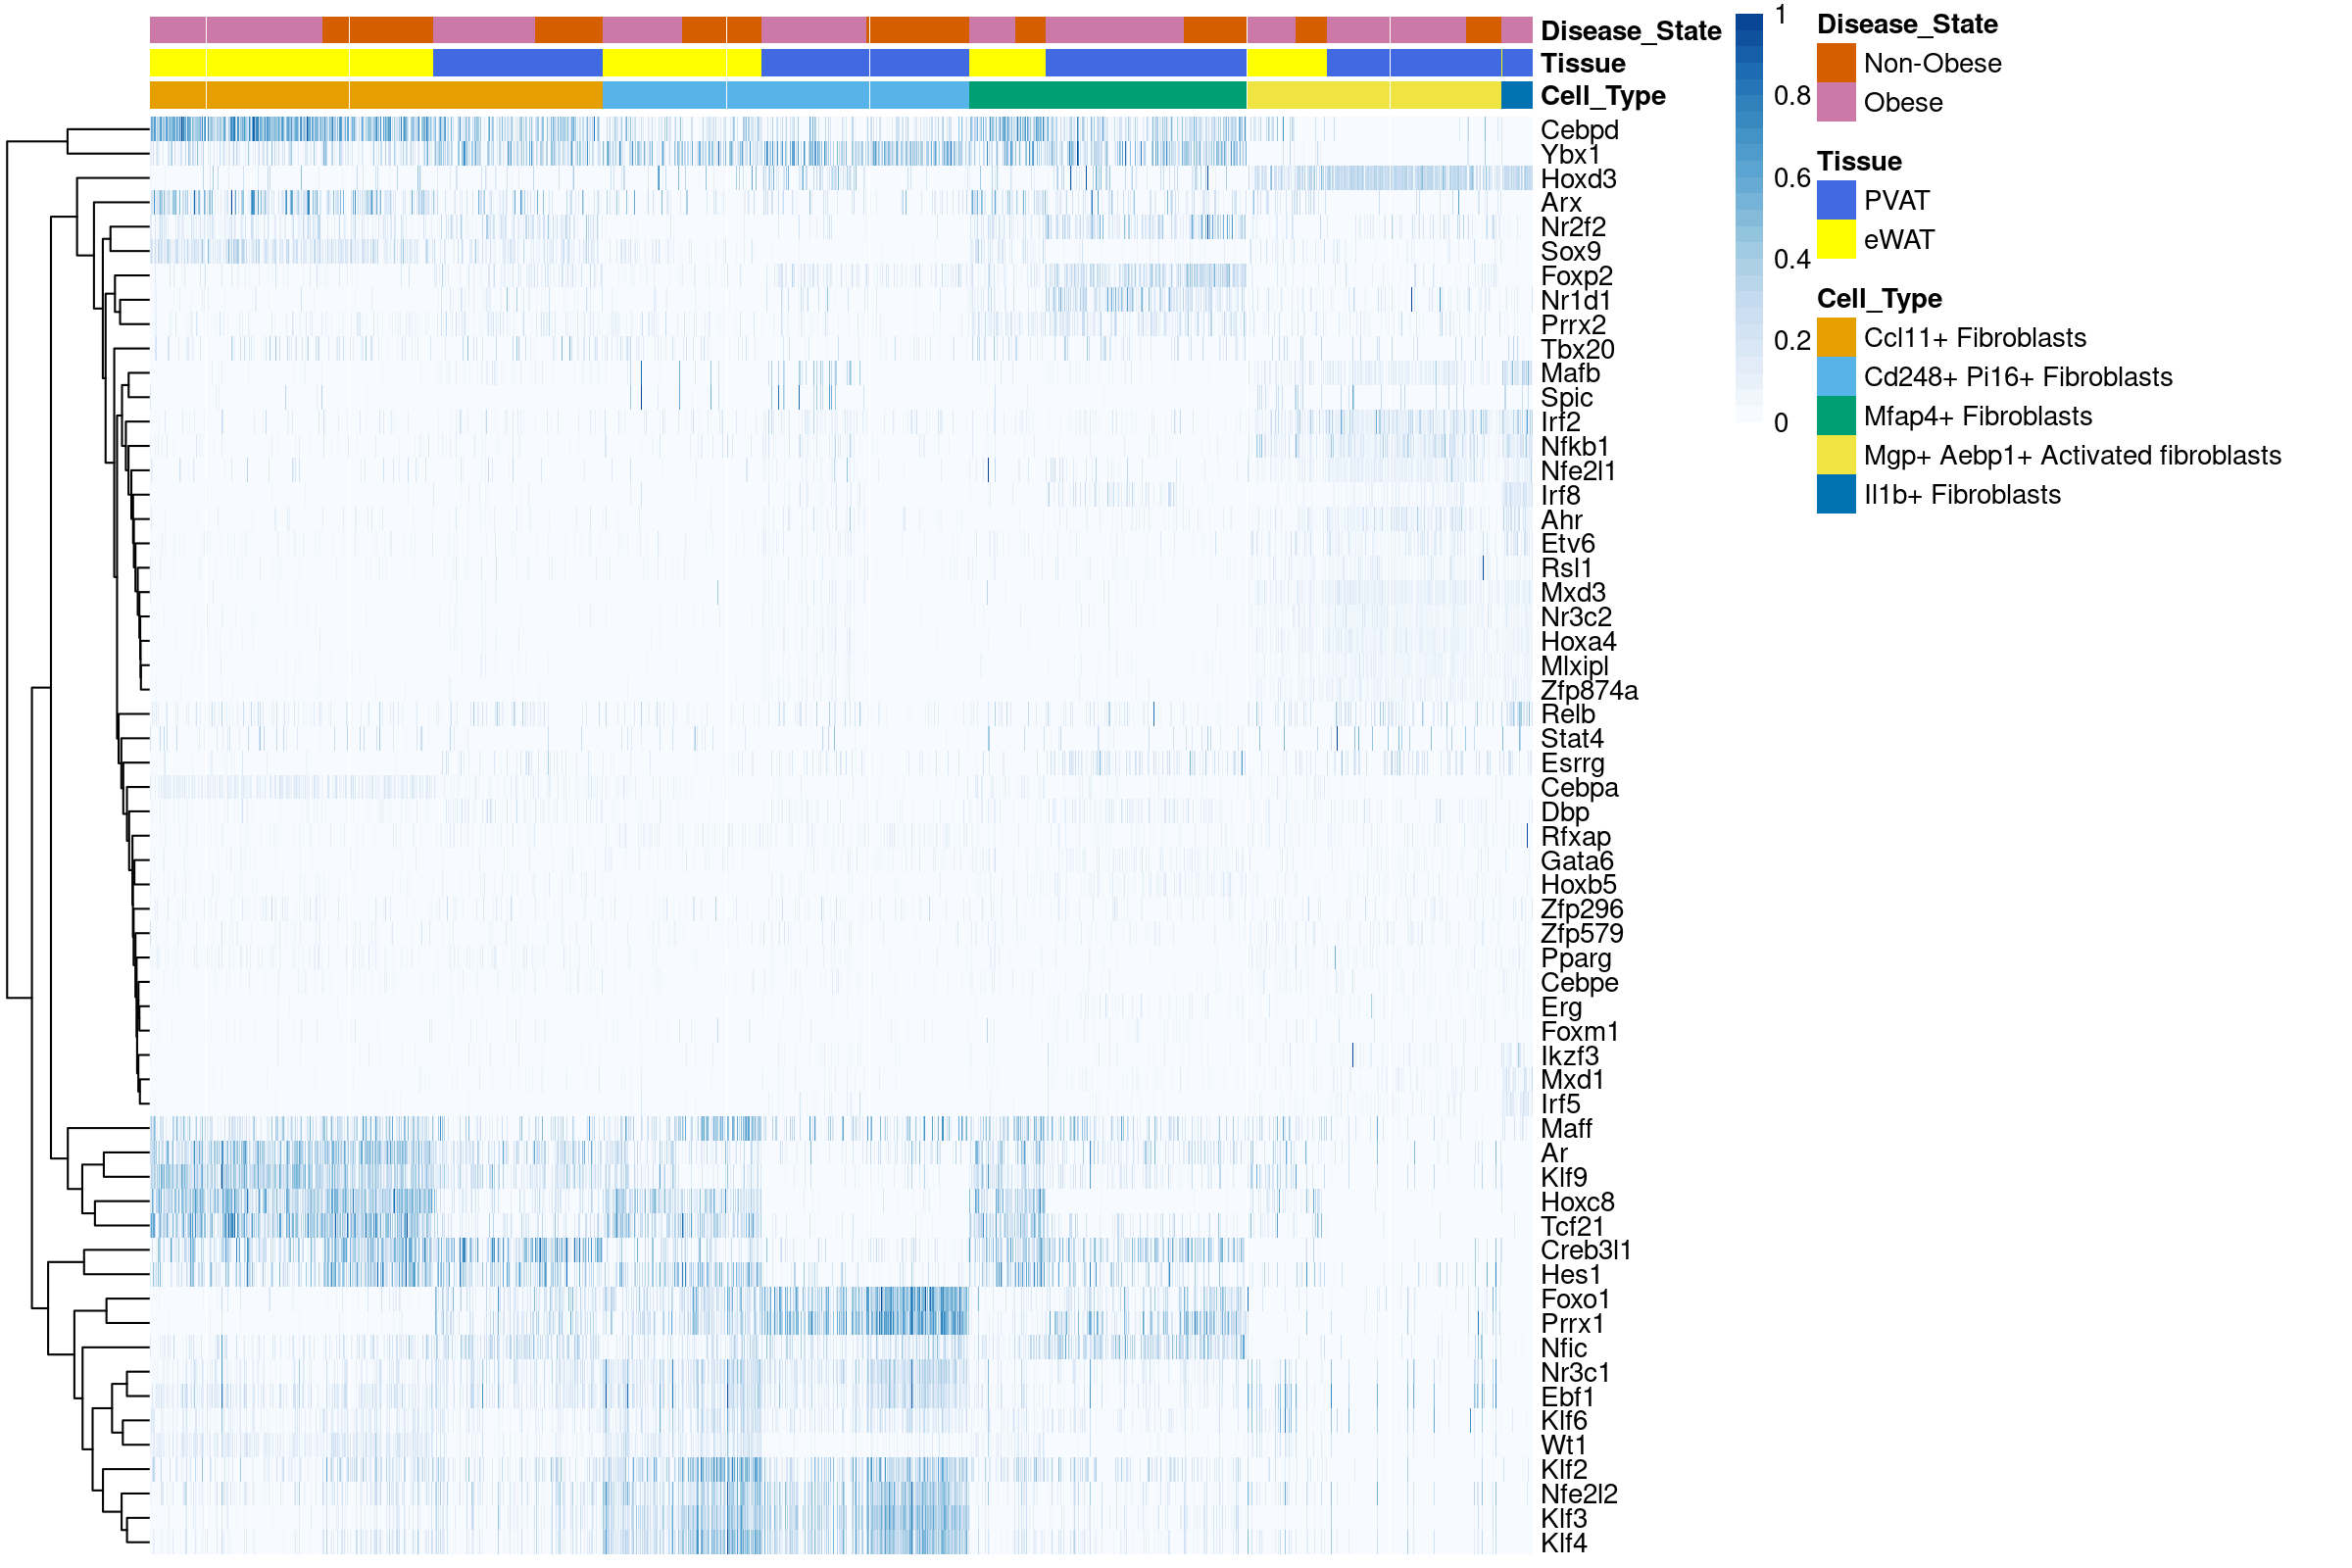

In [25]:
top_regulons_heatmap <- dittoHeatmap(
    object = data,
    genes = top_reg,
    annot.by = c("Cell_Type", "Tissue", "Disease_State"),
    assay = "SCENIC_AUC_Z",
    slot = "data",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'yellow')
    )
)

In [26]:
# save the plot
ggsave(
    plot = top_regulons_heatmap,
    filename = "top_regulons_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

# RNA Expression of the Top TFs

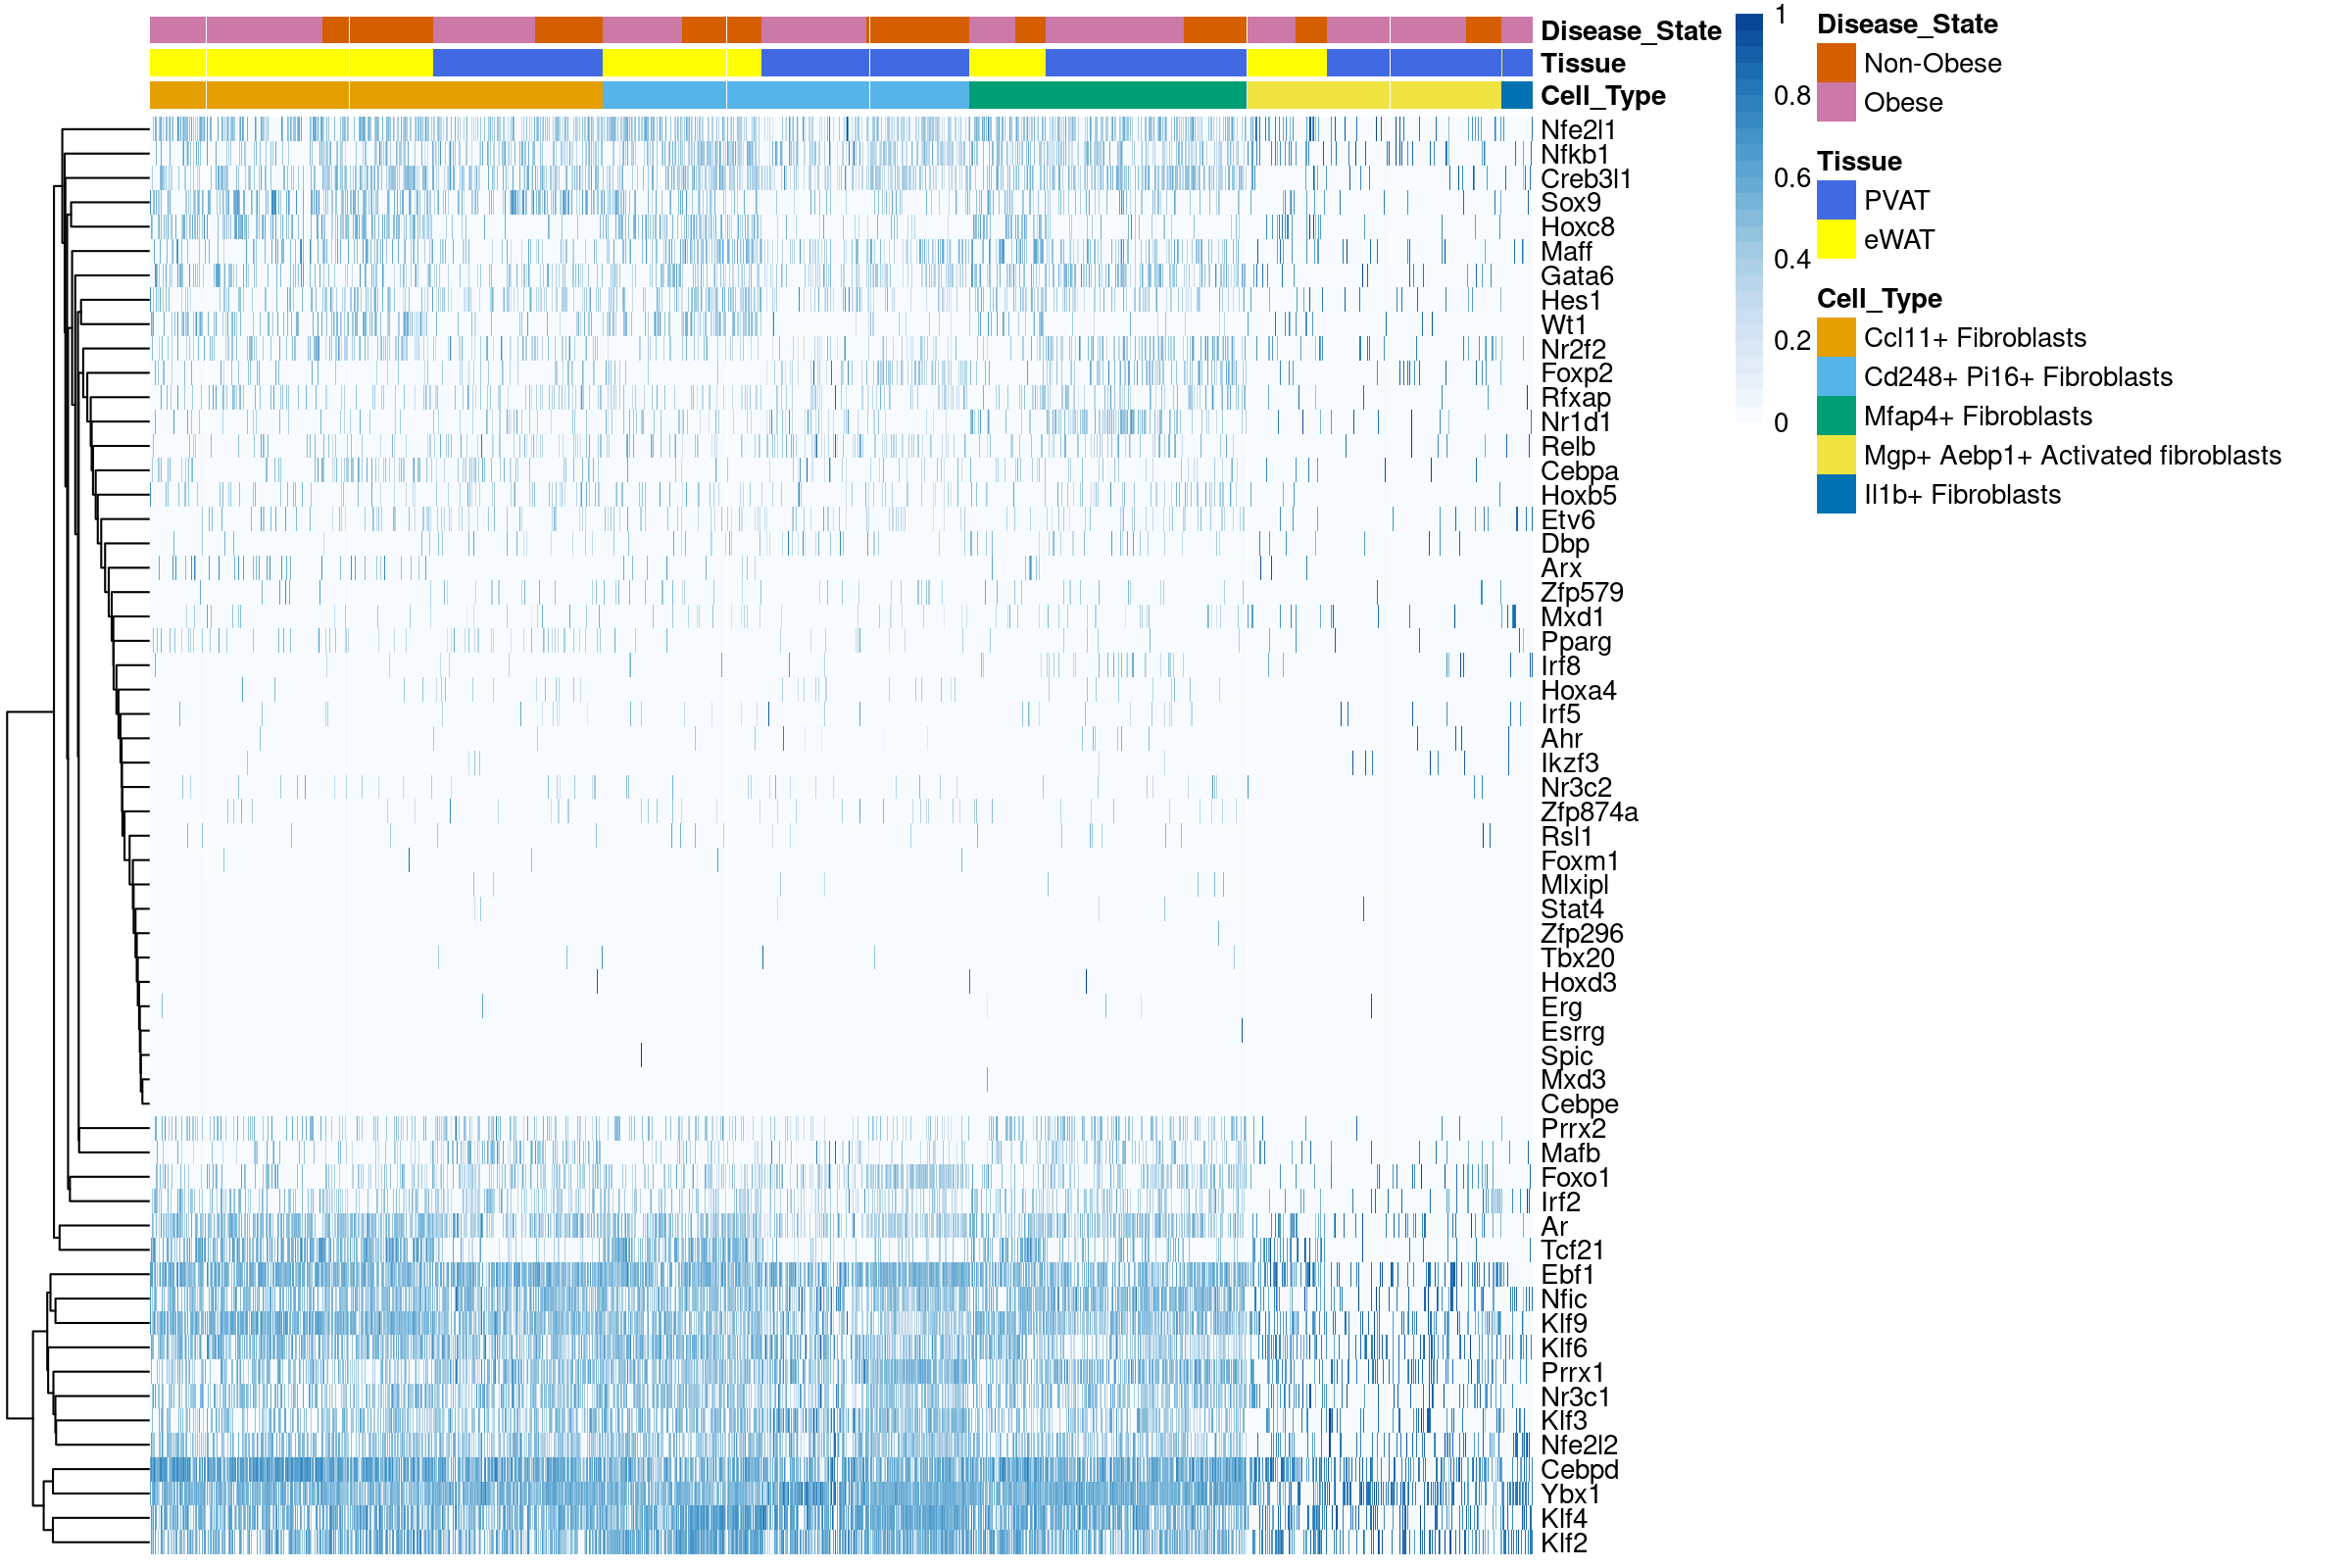

In [27]:
top_regulons_heatmap_rna <- dittoHeatmap(
    object = data,
    genes = top_reg,
    annot.by = c("Cell_Type", "Tissue", "Disease_State"),
    assay = "RNA",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'yellow')
    )
)

* Expression of **Tcf21** and **Hoxc8** is higher in eWAT.

In [28]:
ggsave(
    plot = top_regulons_heatmap_rna,
    filename = "top_regulons_heatmap_rna.png",
    width = 12,
    height = 8,
    dpi = 500
)

# RSS Plots For Fibroblast Subclusters Across All Tissues

In [29]:
colnames(rss_subcluster)

[1] "Cd248+ Pi16+ Fibroblasts"          "Mfap4+ Fibroblasts"               
[3] "Ccl11+ Fibroblasts"                "Mgp+ Aebp1+ Activated fibroblasts"
[5] "Il1b+ Fibroblasts"

In [30]:
ccl11_all <- plotRSS_twoSets(
    rss_subcluster_groups,
    set.1 = "Ccl11+ Fibroblasts_Non-Obese",
    set.2 = "Ccl11+ Fibroblasts_Obese",
    title = "Ccl11+ Fibroblasts (Non-Obese vs Obese)"
)

cd248_all <- plotRSS_twoSets(
    rss_subcluster_groups,
    set.1 = "Cd248+ Pi16+ Fibroblasts_Non-Obese",
    set.2 = "Cd248+ Pi16+ Fibroblasts_Obese",
    title = "Cd248+ Pi16+ Fibroblasts (Non-Obese vs Obese)"
)

mfap4_all <- plotRSS_twoSets(
    rss_subcluster_groups,
    set.1 = "Mfap4+ Fibroblasts_Non-Obese",
    set.2 = "Mfap4+ Fibroblasts_Obese",
    title = "Mfap4+ Fibroblasts (Non-Obese vs Obese)"
)

mgp_all <- plotRSS_twoSets(
    rss_subcluster_groups,
    set.1 = "Mgp+ Aebp1+ Activated fibroblasts_Non-Obese",
    set.2 = "Mgp+ Aebp1+ Activated fibroblasts_Obese",
    title = "Mgp+ Aebp1+ Activated Fibroblasts (Non-Obese vs Obese)"
)

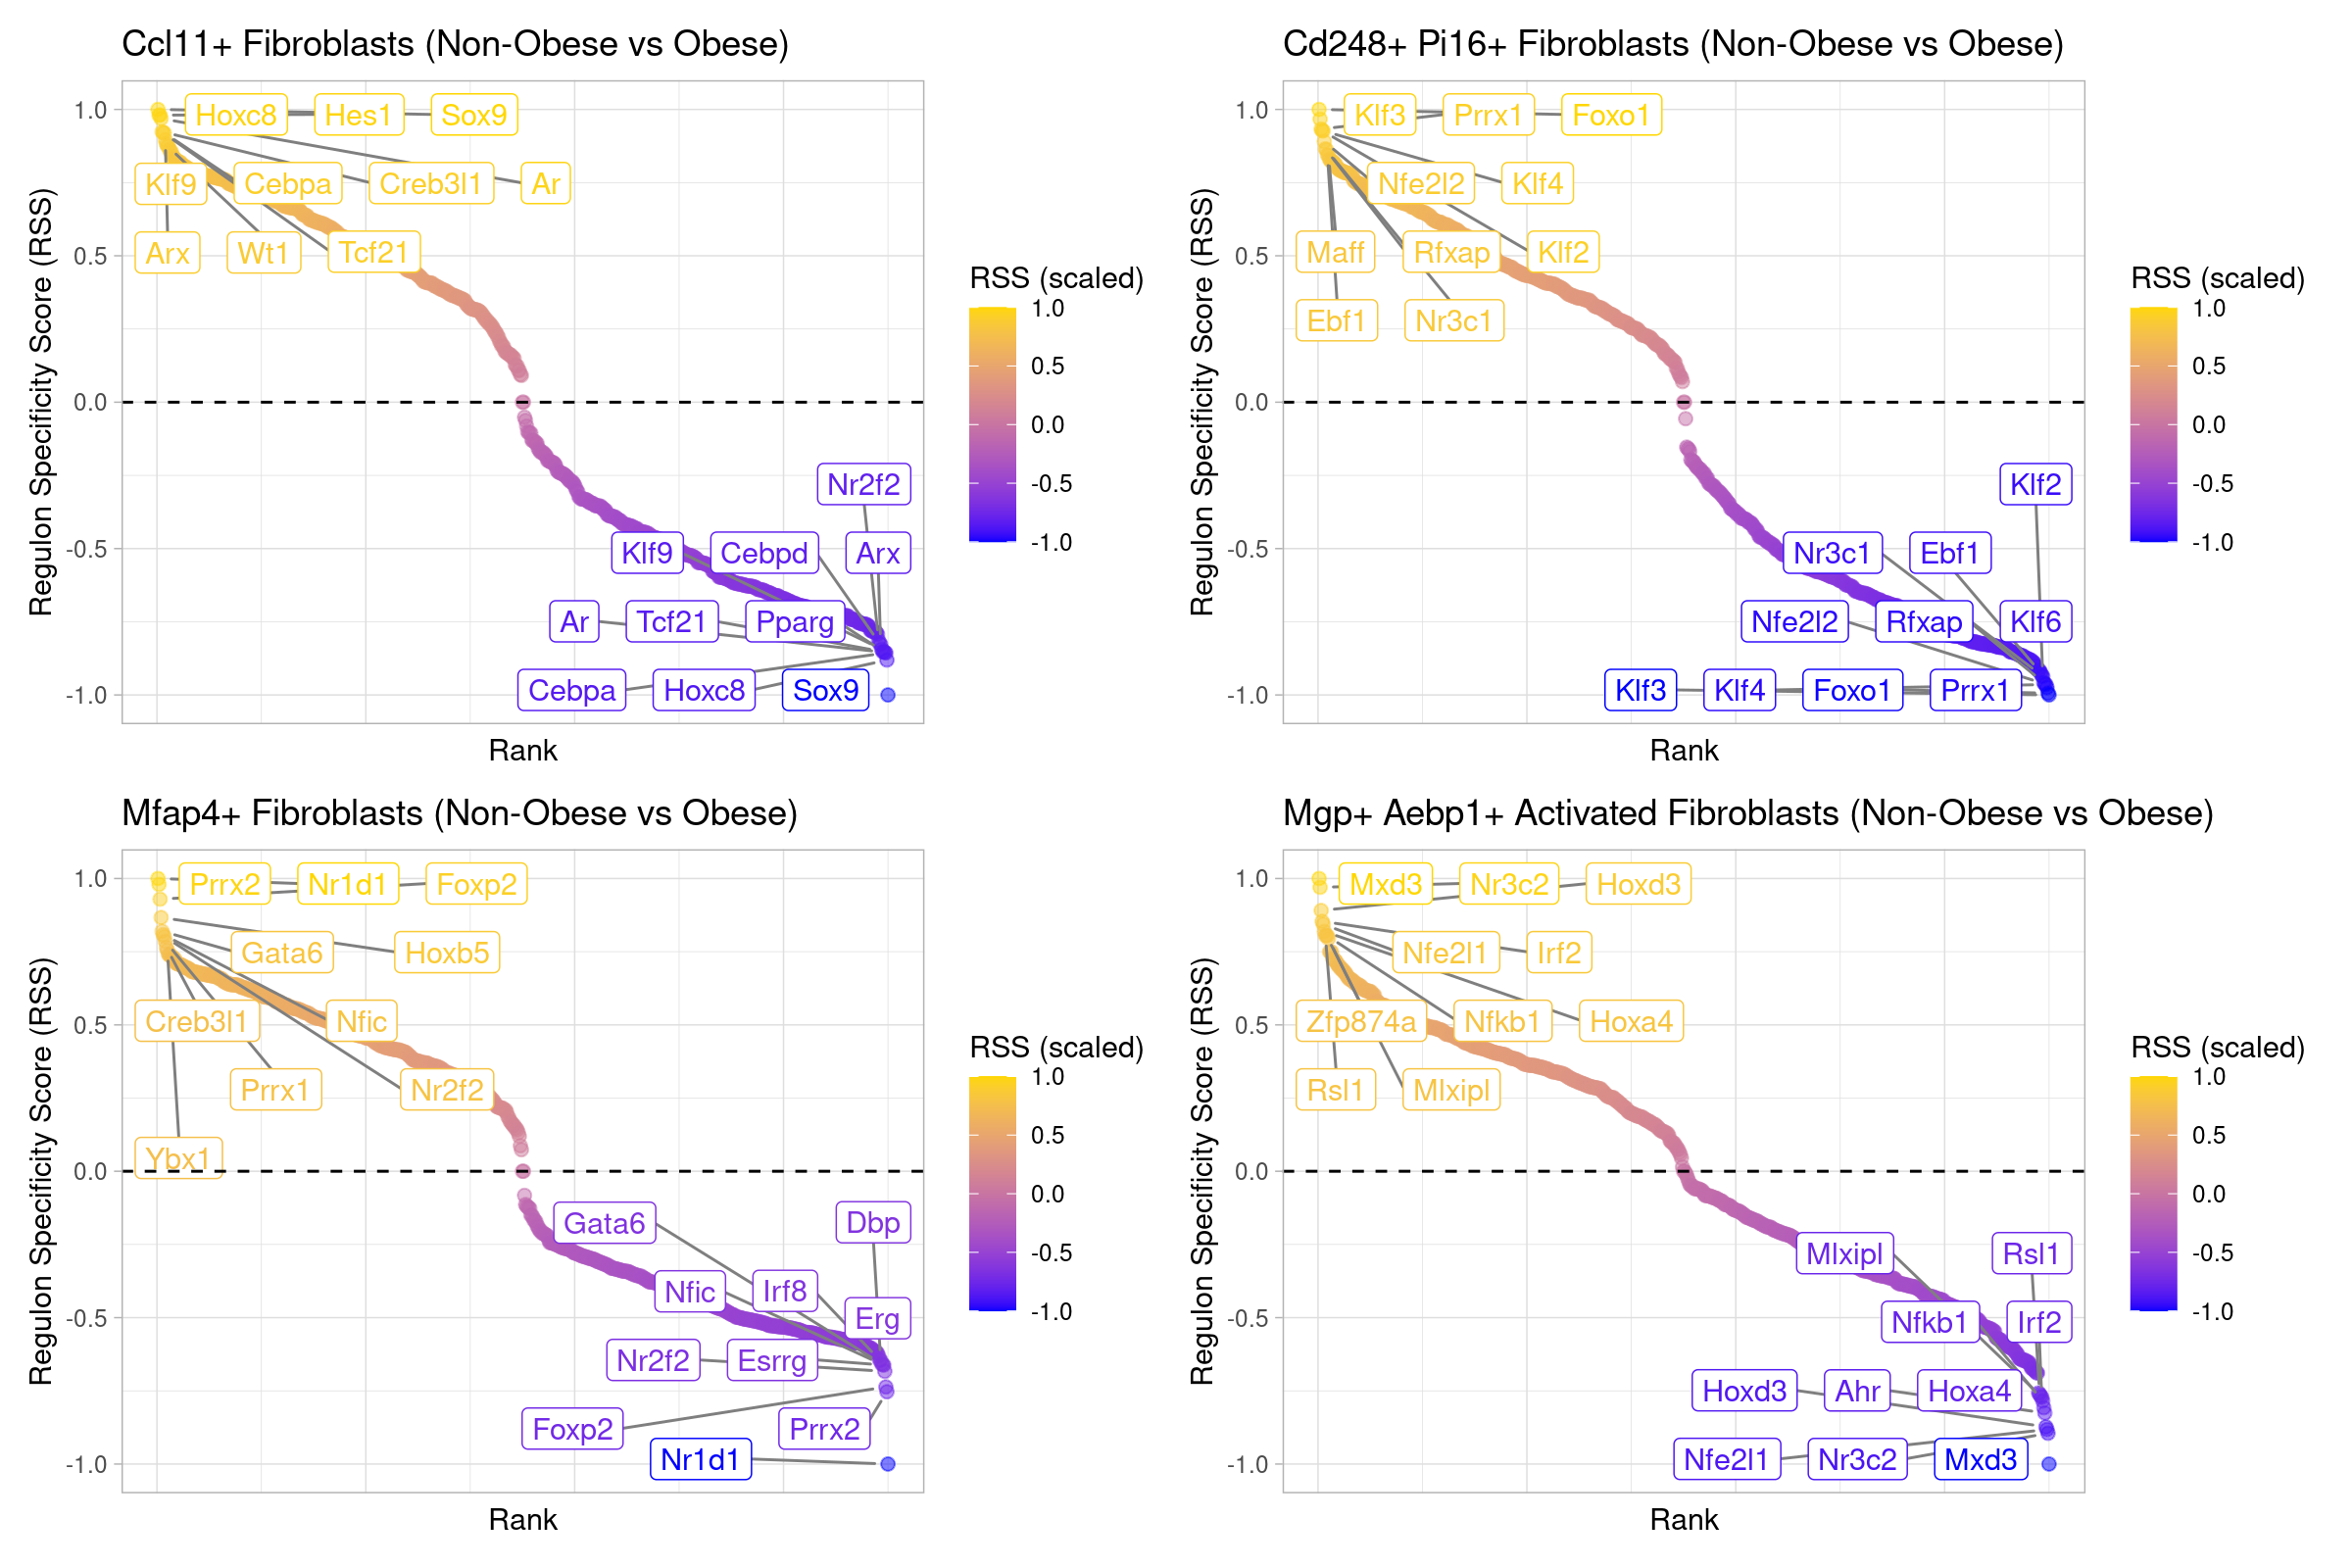

In [20]:
(ccl11_all + cd248_all) / (mfap4_all + mgp_all)

In [32]:
# This fibroblasts subcluster is only found in obesity.
Il1b_rss <- plotRSS_oneSet(
    rss = rss_subcluster,
    setName = "Il1b+ Fibroblasts"
)

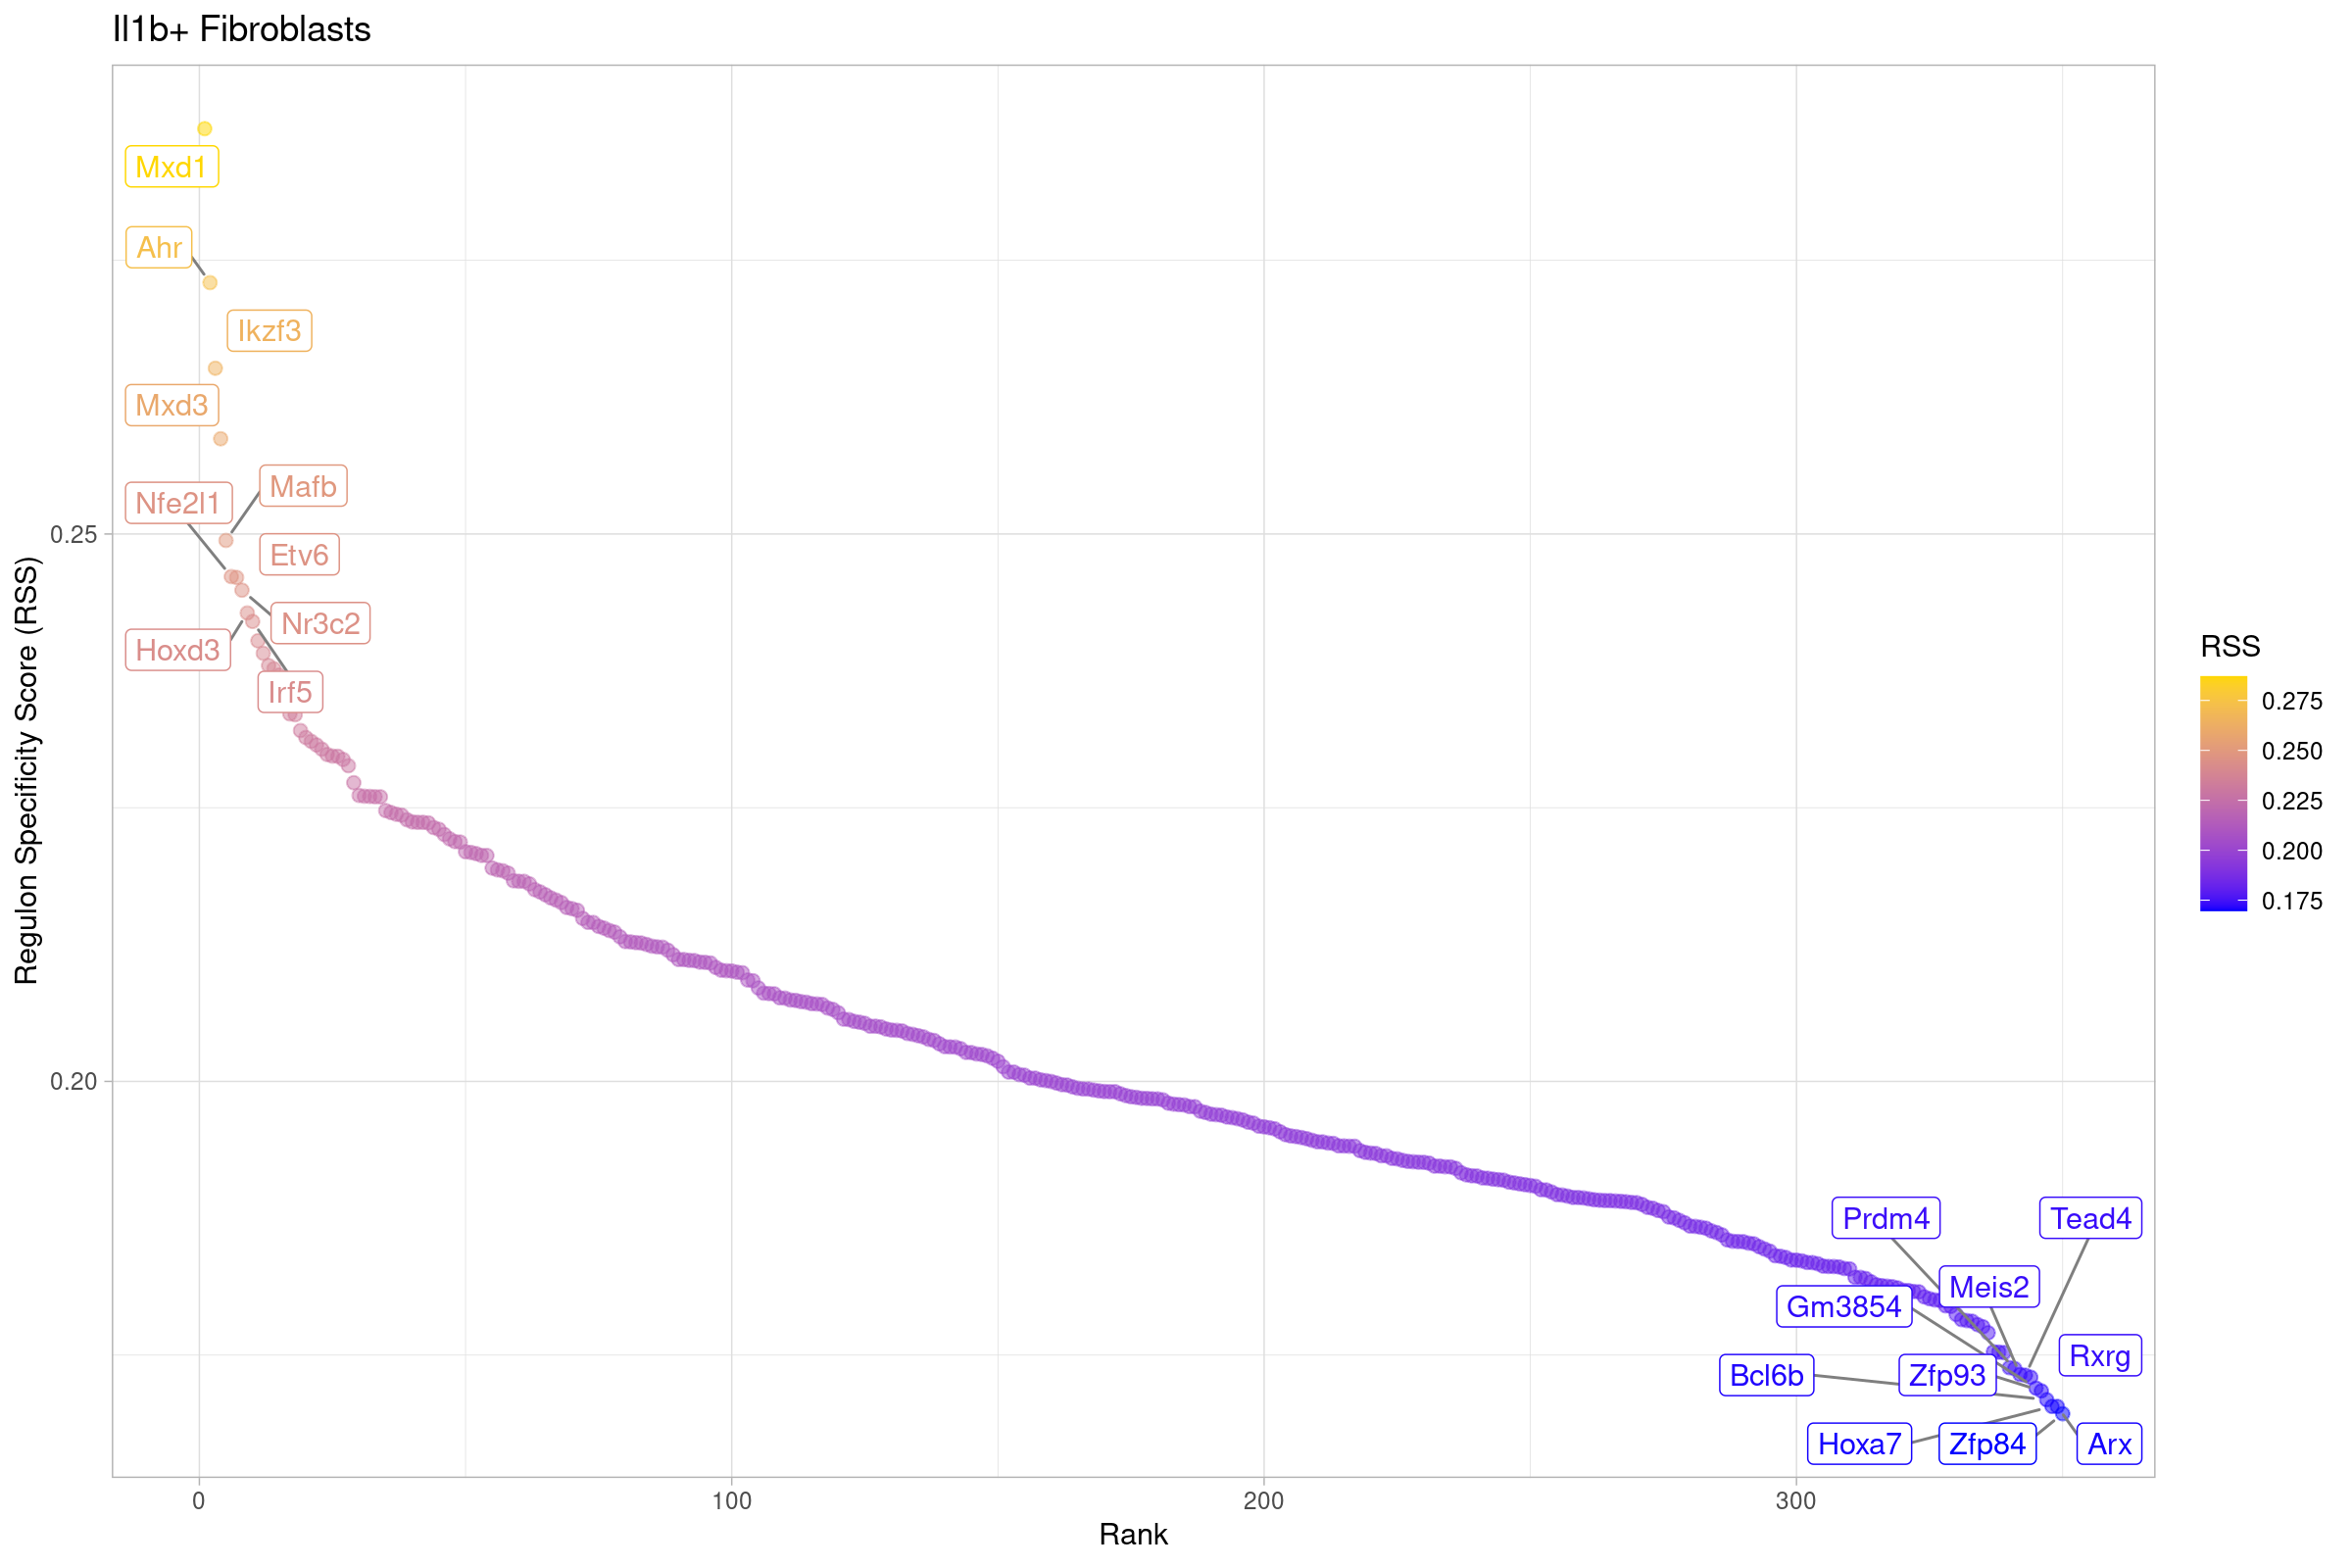

In [33]:
Il1b_rss

In [38]:
ggsave(
    plot = (ccl11_all + cd248_all) / (mfap4_all + mgp_all) / (Il1b_rss + plot_spacer()),
    filename = "rss_plots.png",
    width = 12,
    height = 12,
    dpi = 1000
)

### Ccl11+ Fibroblasts
* Tcf21 and Hoxc8 transcription factors have higher activity in eWAT than in PVAT. Also, they are among the top transcription factors for Ccl11+ fibroblasts.
* Hes1 is more active in non-obese eWAT than obese eWAT.
* Similar to Tcf21 and Hoxc8, Ar and Klf9 TFs are more activite in eWAT.
* Cebpd is more active in obese eWAT.

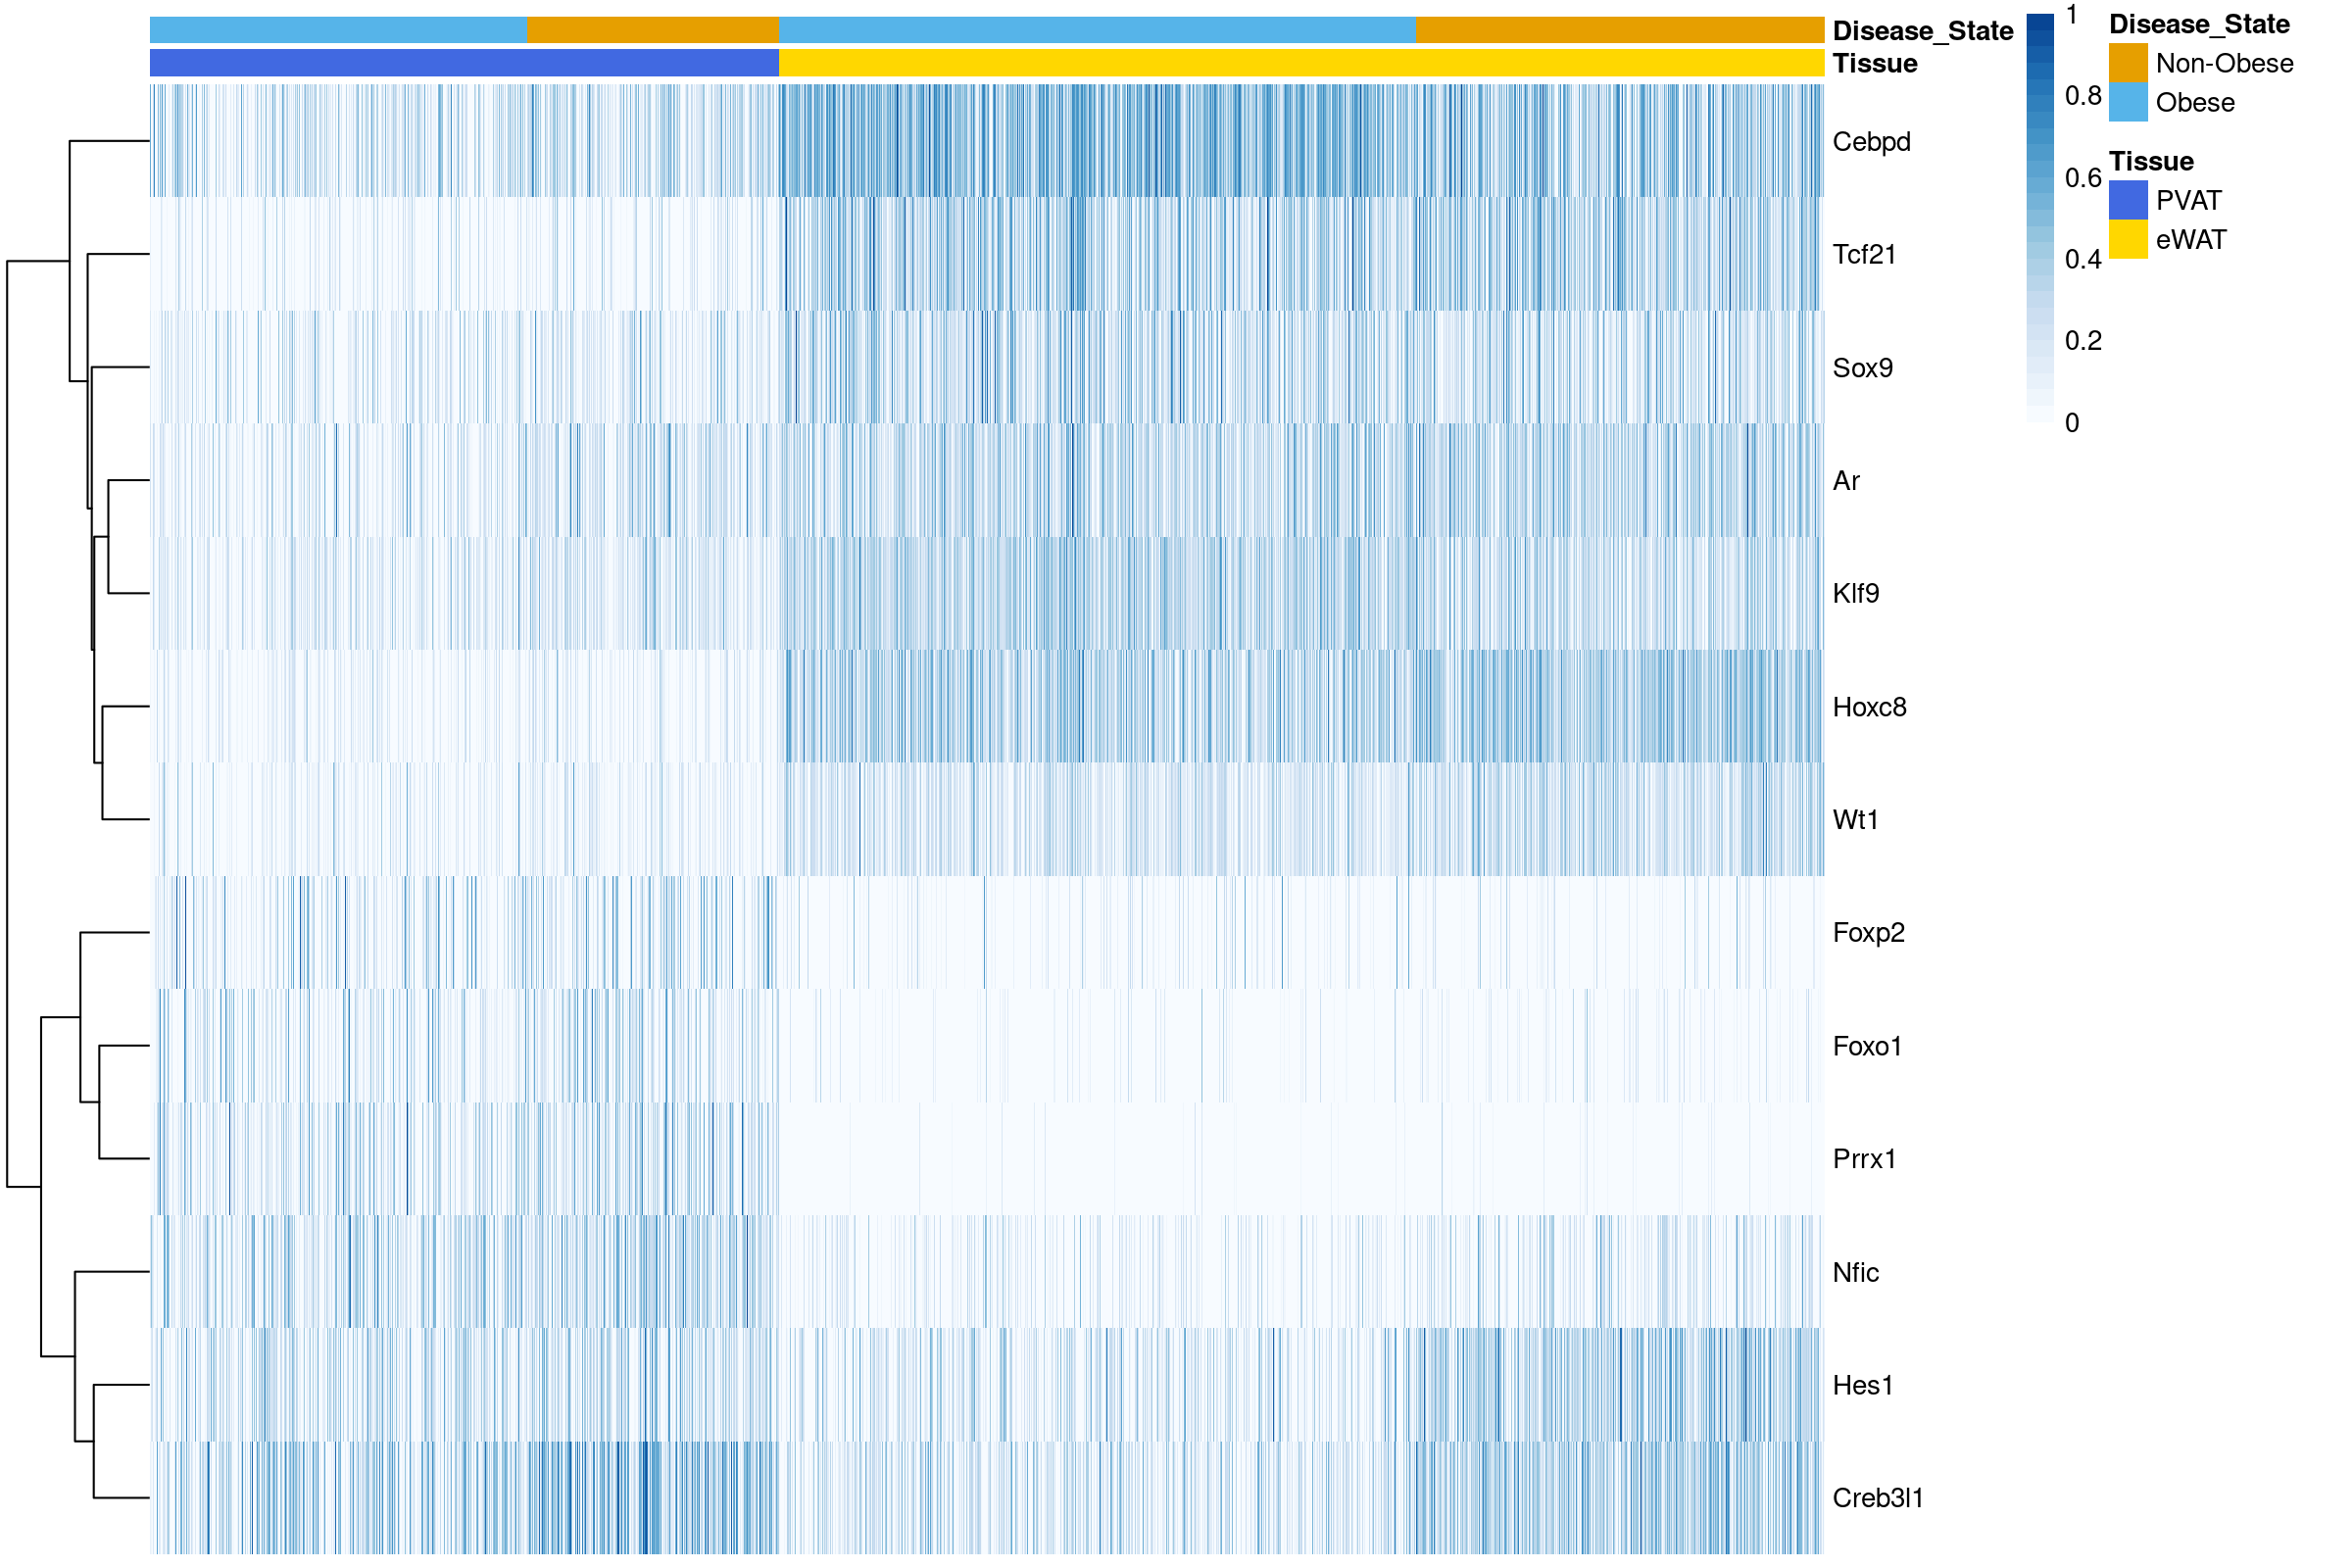

In [39]:
ccl11_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Ccl11+ Fibroblasts"),
    genes = c("Hoxc8", "Tcf21", "Hes1", "Wt1", "Cebpd", "Creb3l1", "Ar", "Klf9", "Sox9", "Nfic", "Foxo1", "Prrx1", "Foxp2"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "SCENIC_AUC_Z",
    slot = "data",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

* Wt1, Creb3l1, and Hes1 are more active in non-obese eWAT.
* Wt1 is not active in PVAT.

In [41]:
ggsave(
    plot = ccl11_heatmap,
    filename = "ccl11_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

#### Show the Related Genes on Dot Plot

In [42]:
ccl11_dotplot <- dittoDotPlot(
    object = subset(data, Cell_Type == "Ccl11+ Fibroblasts"),
    vars = c("Hoxc8", "Tcf21", "Hes1", "Wt1", "Cebpd", "Creb3l1", "Ar", "Klf9", "Sox9", "Nfic", "Foxo1", "Prrx1", "Foxp2"),
    group.by = "Tissue",
    split.by = "Disease_State",
    min.color = "blue",
    max.color = "gold",
    legend.color.title = "AUC",
    legend.size.title = "Percentage",
    theme = theme_light(),
    assay = "SCENIC_AUC",
    summary.fxn.size = function(x) {
        mean(x > 0.1)
        }
)

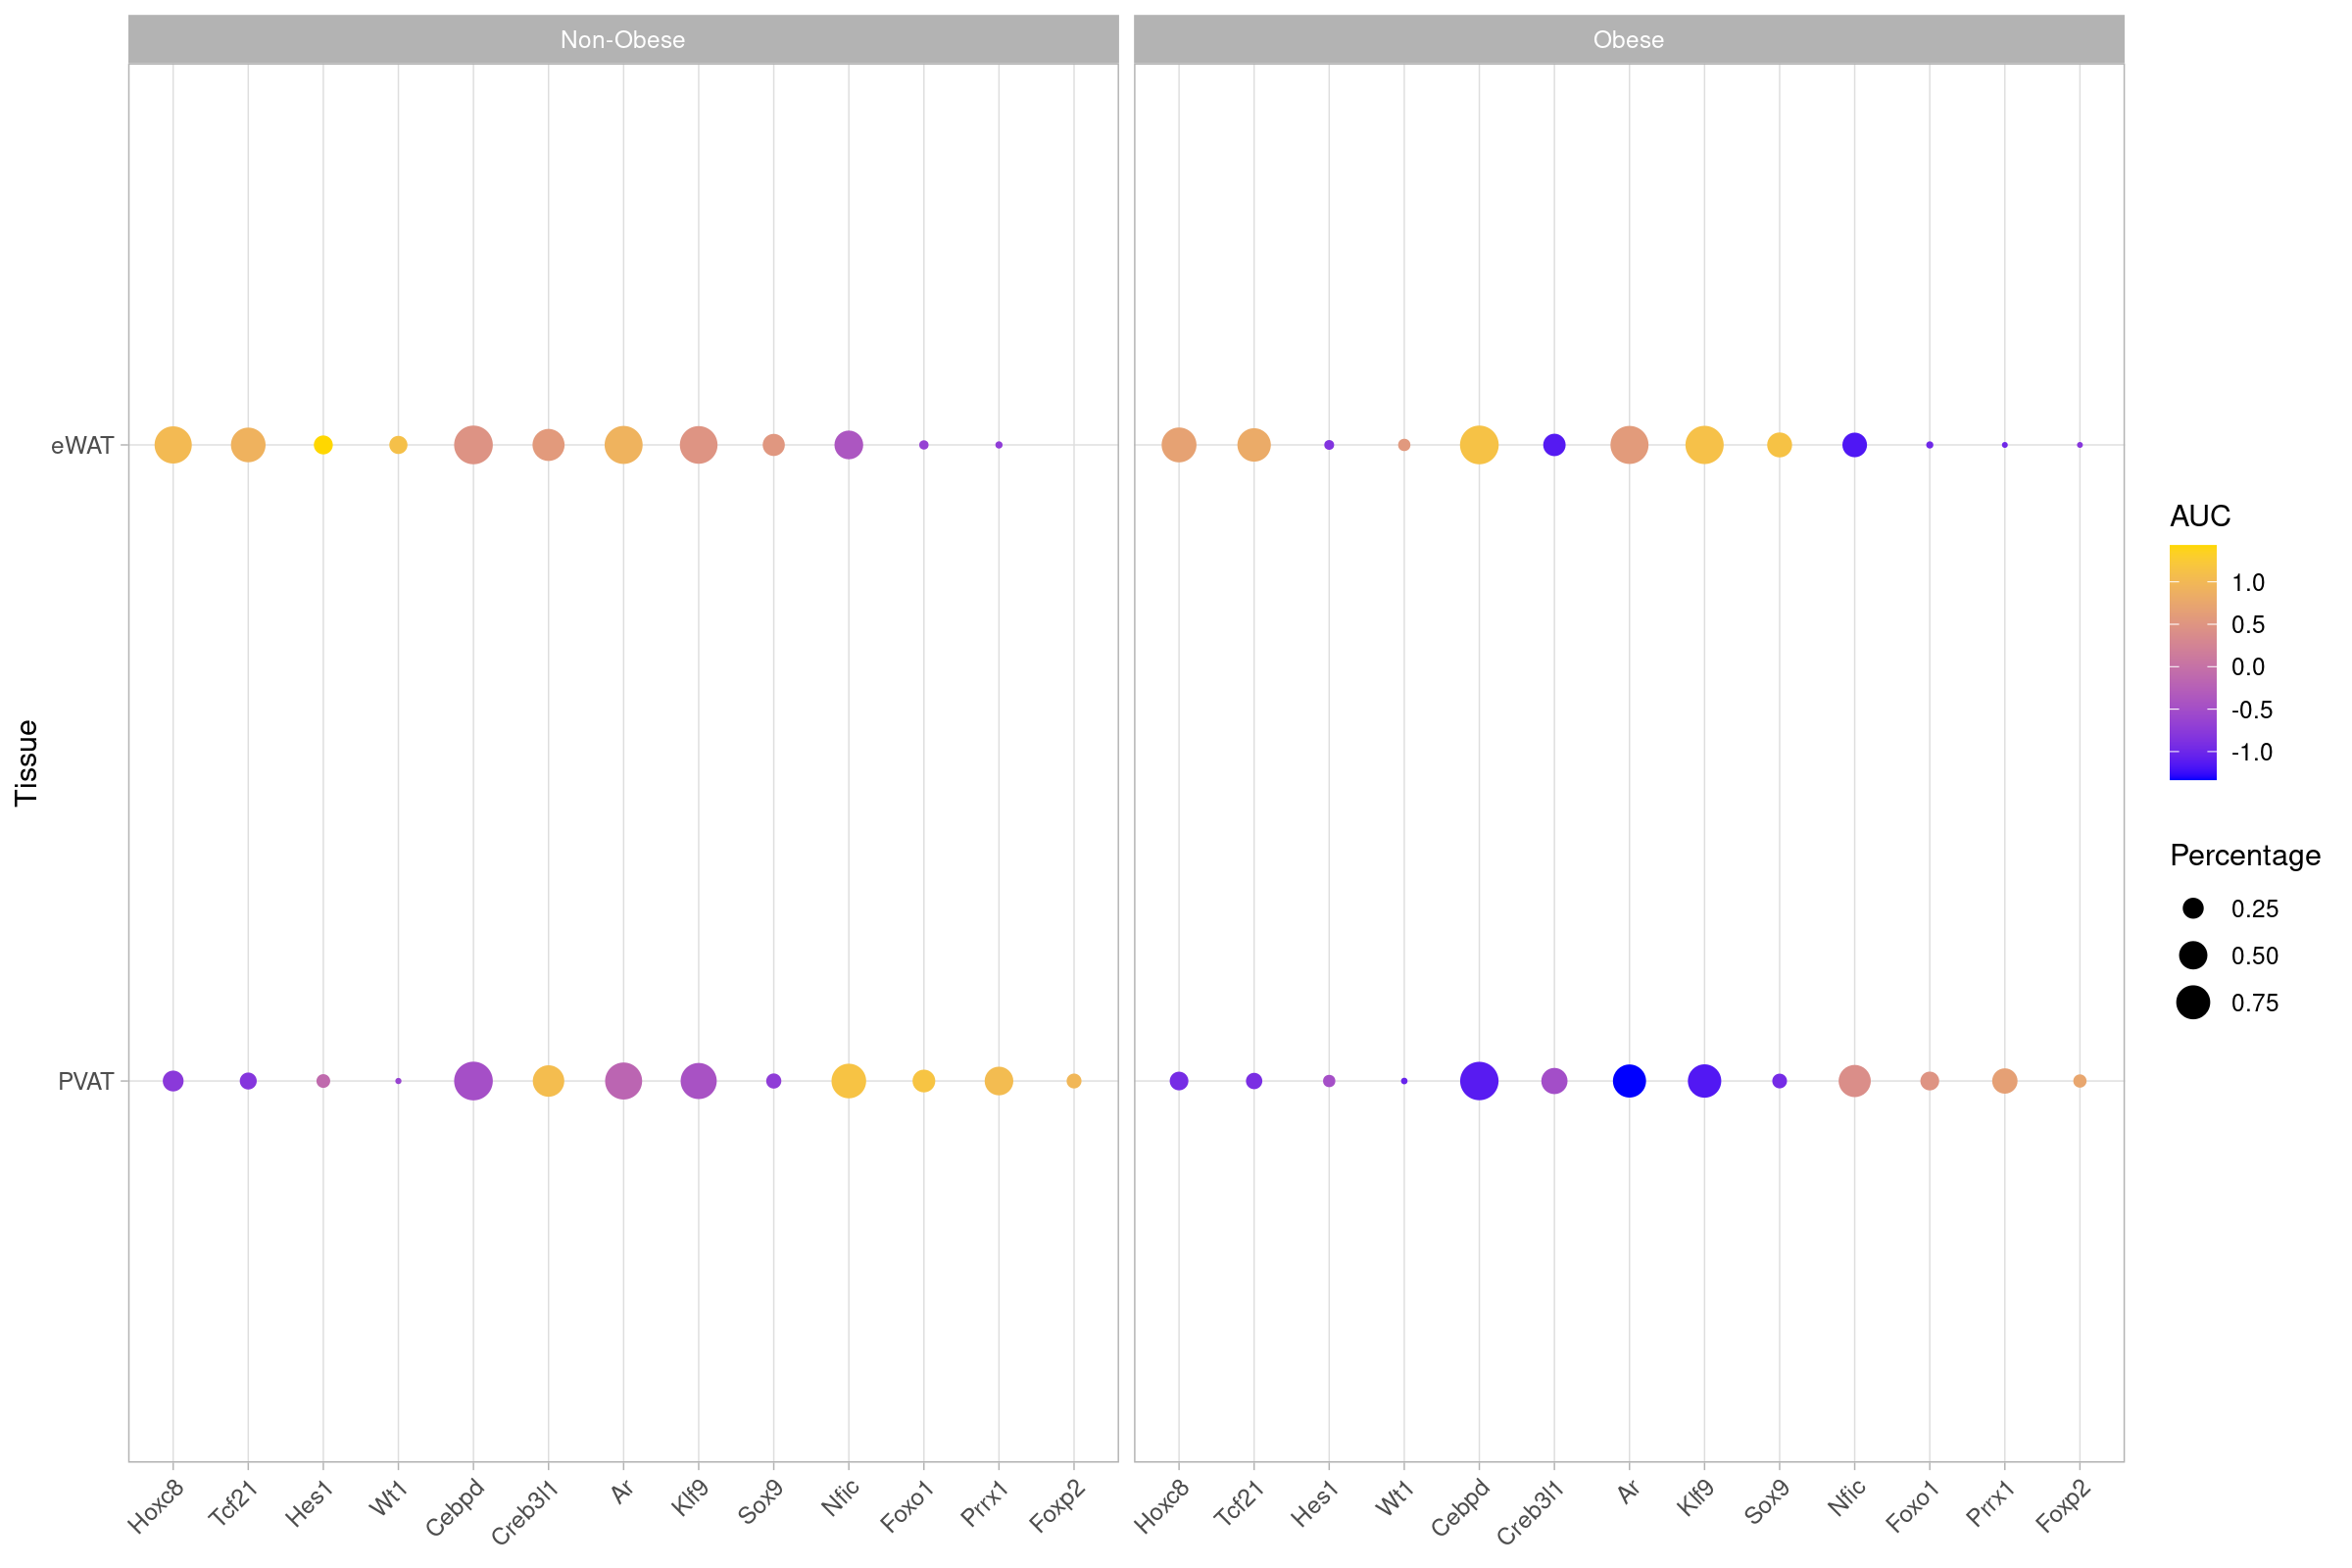

In [71]:
ccl11_dotplot

* Dot plot also suggests that activities of Tcf21 and Hoxc8 in Ccl11+ fibroblasts are higher in eWAT than in PVAT.
* Nfic, Foxp2, Foxo1, and Prrx1 are more active in PVAT (especially in non-obese PVAT).
* Creb3l1 is more active in fibroblasts in non-obese tissues, especially PVAT.
* Cebpd and Klf9 are more active in obese eWAT. On the contrary, they are more active in non-obese PVAT.
* Klf9 and Sox9 are more active in obese eWAT.

In [43]:
ggsave(
    plot = ccl11_dotplot,
    filename = "ccl11_dotplot.png",
    width = 12,
    height = 8,
    dpi = 500
)

#### Gene Expression Heatmap

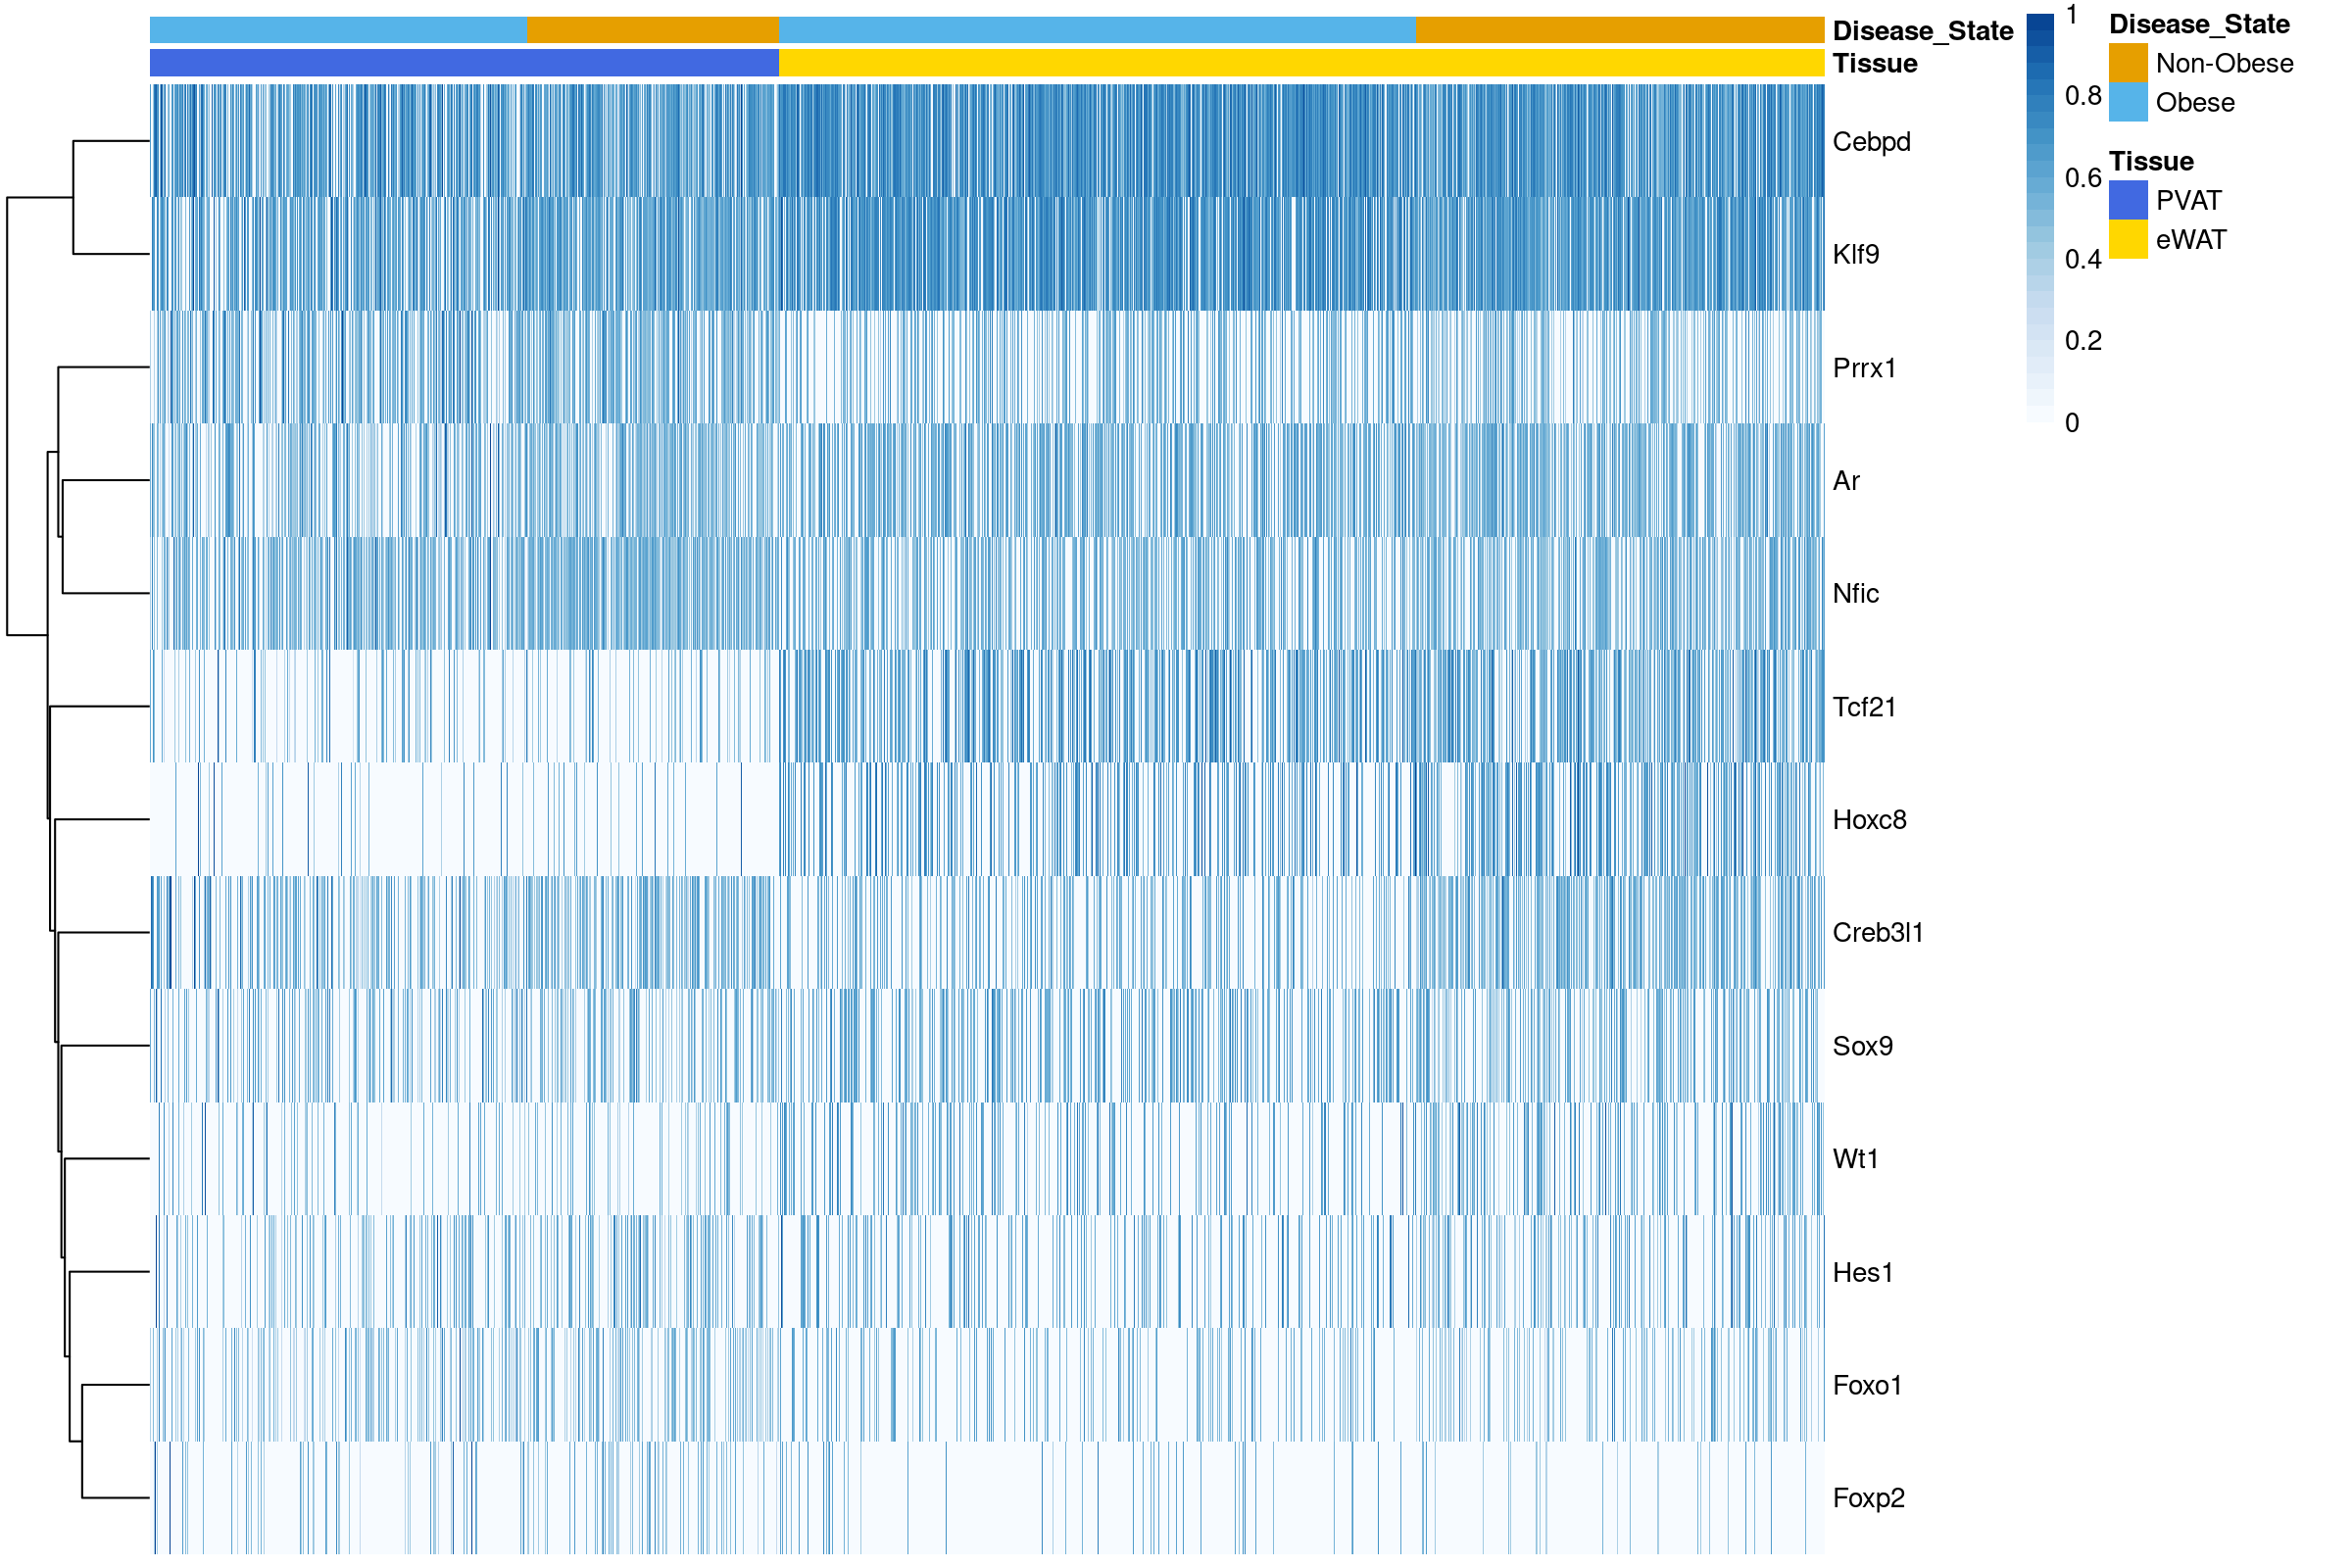

In [44]:
ccl11_rna_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Ccl11+ Fibroblasts"),
    genes = c("Hoxc8", "Tcf21", "Hes1", "Wt1", "Cebpd", "Creb3l1", "Ar", "Klf9", "Sox9", "Nfic", "Foxo1", "Prrx1", "Foxp2"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "RNA",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

* In line with the SCENIC results, **Tcf21** and **Hoxc8** expression higher in the eWAT.
* **Creb3l1** gene expression is higher in the non-obese tissues.
* **Cebpd** and **Klf9** expressed more in eWAT.

In [45]:
ggsave(
    plot = ccl11_rna_heatmap,
    filename = "ccl11_rna_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

### Cd248+ Pi16+ Fibroblasts

* RSS Plot suggests that **Klf3**, **Prrx1**, and **Foxo1** are the top regulons in this fibroblasts subcluster.
* Fibroblasts in this group have high activity of **Klf2**, **Klf3**, **Klf4**, and **Nfe2l2**. These regulons seem to be less active in obesity?
* Similar to Ccl11+ fibroblasts, **Tcf21** and **Hoxc8** TFs are more active in eWAT (also **Hes1**). In contrast, **Foxo1** and **Prrx1** are more active in PVAT. However, the activity is higher in non-obese PVAT.

#### Make a Heatmap Using the Above-Mentioned Genes

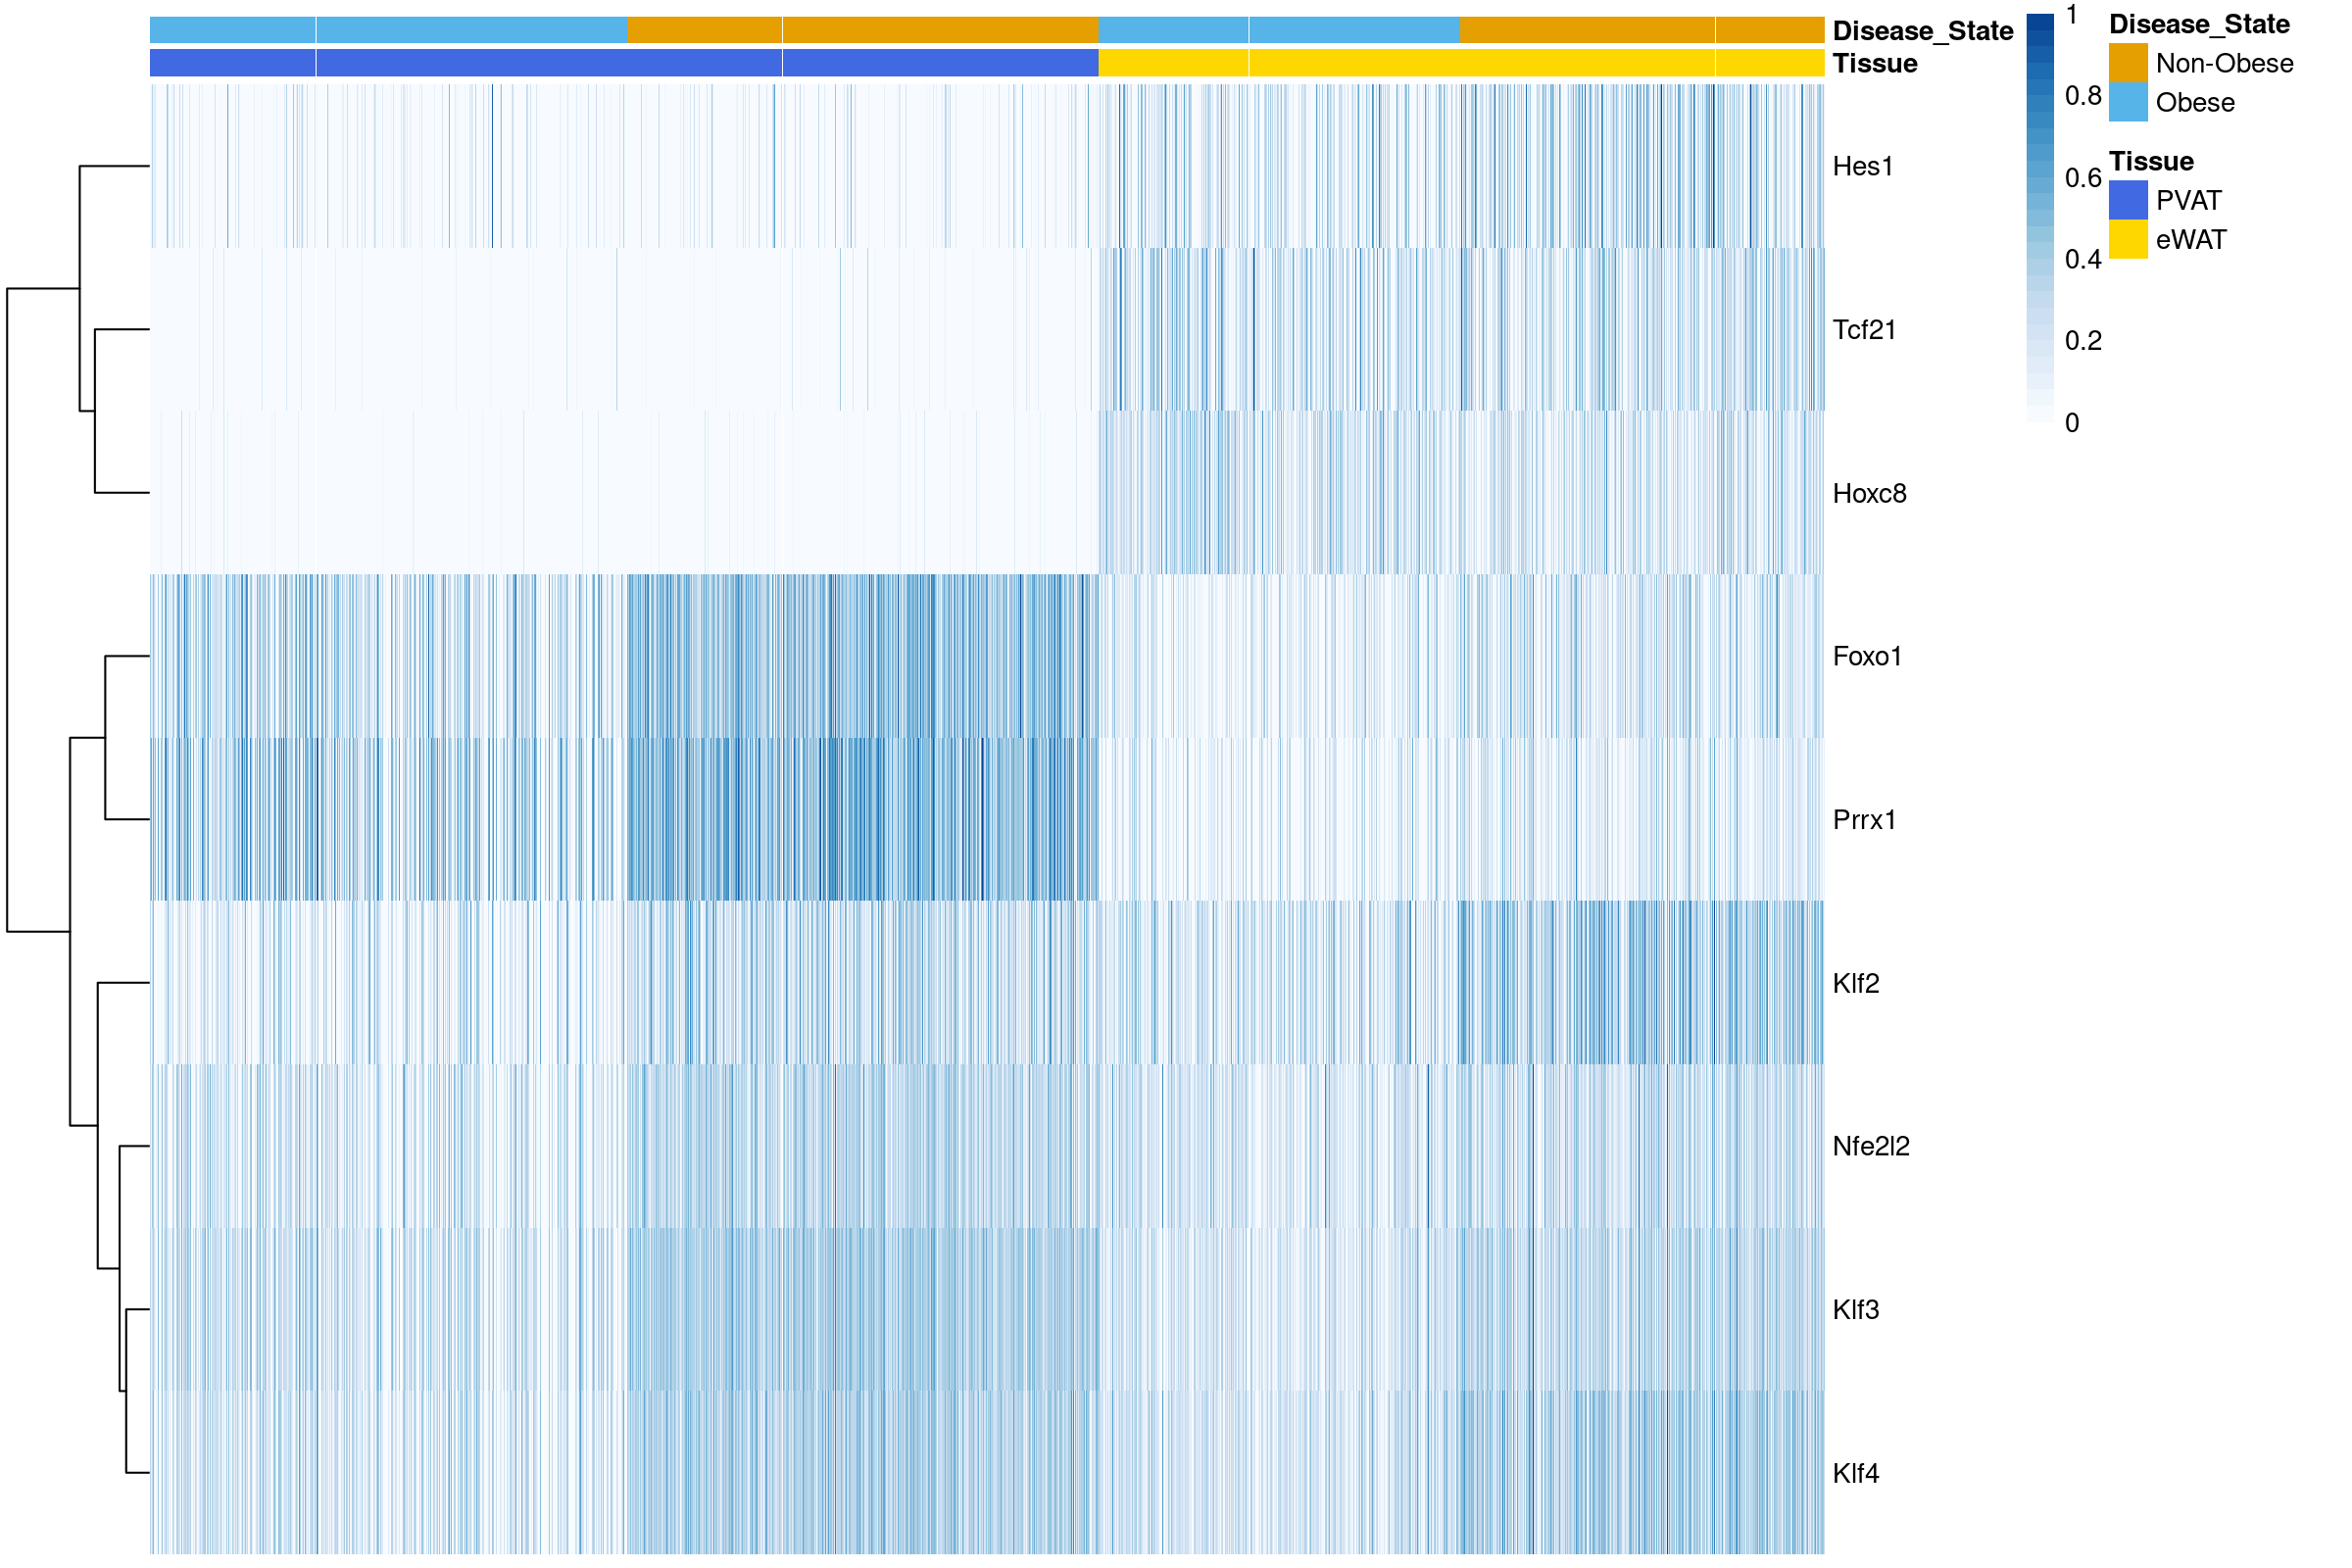

In [46]:
cd248_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Cd248+ Pi16+ Fibroblasts"),
    genes = c("Klf2", "Klf3", "Klf4", "Nfe2l2", "Tcf21", "Hoxc8", "Hes1", "Foxo1", "Prrx1"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "SCENIC_AUC_Z",
    slot = "data",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

* We can clearly see the differences in this heatmap.
* **Hoxc8**, **Tcf21**, and **Hes1** regulons are almost exclusively active in eWAT.
* **Foxo1** and **Prrx1** are more active in non-obese PVAT.
* The other regulons are active in both tissues but more in the non-obese tissues.

In [47]:
ggsave(
    plot = cd248_heatmap,
    filename = "cd248_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

#### Show the Related Genes on a Dot Plot

In [68]:
cd248_dotplot <- dittoDotPlot(
    object = subset(data, Cell_Type == "Cd248+ Pi16+ Fibroblasts"),
    vars = c("Klf2", "Klf3", "Klf4", "Nfe2l2", "Tcf21", "Hoxc8", "Hes1", "Foxo1", "Prrx1"),
    group.by = "Tissue",
    split.by = "Disease_State",
    min.color = "blue",
    max.color = "gold",
    legend.color.title = "AUC",
    legend.size.title = "Percentage",
    theme = theme_light(),
    assay = "SCENIC_AUC",
    summary.fxn.size = function(x) {
        mean(x > 0.1)
        }
)

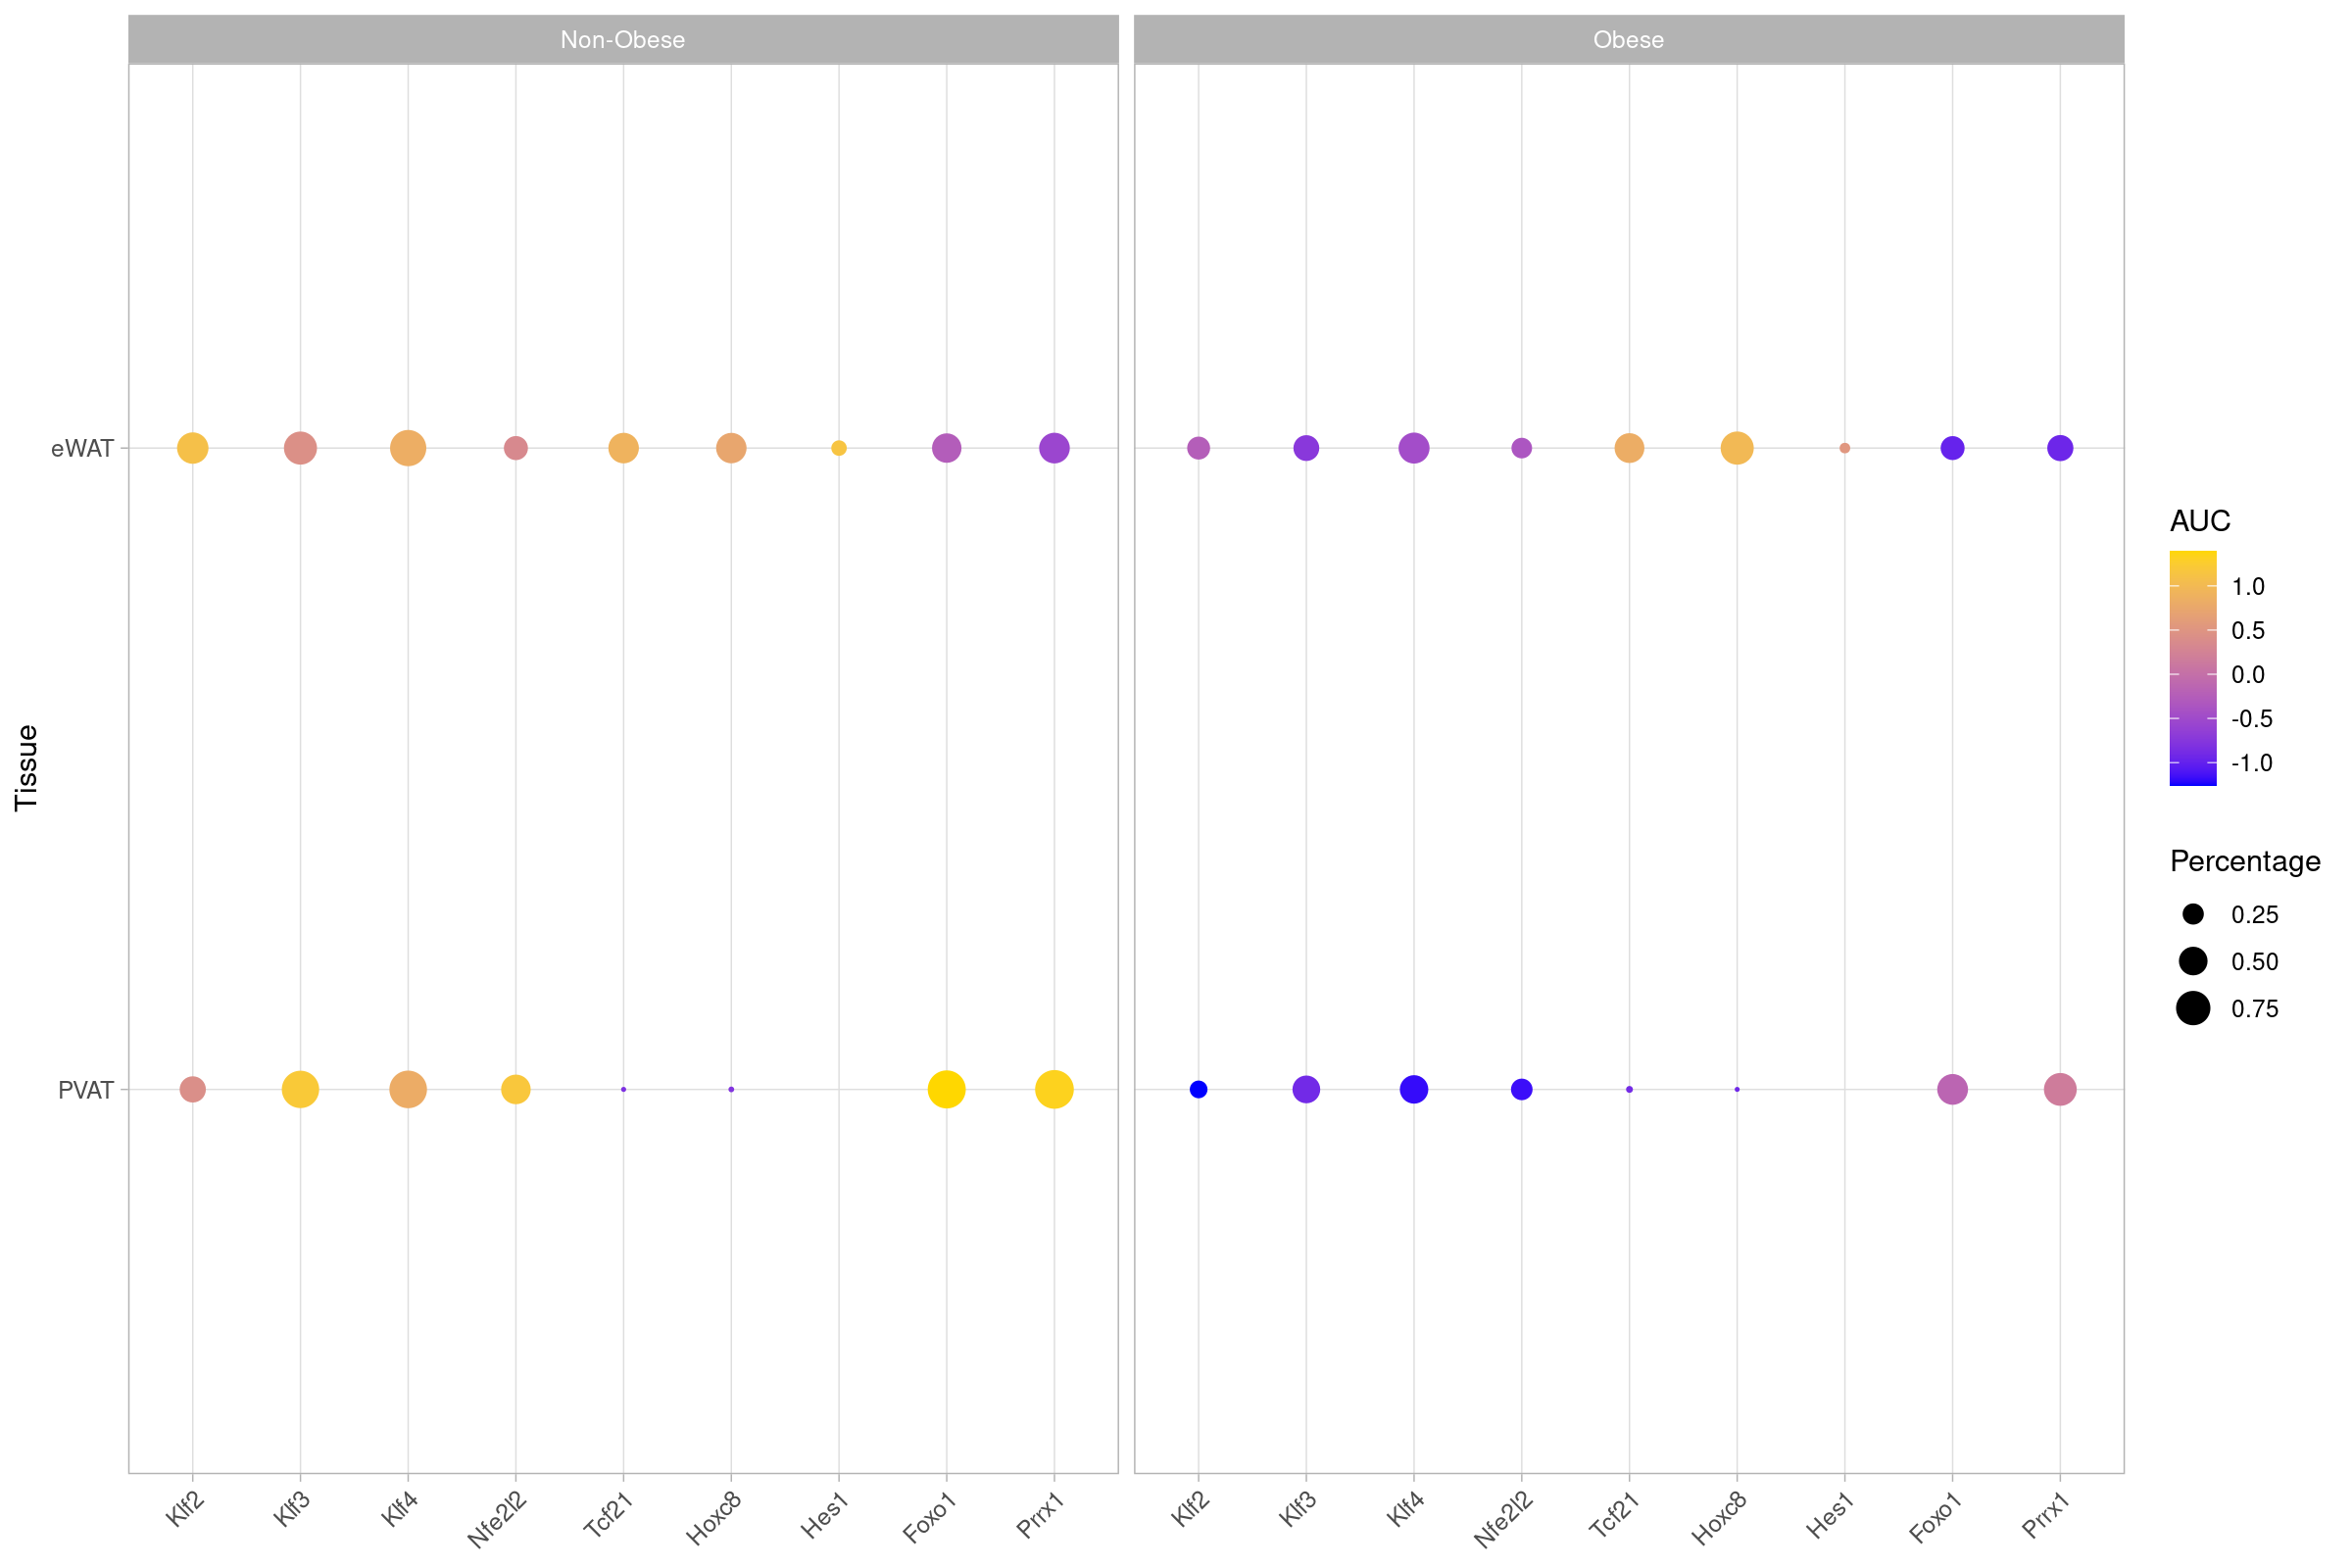

In [69]:
cd248_dotplot

In [49]:
ggsave(
    plot = cd248_dotplot,
    filename = "cd248_dotplot.png",
    width = 12,
    height = 8,
    dpi = 500
)

#### Gene Expression Heatmap

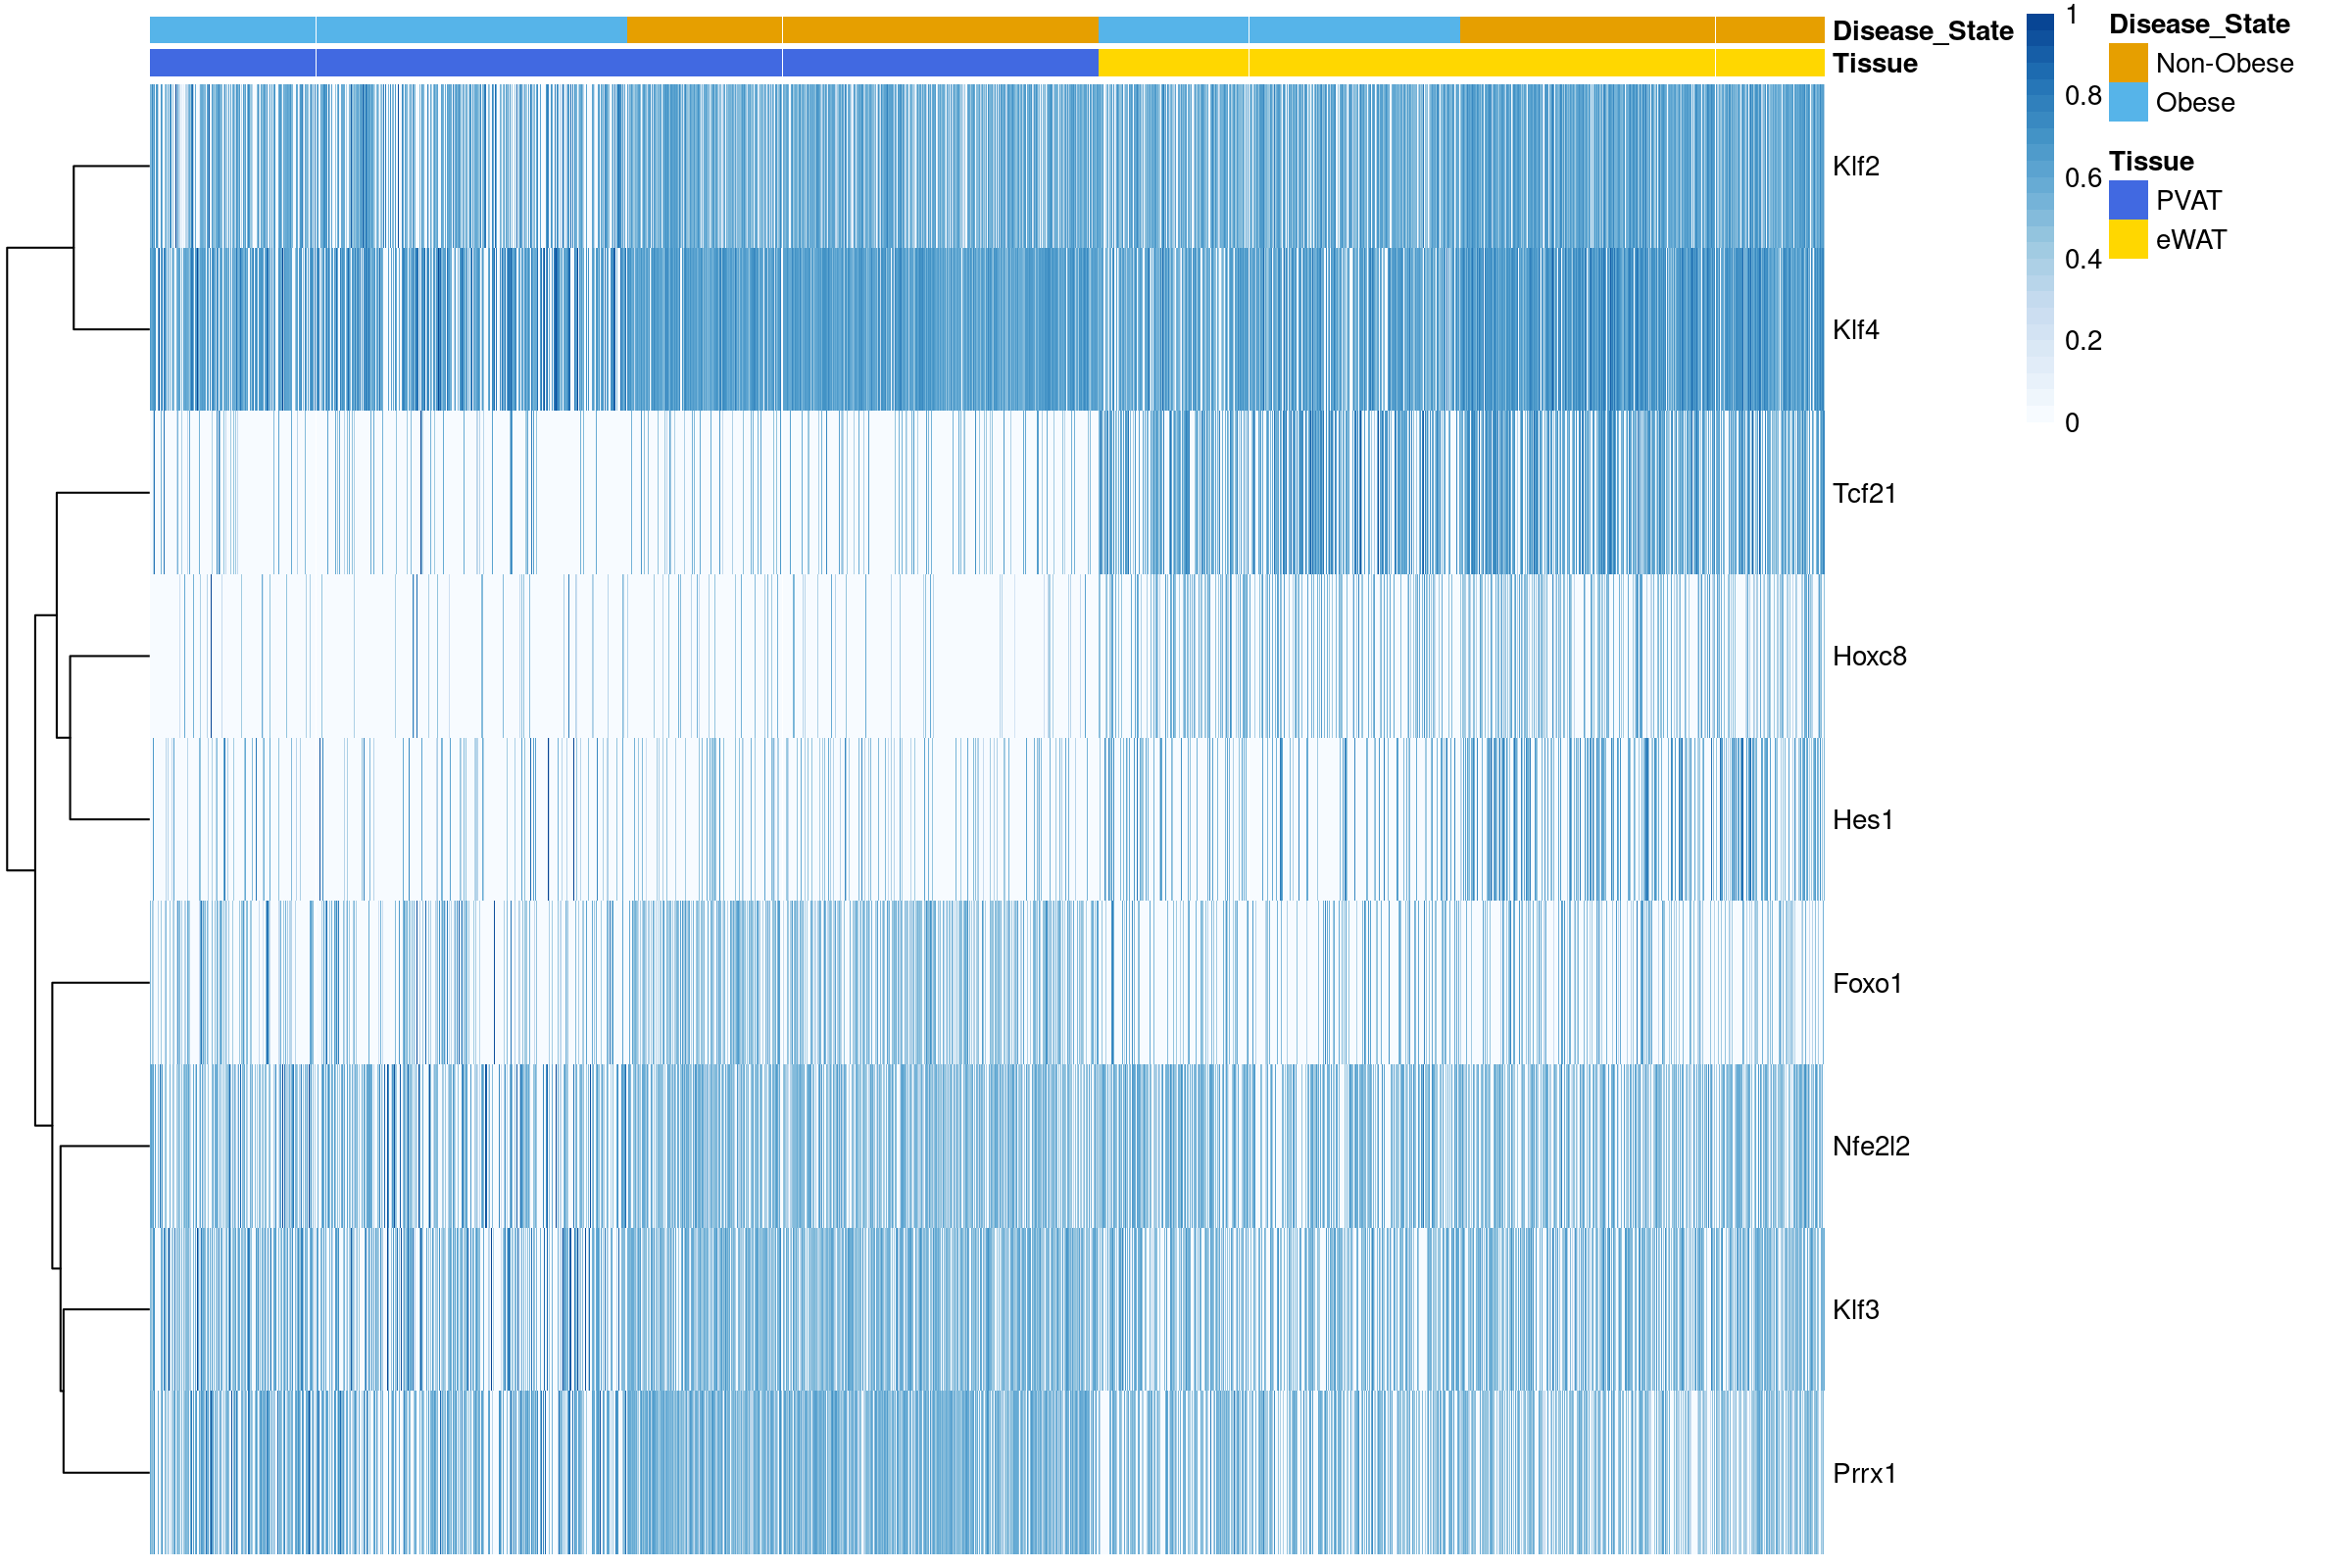

In [50]:
cd248_rna_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Cd248+ Pi16+ Fibroblasts"),
    genes = c("Klf2", "Klf3", "Klf4", "Nfe2l2", "Tcf21", "Hoxc8", "Hes1", "Foxo1", "Prrx1"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "RNA",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

* In line with the SCENIC results, **Tcf21**, **Hoxc8**, and **Hes1** gene expression is higher in the eWAT.
* **Klf2** and **Klf4** have the highest gene expression.

In [51]:
ggsave(
    plot = cd248_rna_heatmap,
    filename = "cd248_rna_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

### Mfap4+ Fibroblasts

* The top 3 regulons for this fibroblast subcluster are **Nr1d1**, **Prrx2**, and **Foxp2**.
* Again, **Tcf21** and **Hoxc8** are only active in eWAT.

#### Make a Heatmap Using the Top Genes

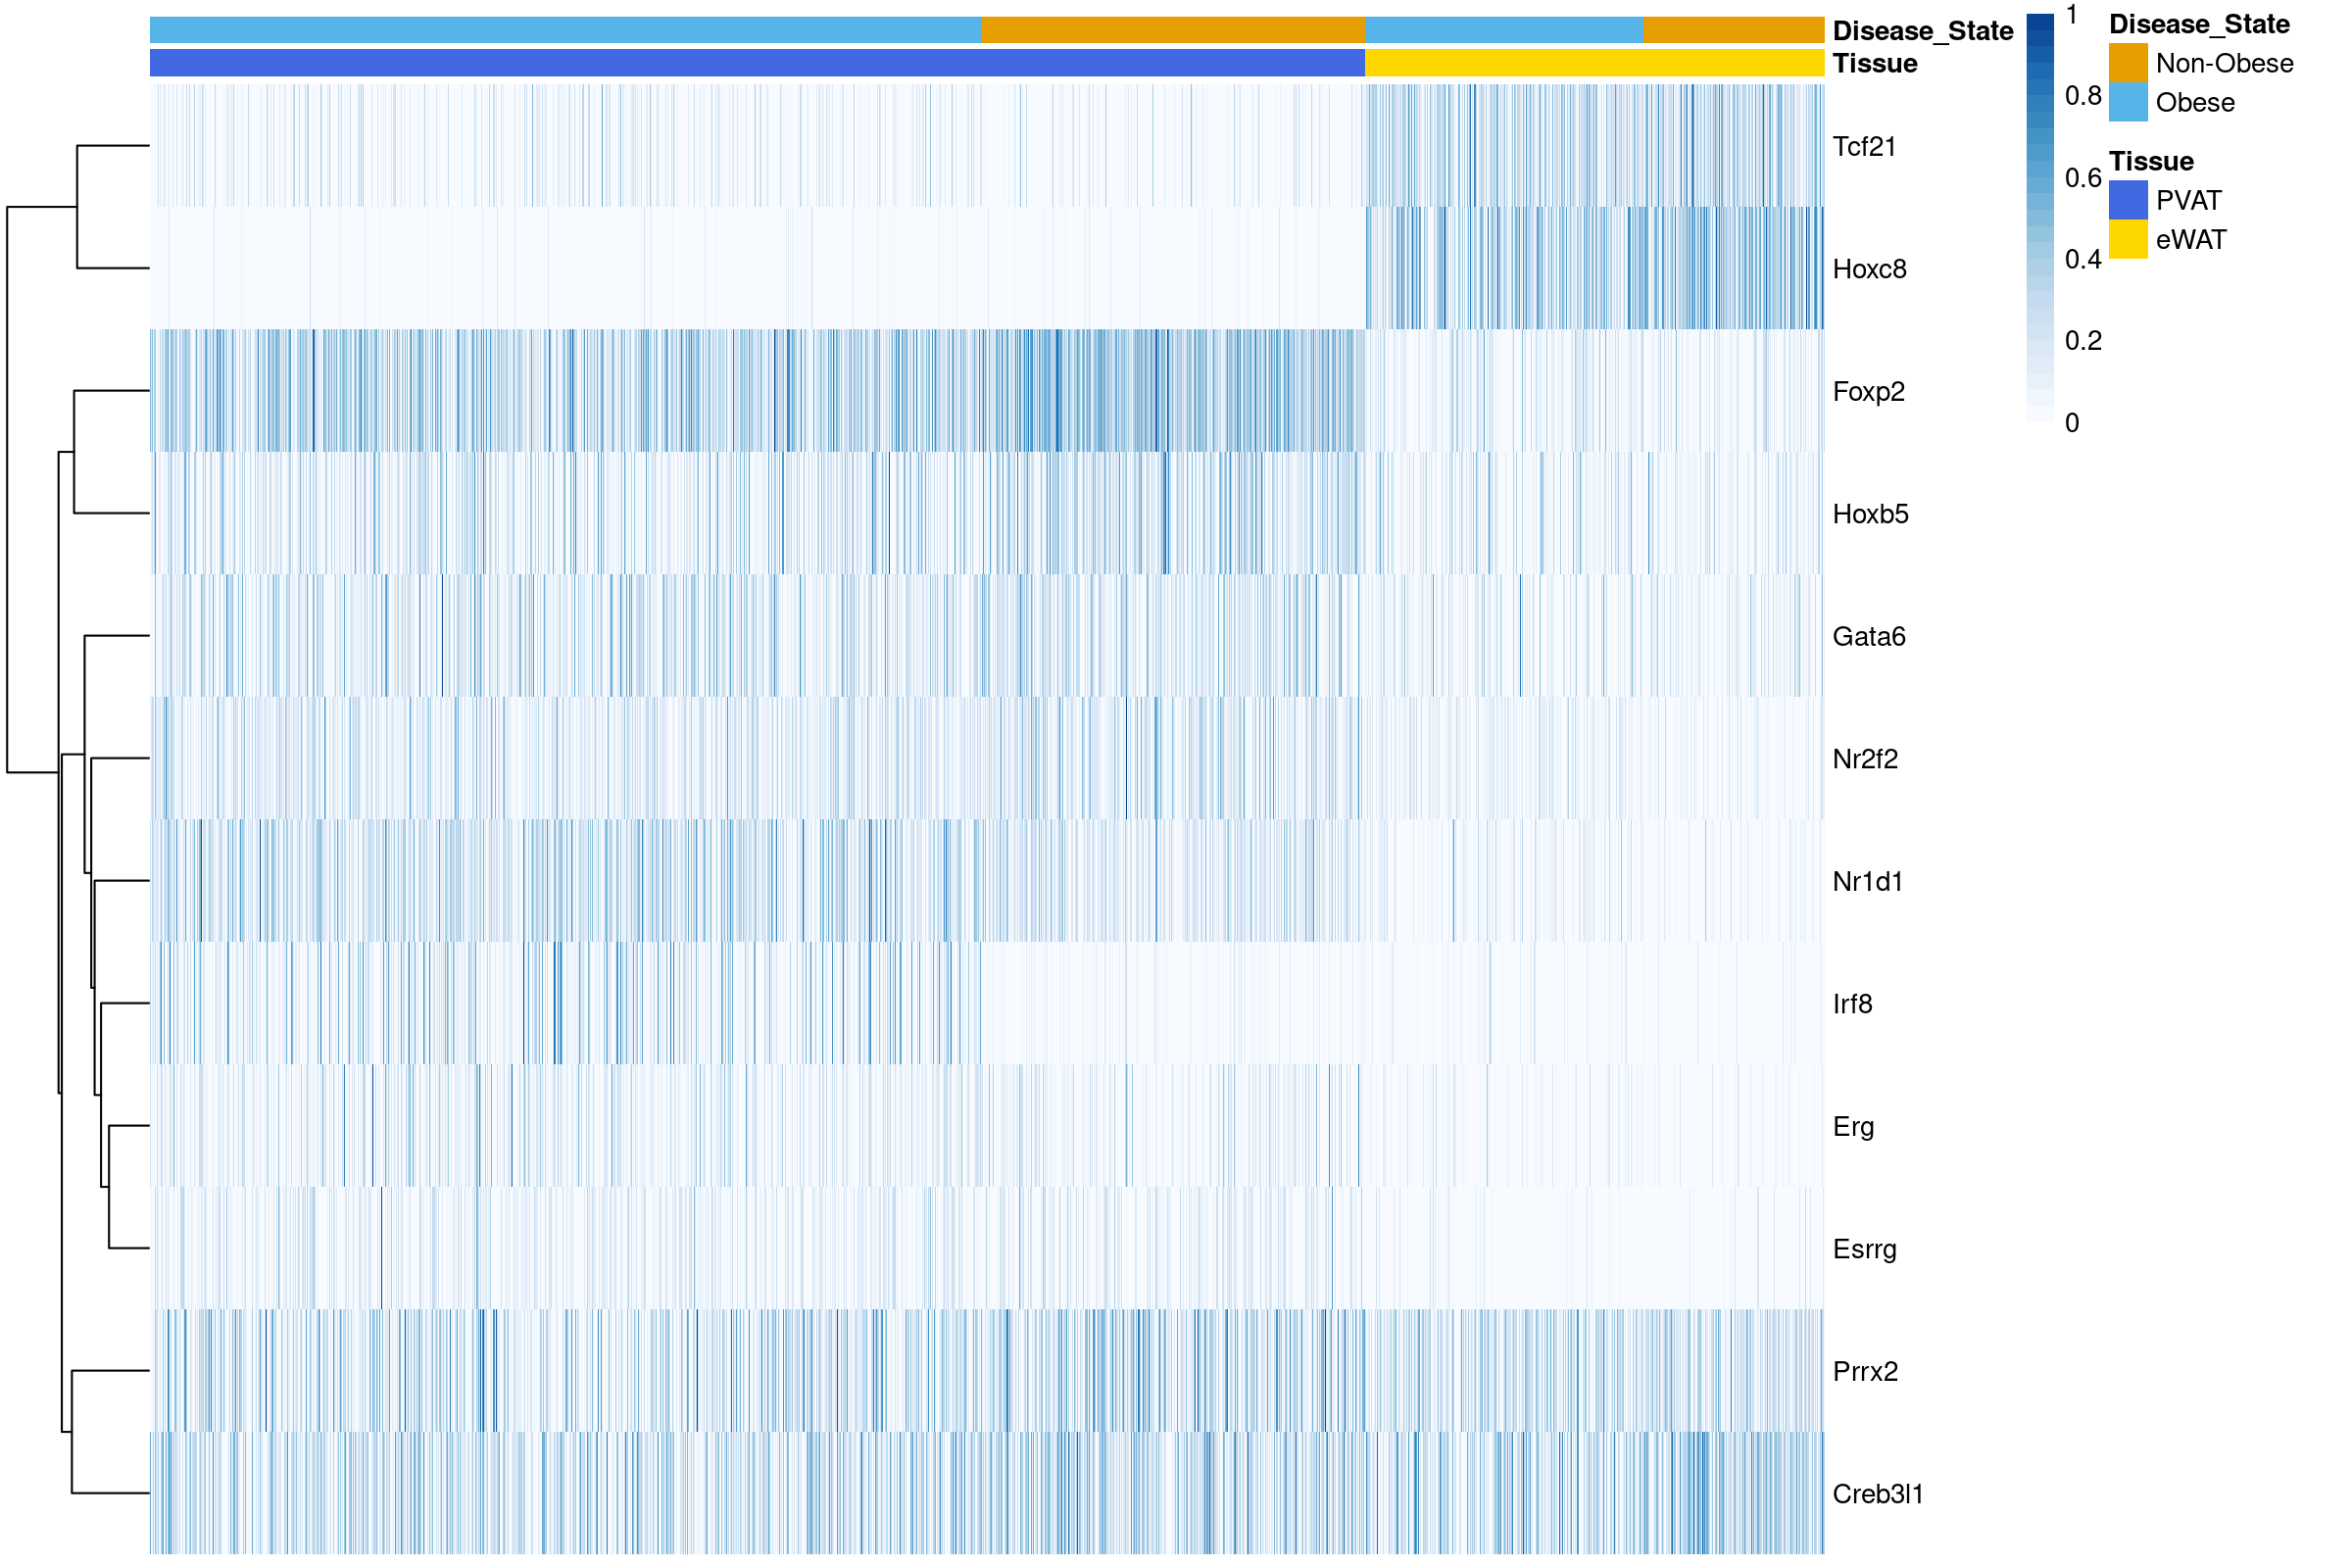

In [52]:
mfap4_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Mfap4+ Fibroblasts"),
    genes = c("Tcf21", "Hoxc8", "Nr1d1", "Prrx2", "Foxp2", "Creb3l1", "Hoxb5", "Irf8", "Nr2f2", "Gata6", "Erg", "Esrrg"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "SCENIC_AUC_Z",
    slot = "data",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

In [53]:
ggsave(
    plot = mfap4_heatmap,
    filename = "mfap4_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

#### Gene Expression Heatmap

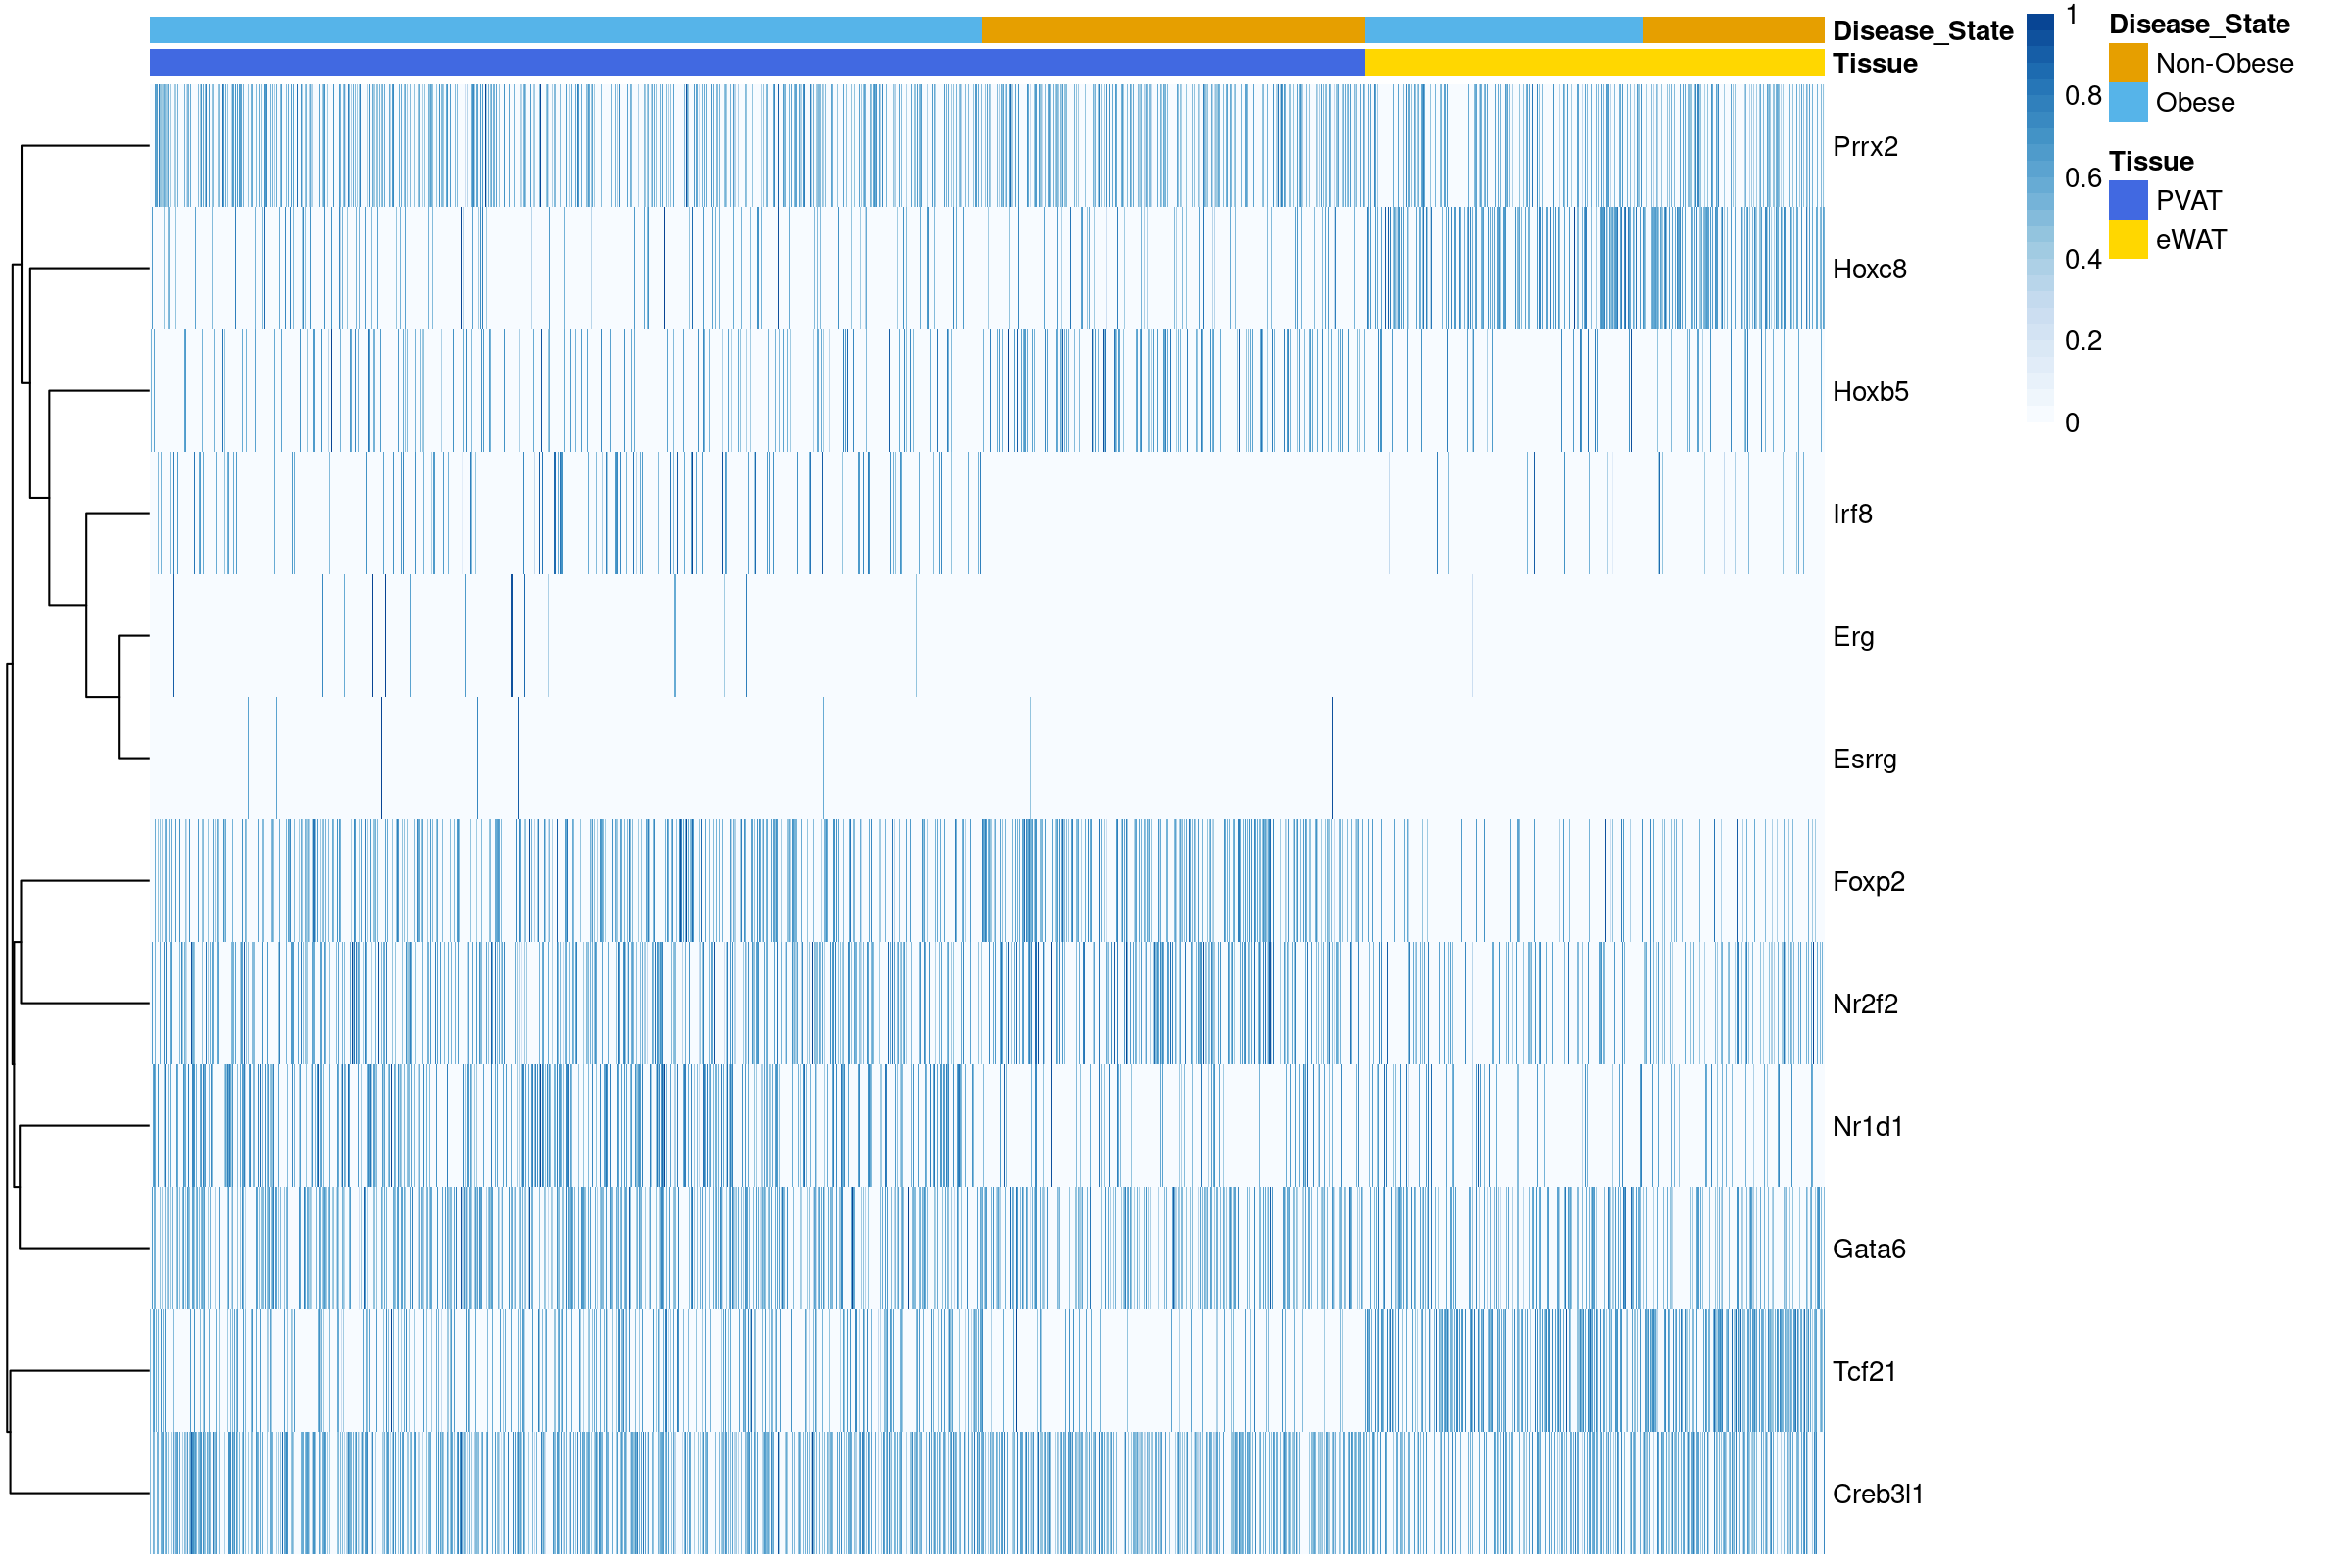

In [54]:
mfap4_rna_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Mfap4+ Fibroblasts"),
    genes = c("Tcf21", "Hoxc8", "Nr1d1", "Prrx2", "Foxp2", "Creb3l1", "Hoxb5", "Irf8", "Nr2f2", "Gata6", "Erg", "Esrrg"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "RNA",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

* **Hoxc8** and **Tcf21** expression is more in the eWAT. It is in concordance with the SCENIC results.
* **Foxp2** expression is higher in the PVAT as the SCENIC results suggest.
* **Irf8** expression is higher in the obese PVAT. This is in line with the SCENIC results.

In [55]:
ggsave(
    plot = mfap4_rna_heatmap,
    filename = "mfap4_rna_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

### Mgp+ Aebp1+ Activated fibroblasts

#### Make a Heatmap Using the Top Genes

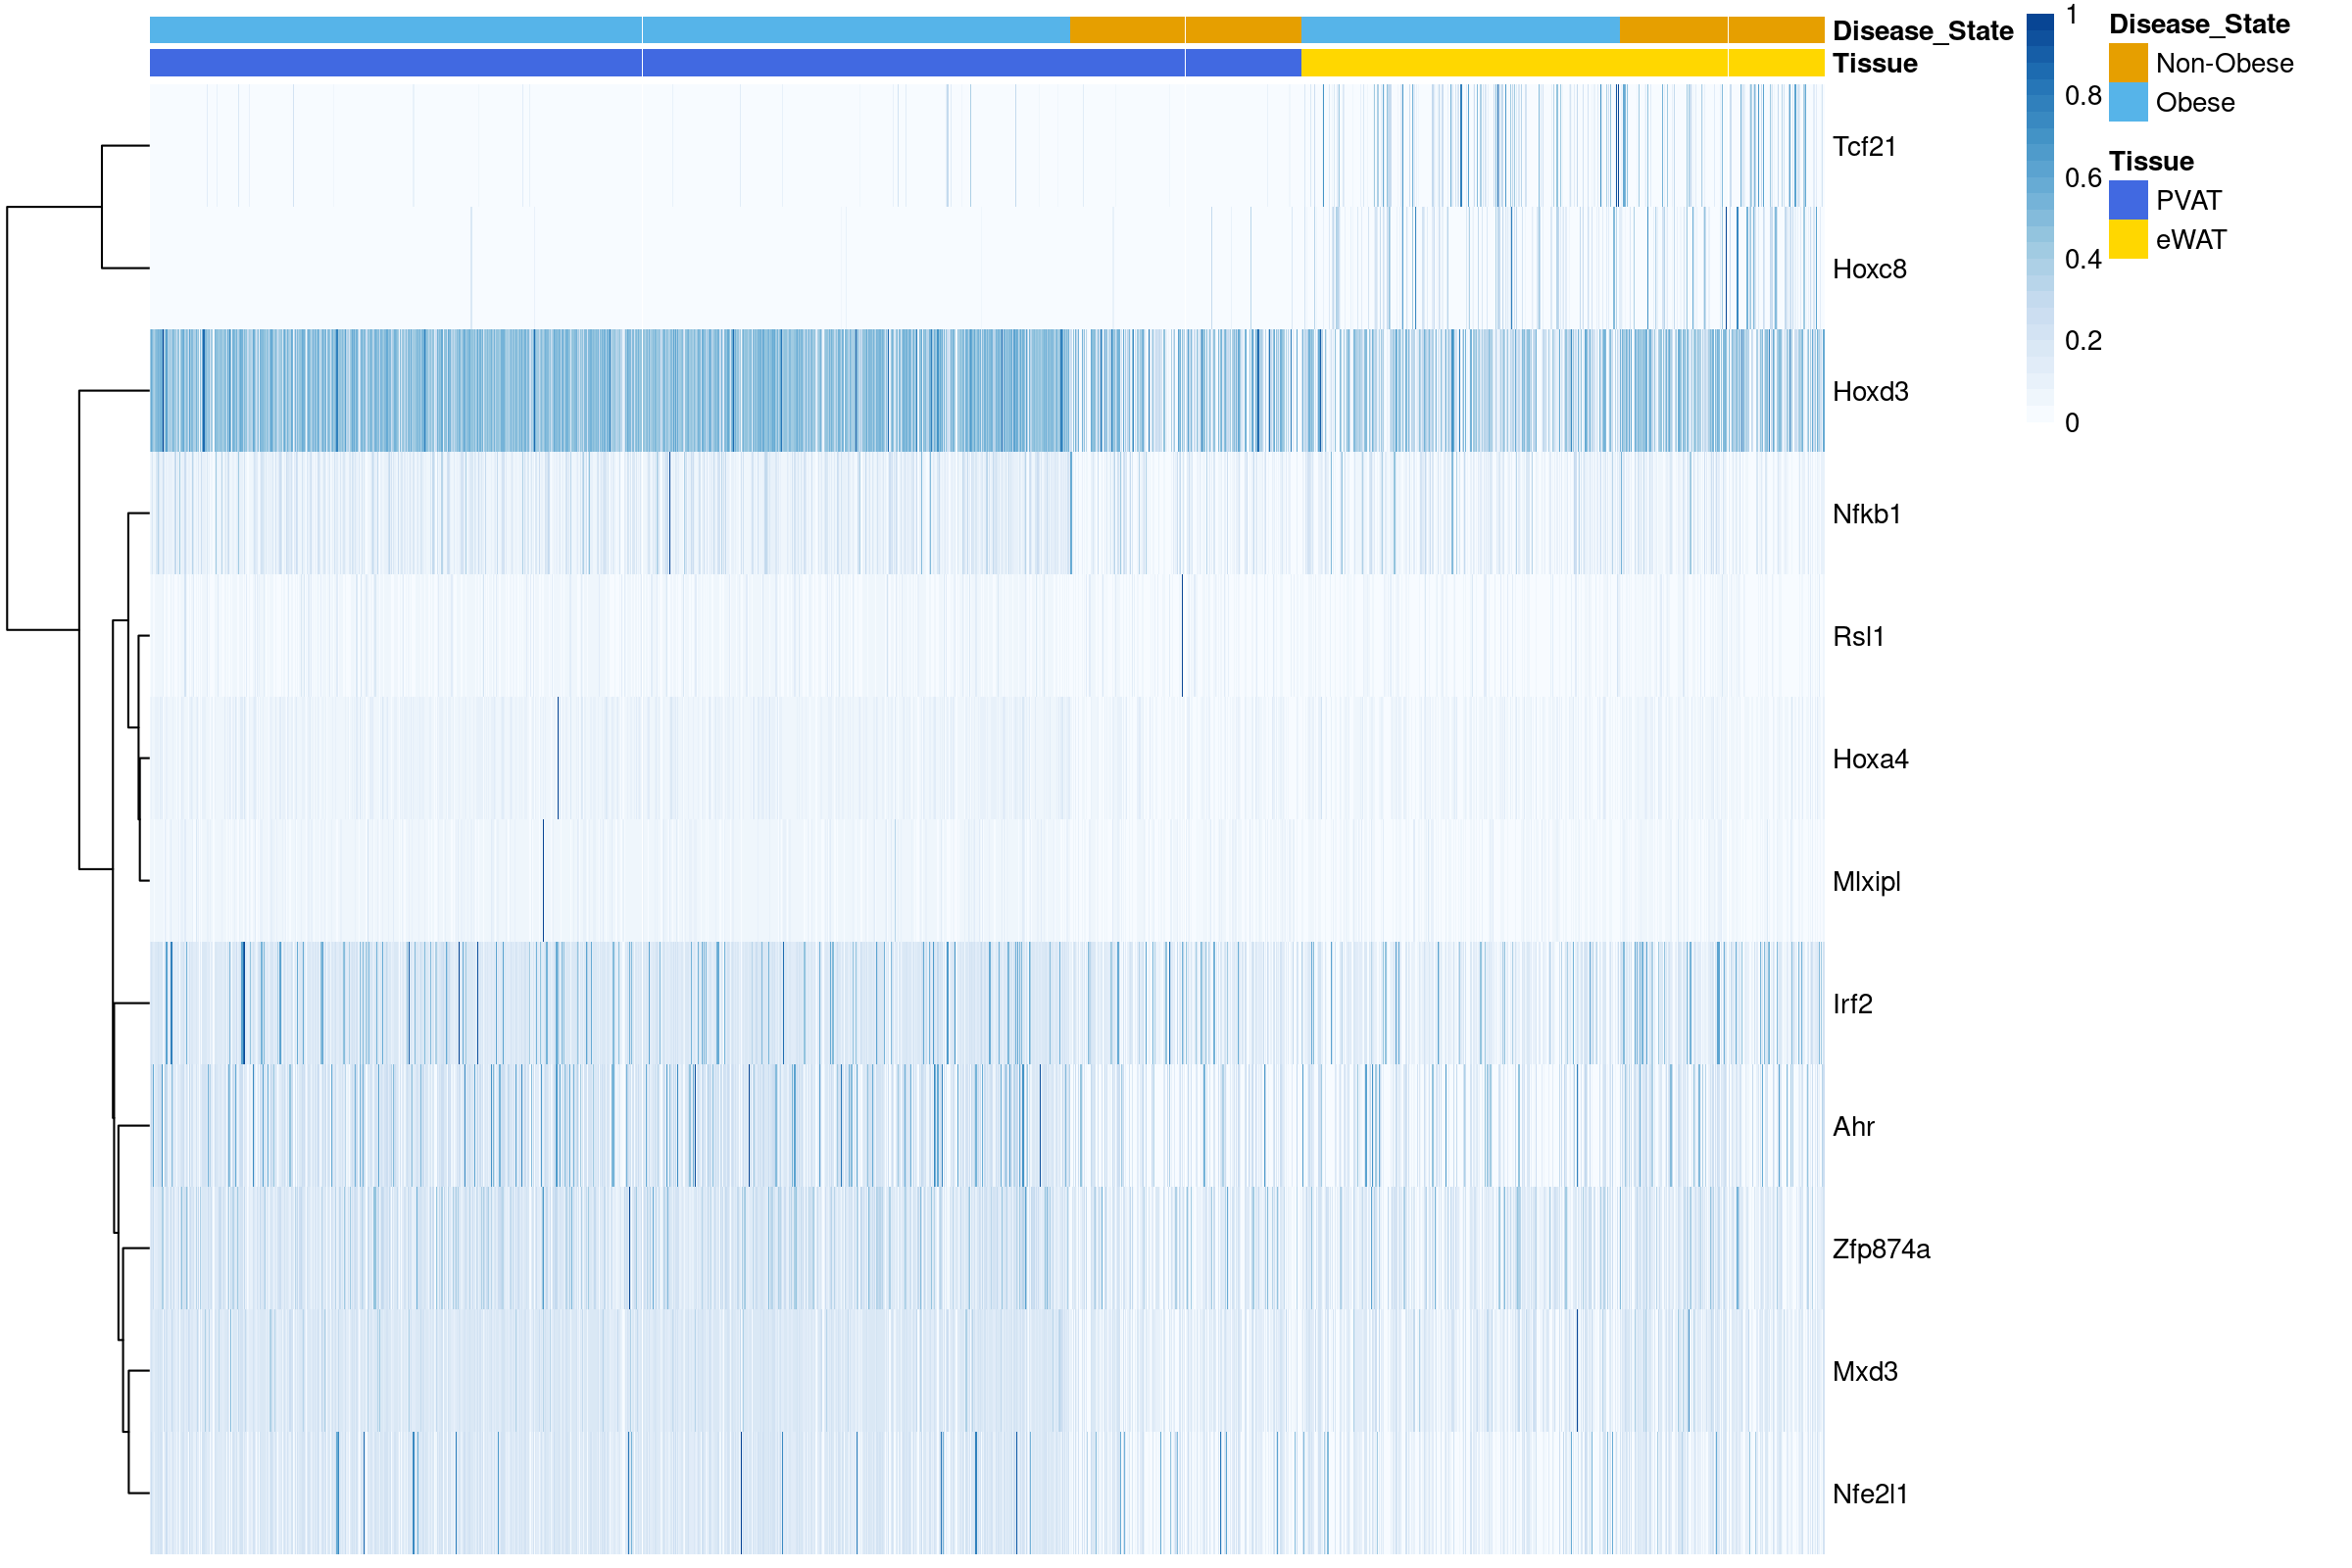

In [56]:
mgp_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Mgp+ Aebp1+ Activated fibroblasts"),
    genes = c("Mxd3", "Hoxd3", "Nfe2l1", "Irf2", "Nfkb1", "Hoxa4", "Rsl1", "Mlxipl", "Zfp874a", "Ahr", "Tcf21", "Hoxc8"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "SCENIC_AUC_Z",
    slot = "data",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

* **Hoxd3** seems like the top regulon for this fibroblast subcluster.
* **Hoxd3** and **Irf2** seem to have higher activity in non-obese tissues???
* Again, we see that **Hoxc8** and **Tcf21** are more active in eWAT.

In [57]:
ggsave(
    plot = mgp_heatmap,
    filename = "mgp_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

#### Gene Expression Heatmap

Warning message in .get_heatmap_data(object, genes, metas, assay, slot, cells.use):
“Gene(s) or metadata removed due to absence of non-zero values within the 'cells.use' subset”


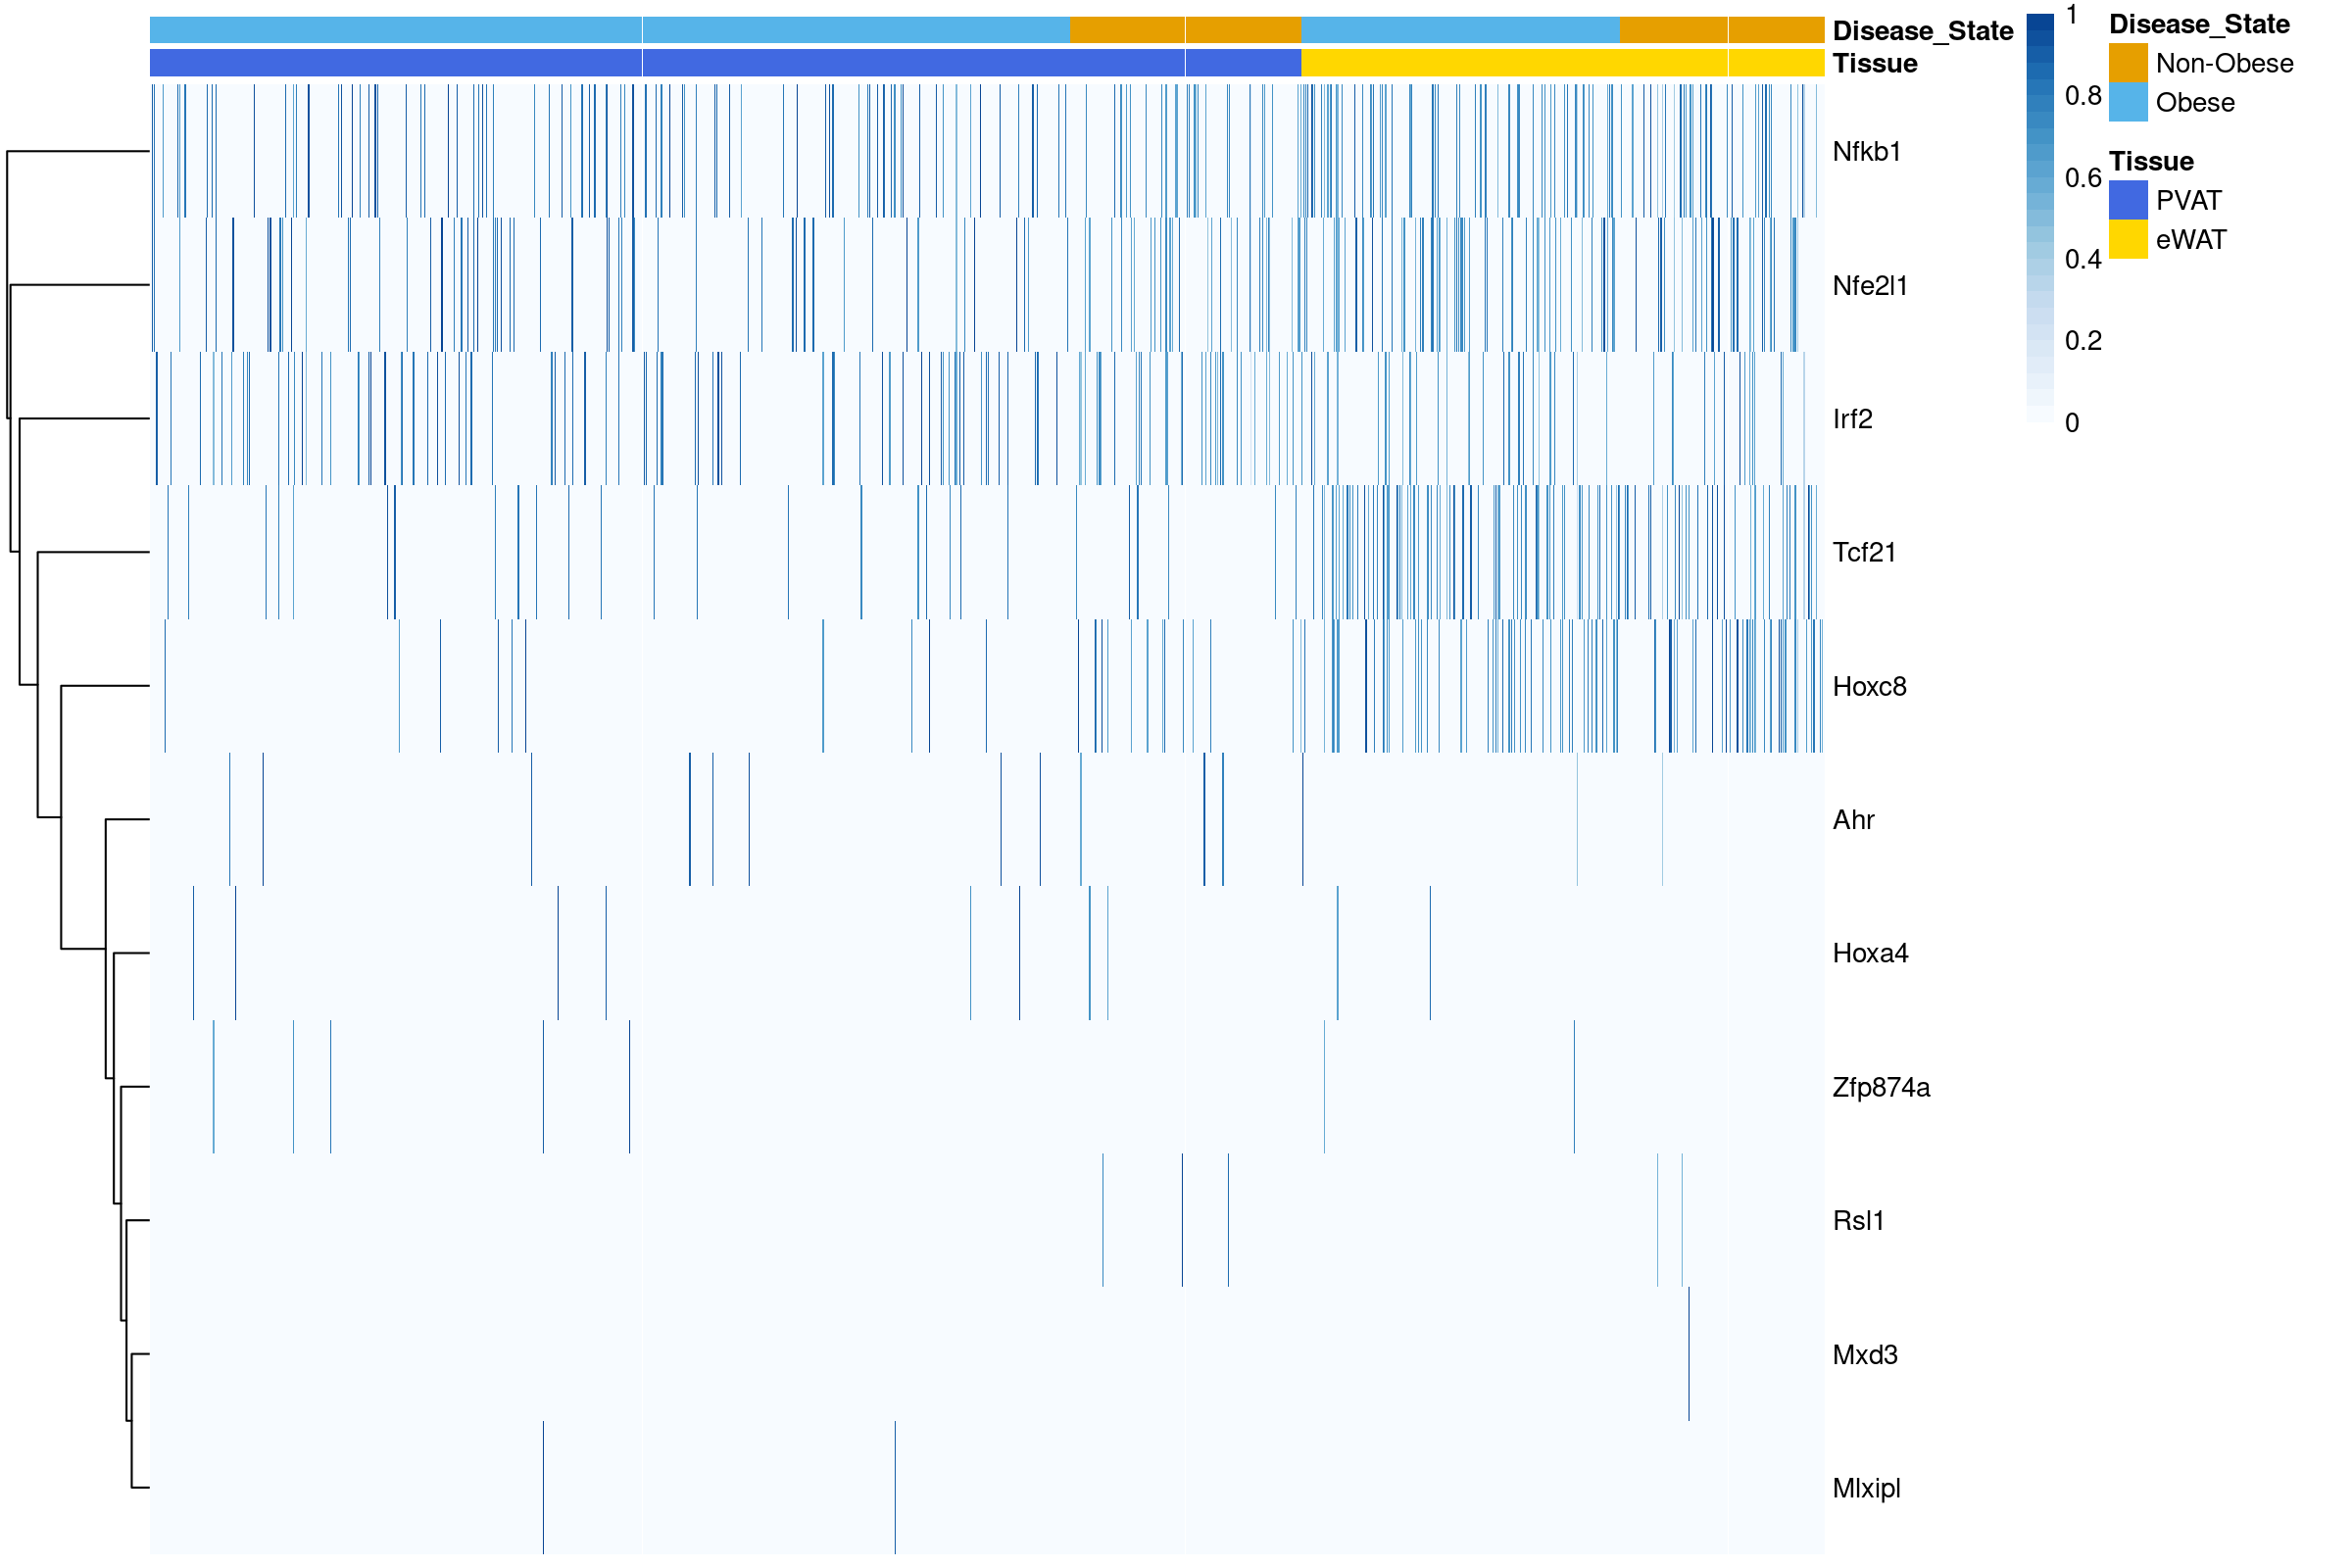

In [58]:
mgp_rna_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Mgp+ Aebp1+ Activated fibroblasts"),
    genes = c("Mxd3", "Hoxd3", "Nfe2l1", "Irf2", "Nfkb1", "Hoxa4", "Rsl1", "Mlxipl", "Zfp874a", "Ahr", "Tcf21", "Hoxc8"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "RNA",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

* No **Hoxd3** expression.

In [67]:
ggsave(
    plot = mgp_rna_heatmap,
    filename = "mgp_rna_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

#### Show the Related Genes on a Dot Plot

In [61]:
mgp_dotplot <- dittoDotPlot(
    object = subset(data, Cell_Type == "Mgp+ Aebp1+ Activated fibroblasts"),
    vars = c("Mxd3", "Hoxd3", "Nfe2l1", "Irf2", "Nfkb1", "Hoxa4", "Rsl1", "Mlxipl", "Zfp874a", "Ahr", "Tcf21", "Hoxc8"),
    group.by = "Tissue",
    split.by = "Disease_State",
    min.color = "blue",
    max.color = "gold",
    legend.color.title = "AUC",
    legend.size.title = "Percentage",
    theme = theme_light(),
    assay = "SCENIC_AUC",
    summary.fxn.size = function(x) {
        mean(x > 0.1)
        }
)

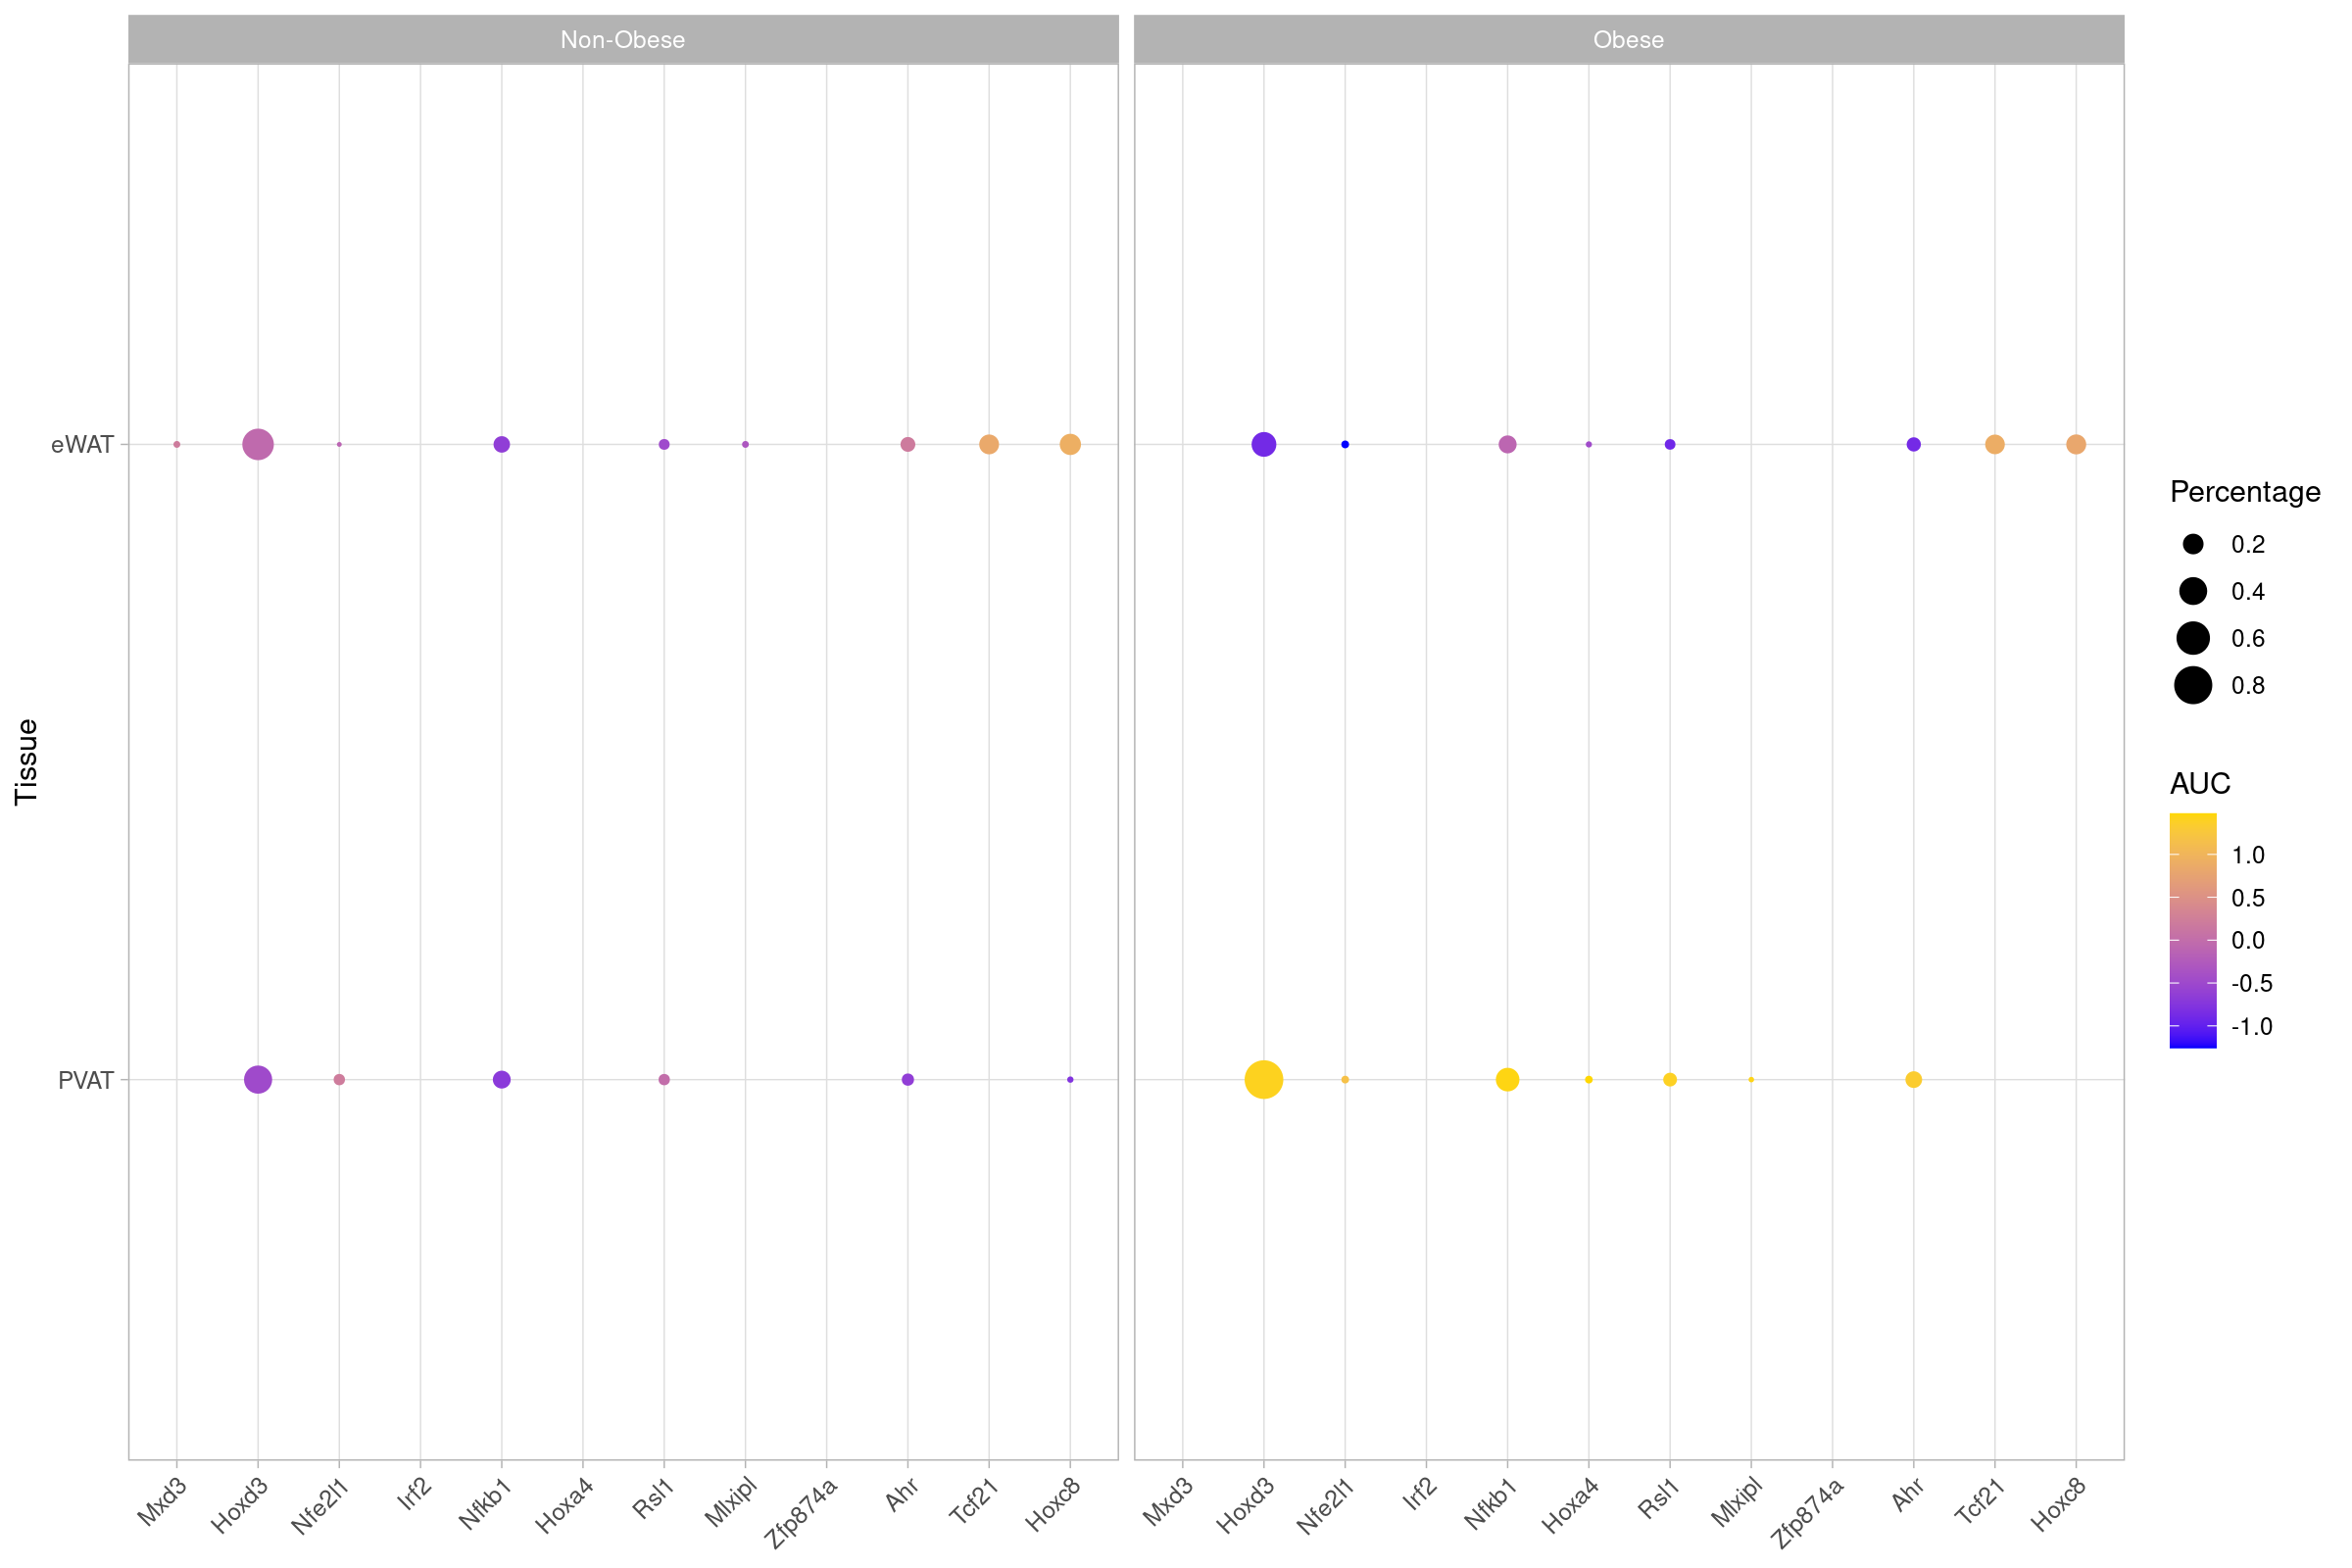

In [70]:
mgp_dotplot

* Dot plot also shows that **Hoxd3** is the top regulon for this fibroblast subcluster.
* **Hoxd3** is more active in obese PVAT (Could be the result of higher cell number???). It is the same for **Nfkb1**.

In [62]:
ggsave(
    plot = mgp_dotplot,
    filename = "mgp_dotplot.png",
    width = 12,
    height = 8,
    dpi = 500
)

### Il1b+ Fibroblasts

#### Make a Heatmap Using the Top Genes

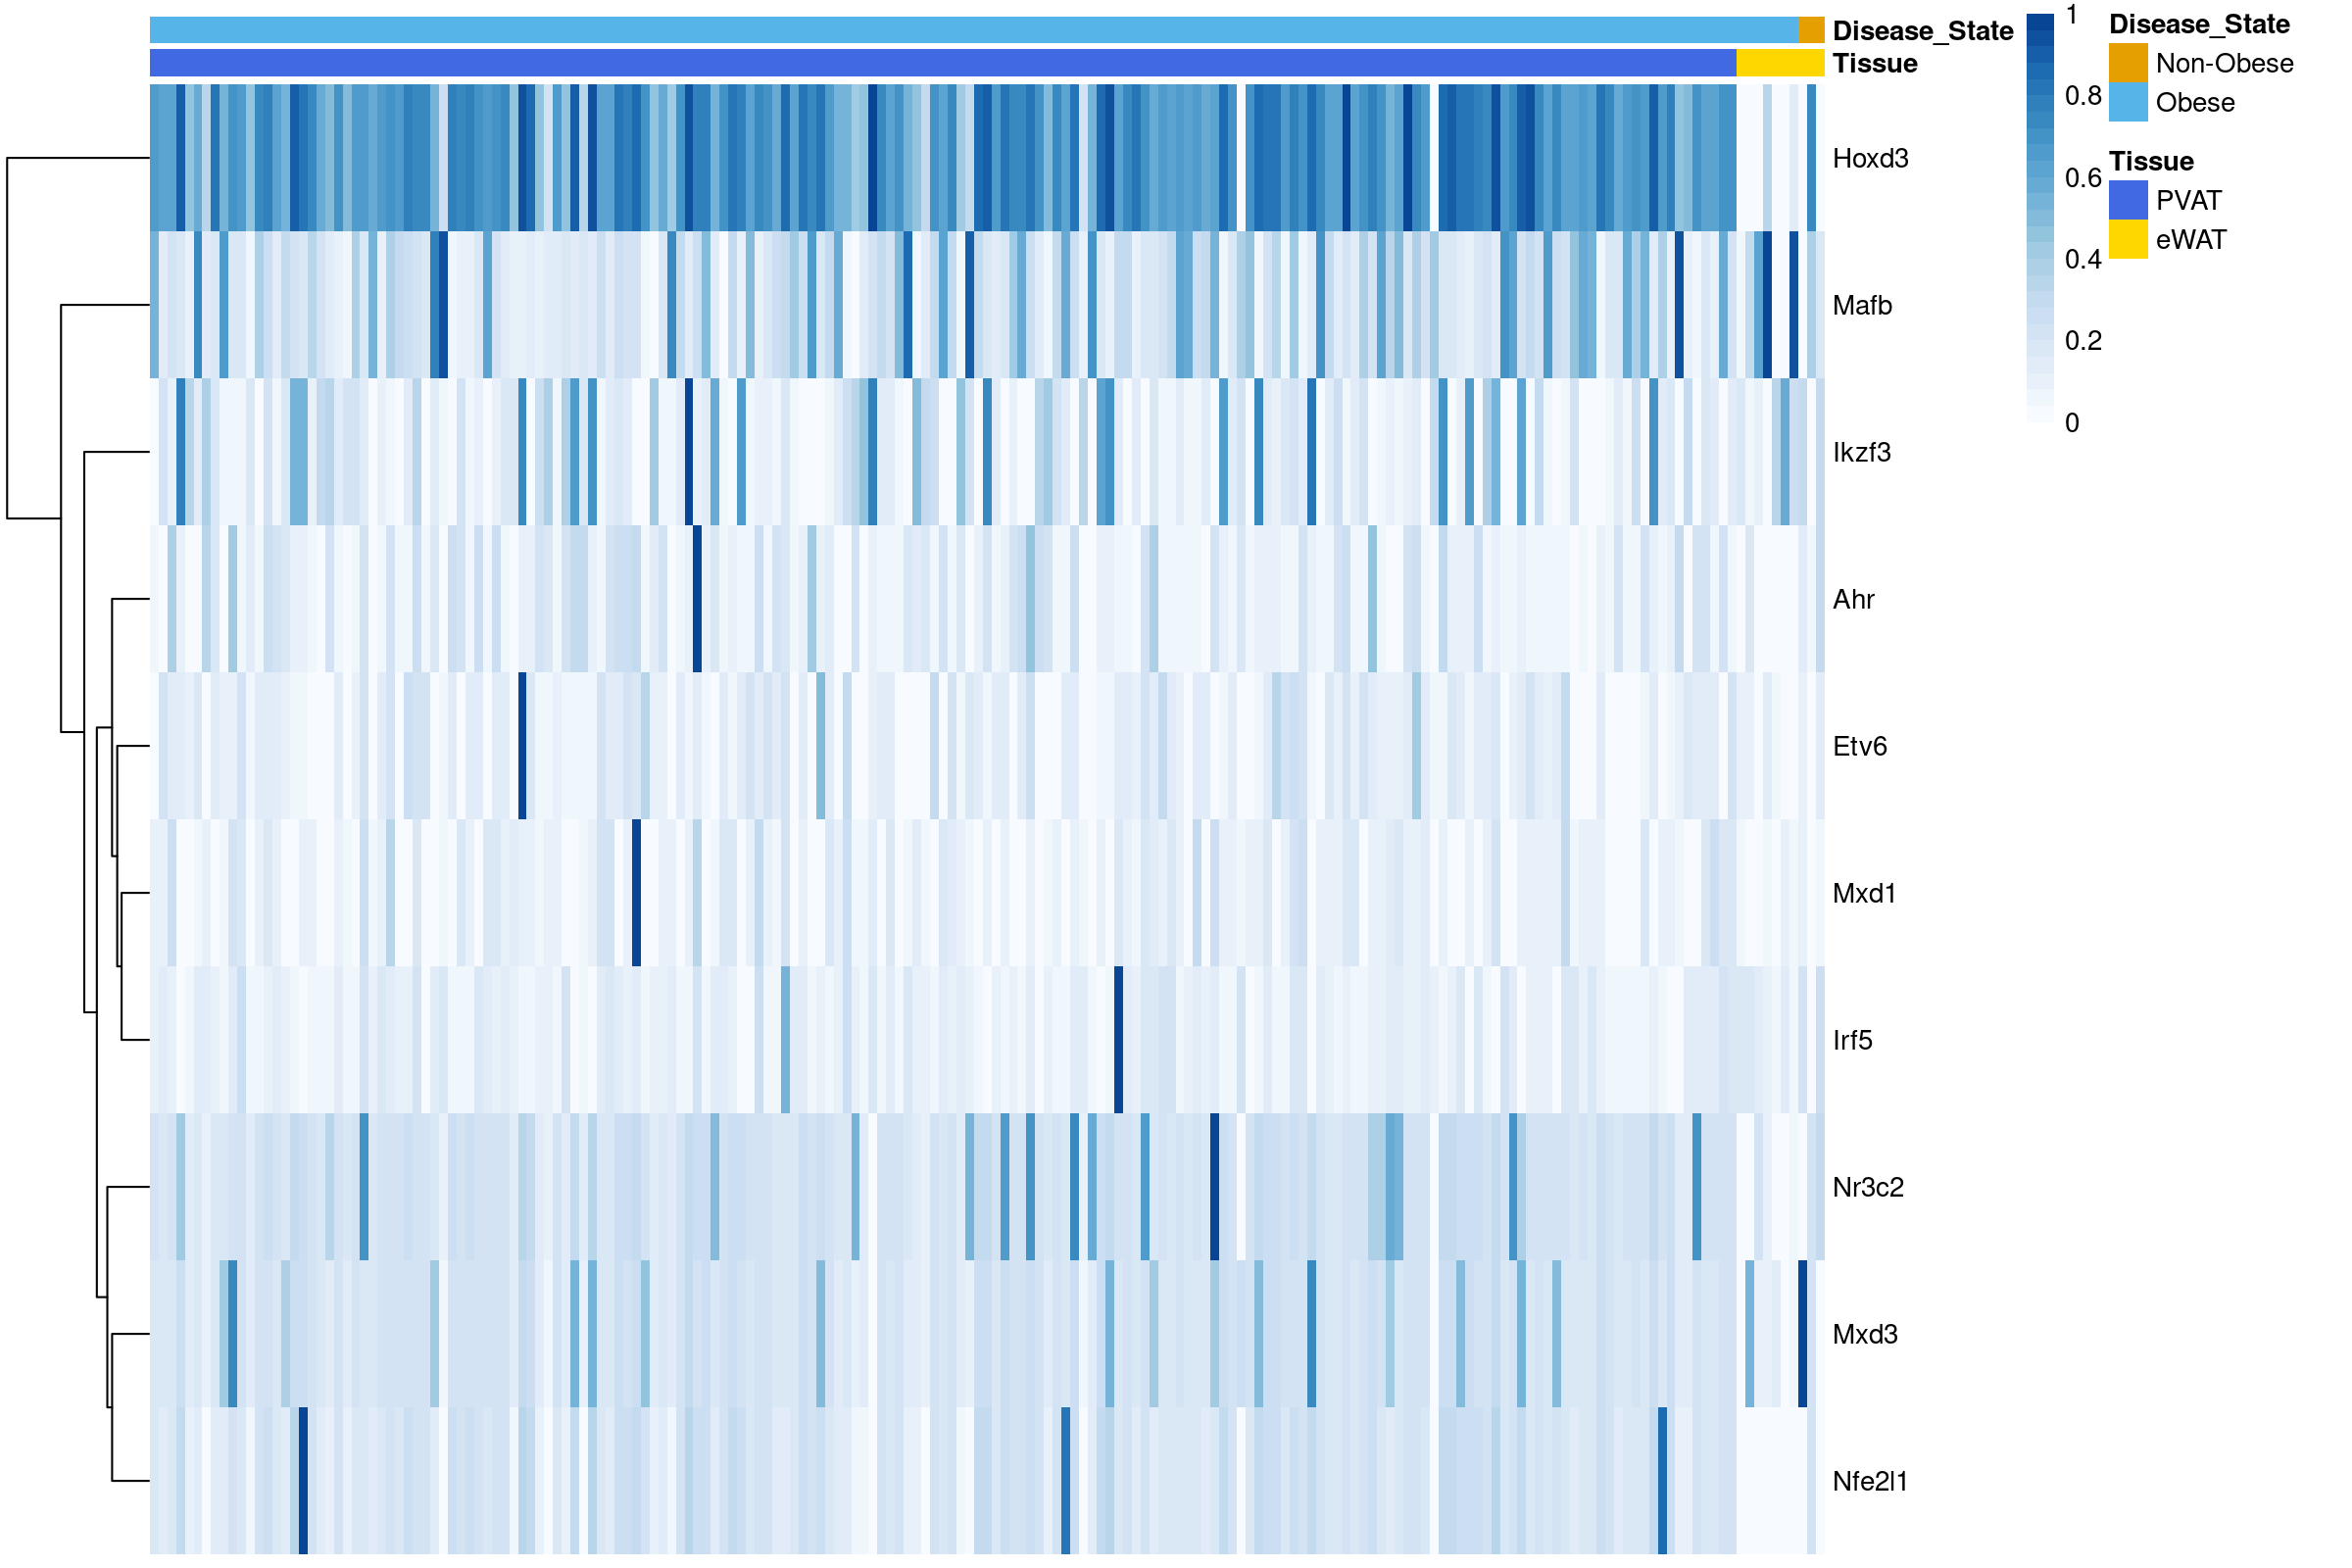

In [63]:
# heatmap for AUC scores
Il1b_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Il1b+ Fibroblasts"),
    genes = c("Mxd1", "Ahr", "Ikzf3", "Mxd3", "Mafb", "Etv6", "Nfe2l1", "Hoxd3", "Irf5", "Nr3c2"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "SCENIC_AUC_Z",
    slot = "data",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

In [64]:
ggsave(
    plot = Il1b_heatmap,
    filename = "Il1b_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)

Warning message in .get_heatmap_data(object, genes, metas, assay, slot, cells.use):
“Gene(s) or metadata removed due to absence of non-zero values within the 'cells.use' subset”


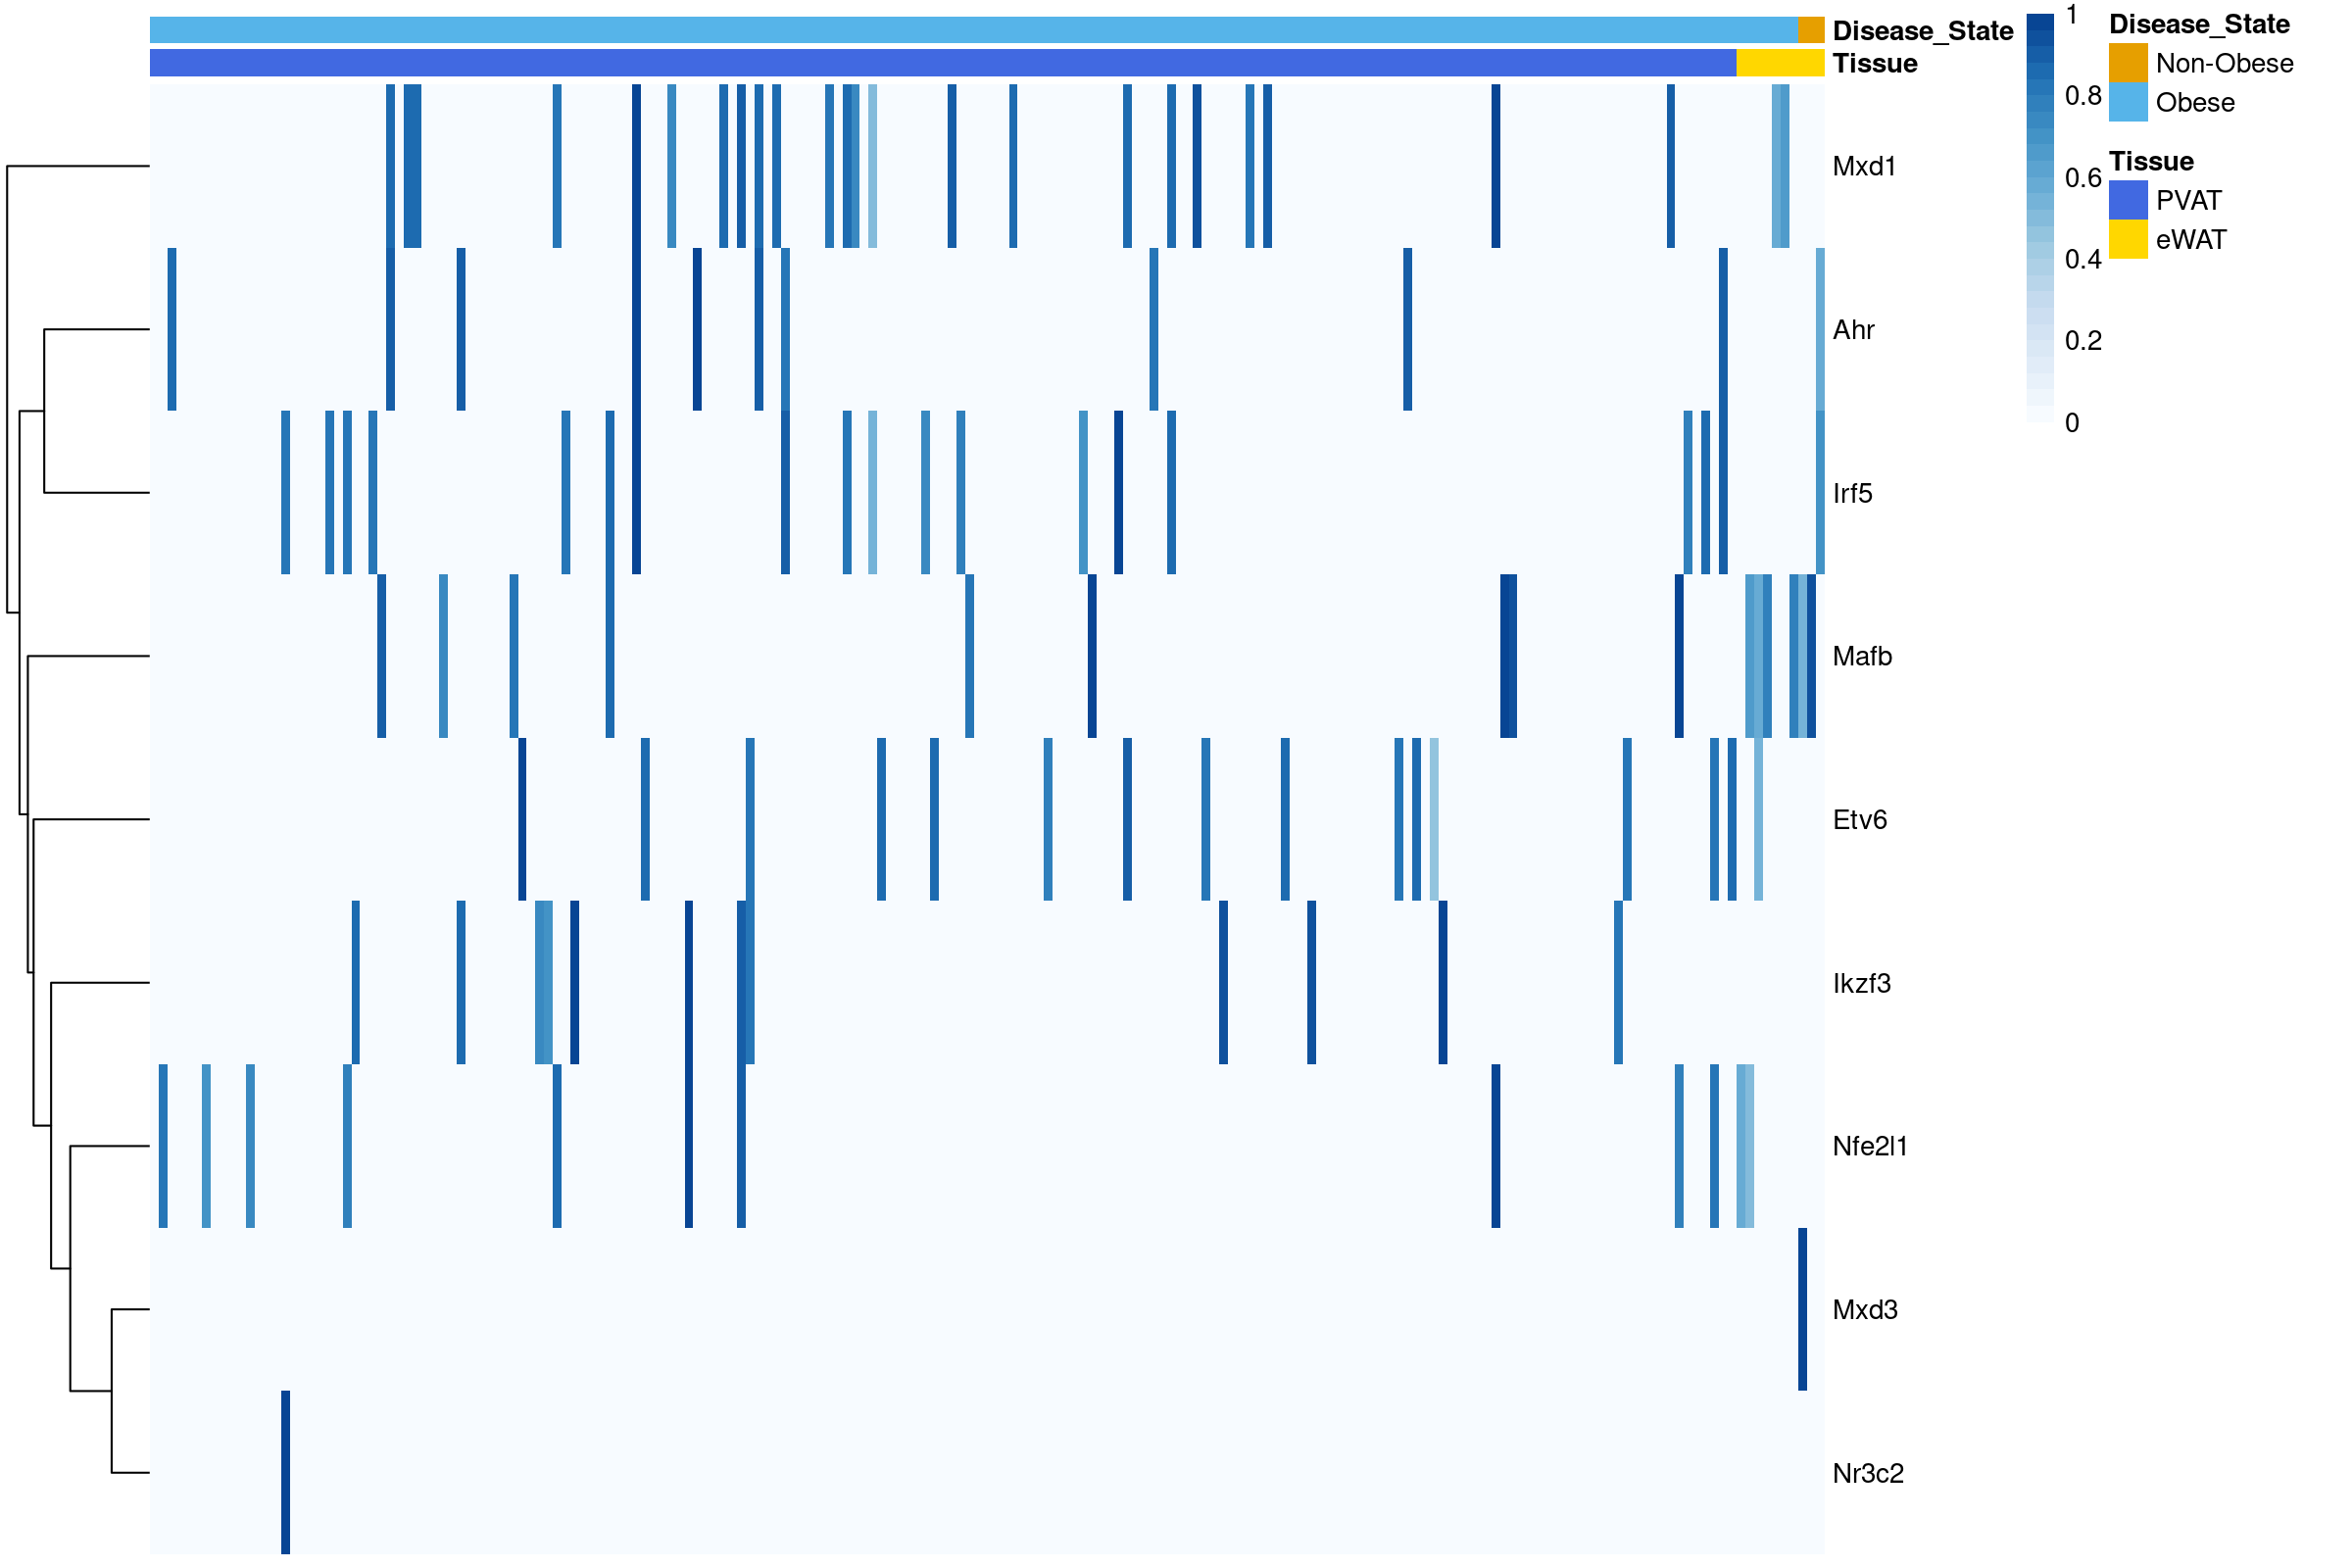

In [65]:
Ilb1_rna_heatmap <- dittoHeatmap(
    object = subset(data, Cell_Type == "Il1b+ Fibroblasts"),
    genes = c("Mxd1", "Ahr", "Ikzf3", "Mxd3", "Mafb", "Etv6", "Nfe2l1", "Hoxd3", "Irf5", "Nr3c2"),
    annot.by = c("Tissue", "Disease_State"),
    assay = "RNA",
    heatmap.colors.max.scaled = colorRampPalette(brewer.pal(8, "Blues"))(25),
    scaled.to.max = TRUE,
    annotation_colors = list(
        "Tissue" = c(
            PVAT = 'royalblue',
            eWAT = 'gold')
    )
)

* Almost all the fibroblasts in this subcluster is found in obese PVAT.
* **Hoxd3** is the top regulon with the hihgest AUC scores. It has less activity in eWAT.
* **Hoxd3** is not expressed in these cells, but it is a top regulator ???

In [66]:
ggsave(
    plot = Ilb1_rna_heatmap,
    filename = "Ilb1_rna_heatmap.png",
    width = 12,
    height = 8,
    dpi = 500
)